## CELL 0 — Environment Verification
Checks that CUDA, Mitsuba, and PyTorch are available; sets the Mitsuba rendering backend.

In [5]:
# CELL 0 – Environment verification (optional but recommended)
import os, sys, warnings
warnings.filterwarnings('ignore')
import torch, numpy as np, mitsuba as mi, drjit as dr

# Force CUDA backend if available
try:
    mi.set_variant('cuda_ad_mono_polarized')
except:
    mi.set_variant('llvm_ad_mono_polarized')

print(f"Mitsuba backend: {mi.variant()}")
print(f"CUDA available: {torch.cuda.is_available()}")

Mitsuba backend: llvm_ad_mono_polarized
CUDA available: False


## CELL 1 (Part A) — Scene Configuration
Defines all global constants: city name, UTM/BNG EPSG codes, frequency, bounding box, TX/RX heights.

In [2]:
# ── Scene configuration ───────────────────────────────────────────────────────
import os, math
import numpy as np

CITY_NAME      = 'Nottingham'
UTM_EPSG       = 32630
BNG_EPSG       = 27700
FREQUENCY_HZ   = 3602.5e6

# Scene bbox (11 km)
WEST, EAST   = -1.409134, -1.245094
SOUTH, NORTH =  52.910276, 53.009090

# TX
TX_AGL_M     = 17.0
TX_LAT, TX_LON = 52.9863, -1.2559

# RX
RX_AGL_M     = 1.5

# Paths
BASE_DIR   = os.path.expanduser('~/Documents/FYP2026/nottingham_11km2')
SCENE_DIR  = os.path.join(BASE_DIR, 'scene')
MESHES_DIR = os.path.join(SCENE_DIR, 'meshes')
SCENE_XML  = os.path.join(SCENE_DIR, 'scene.xml')
OUT_DIR    = os.path.join(BASE_DIR, 'results_sionna2')
os.makedirs(MESHES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Scene flags
FLAT_TERRAIN        = True
FORCE_REBUILD_SCENE = False   # True = rebuild PLY + XML from OSM
CITY_MIN_HEIGHT_M   = 2.0
CITY_MAX_HEIGHT_M   = 40.0

# Coordinate helpers
from pyproj import Transformer
gps_to_utm  = Transformer.from_crs('EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True)
utm_to_gps  = Transformer.from_crs(f'EPSG:{UTM_EPSG}', 'EPSG:4326', always_xy=True)
_c          = gps_to_utm.transform((WEST+EAST)/2, (SOUTH+NORTH)/2)
utm_center_x, utm_center_y = _c

def gps_to_local(lon, lat):
    ux, uy = gps_to_utm.transform(lon, lat)
    return float(ux - utm_center_x), float(uy - utm_center_y)

print(f'Scene  : {CITY_NAME}  {(EAST-WEST)*111:.1f} × {(NORTH-SOUTH)*111:.1f} km')
print(f'Center : ({(WEST+EAST)/2:.5f}, {(SOUTH+NORTH)/2:.5f})')
print(f'Output : {SCENE_XML}')

Scene  : Nottingham  18.2 × 11.0 km
Center : (-1.32711, 52.95968)
Output : /home/georgeskai/Documents/FYP2026/nottingham_11km2/scene/scene.xml


## CELL 1 (Part B) — OSM Building Download
Downloads building footprints and extra OSM features for the scene bounding box using osmnx.

In [3]:
# ── Download buildings + extra features from OpenStreetMap ───────────────────
import osmnx as ox, geopandas as gpd, json, time

OSM_GEOJSON = os.path.join(OUT_DIR, 'osm_buildings.geojson')
LEVEL_H     = 3.0   # metres per floor

_TYPE_FLOORS = {
    'house':2,'detached':2,'semidetached_house':2,'terrace':2,'bungalow':1,
    'residential':3,'apartments':5,'block_of_flats':5,
    'commercial':3,'retail':2,'office':6,'hotel':7,
    'industrial':2,'warehouse':1,'factory':2,
    'church':6,'cathedral':8,'school':3,'university':4,'hospital':5,
    'yes':3,
}

def _parse_height(row):
    for col in ('height','building:height'):
        if col in row and pd.notna(row.get(col)):
            try: return float(str(row[col]).split()[0])
            except: pass
    if 'building:levels' in row and pd.notna(row.get('building:levels')):
        try: return float(row['building:levels']) * LEVEL_H
        except: pass
    btype = str(row.get('building','')).strip().lower()
    return _TYPE_FLOORS.get(btype, 3) * LEVEL_H

import pandas as pd

if os.path.exists(OSM_GEOJSON) and not FORCE_REBUILD_SCENE:
    gdf = gpd.read_file(OSM_GEOJSON)
    print(f'Loaded {len(gdf)} buildings from cache')
else:
    print('Downloading buildings from OSM ...')
    t0 = time.time()
    ox.settings.timeout = 180
    gdf = ox.features_from_bbox(
        bbox=(WEST, SOUTH, EAST, NORTH), tags={'building': True})
    gdf = gdf[gdf.geometry.geom_type.isin(['Polygon','MultiPolygon'])].copy()
    gdf = gdf.to_crs('EPSG:4326')
    gdf_utm_ = gdf.to_crs(f'EPSG:{UTM_EPSG}')
    gdf = gdf[gdf_utm_.geometry.area >= 20].reset_index(drop=True)
    print(f'  {len(gdf)} buildings in {time.time()-t0:.1f}s')
    _keep = ['geometry'] + [c for c in
        ['height','building:height','building:levels','building','building:material']
        if c in gdf.columns]
    gdf[_keep].to_file(OSM_GEOJSON, driver='GeoJSON')

heights = np.array([_parse_height(r) for _, r in gdf.iterrows()])
heights = np.clip(heights, CITY_MIN_HEIGHT_M, CITY_MAX_HEIGHT_M)
gdf['height'] = heights
print(f'Heights: min={heights.min():.1f}  mean={heights.mean():.1f}  max={heights.max():.1f} m')

# Extra features
_extra_tags = {
    'water':    {'natural':['water','bay'],'waterway':['riverbank'],'landuse':['reservoir','basin']},
    'vegetation':{'landuse':['grass','meadow','forest','orchard'],'natural':['wood','scrub','heath']},
    'road':     {'highway':True},
    'barrier':  {'barrier':['wall','fence','hedge','retaining_wall']},
    'railway':  {'railway':['rail','tram','subway']},
}
_osm_extra = {}
for feat, tags in _extra_tags.items():
    try:
        _gdf = ox.features_from_bbox(bbox=(WEST,SOUTH,EAST,NORTH), tags=tags)
        _gdf = _gdf[_gdf.geometry.geom_type.isin(
            ['Polygon','MultiPolygon','LineString','MultiLineString'])].copy()
        _osm_extra[feat] = _gdf.to_crs('EPSG:4326')
        print(f'  {feat}: {len(_gdf):,} features')
    except Exception as e:
        print(f'  {feat}: skipped ({e})')

  52611 buildings in 27.1s
Heights: min=3.0  mean=6.8  max=21.0 m
  water: 272 features
  vegetation: 2,215 features
  road: 14,923 features
  barrier: 4,473 features
  railway: 226 features


## CELL 1 (Part C) — OSM to PLY / scene.xml Export
Converts OSM GeoJSON building polygons into PLY meshes and writes a Mitsuba-compatible scene.xml.

In [4]:
# ── OSM → PLY meshes + scene.xml (Mitsuba 3, Sionna-compatible) ──────────────
import struct, re, xml.etree.ElementTree as ET, xml.dom.minidom as minidom

if not FORCE_REBUILD_SCENE and os.path.exists(SCENE_XML):
    print(f'Scene exists: {SCENE_XML}  (set FORCE_REBUILD_SCENE=True to rebuild)')
else:
    print(f'Building scene from {len(gdf)} buildings ...')
    t0 = time.time()
    from pyproj import Transformer as _Tr
    _wgs_to_utm = Transformer.from_crs('EPSG:4326', f'EPSG:{UTM_EPSG}', always_xy=True)
    ox_utm, oy_utm = utm_center_x, utm_center_y

    # ── PLY writer ────────────────────────────────────────────────────────────
    def write_ply(path, verts, faces):
        verts = np.asarray(verts, dtype=np.float32)
        faces = np.asarray(faces, dtype=np.int32)
        with open(path, 'wb') as fp:
            hdr = (f'ply\nformat binary_little_endian 1.0\n'
                   f'element vertex {len(verts)}\n'
                   f'property float x\nproperty float y\nproperty float z\n'
                   f'element face {len(faces)}\n'
                   f'property list uchar int vertex_indices\nend_header\n')
            fp.write(hdr.encode())
            fp.write(verts.tobytes())
            for tri in faces:
                fp.write(struct.pack('<B3i', 3, *tri))

    def _ll_to_local(lon, lat):
        ux, uy = _wgs_to_utm.transform(lon, lat)
        return ux - ox_utm, uy - oy_utm

    def _tri_polygon(pts):
        """Fan triangulation for convex/simple polygons."""
        if len(pts) < 3: return []
        return [(0, i, i+1) for i in range(1, len(pts)-1)]

    # ── Material assignment ───────────────────────────────────────────────────
    def _bld_mat(row):
        mat  = str(row.get('building:material','')).lower()
        fmat = str(row.get('building:facade:material','')).lower()
        tag  = str(row.get('building','')).lower()
        off  = str(row.get('office','')).lower()
        shop = str(row.get('shop','')).lower()
        if 'glass' in mat or 'glass' in fmat: return 'itu_glass'
        if 'wood'  in mat or 'timber' in mat: return 'itu_wood'
        if 'brick' in mat or 'brick' in fmat: return 'itu_brick'
        if 'stone' in mat or 'stone' in fmat: return 'itu_brick'
        if off or tag in ('office','retail','commercial','supermarket','kiosk',
                          'greenhouse','glasshouse') or shop: return 'itu_glass'
        if tag in ('industrial','warehouse','factory','shed','barn',
                   'storage_tank','silo'):      return 'itu_concrete'
        if tag in ('school','university','hospital','civic','public'): return 'itu_concrete'
        return 'itu_brick'

    ITU_MATS      = ['itu_concrete','itu_brick','itu_glass','itu_wood']
    ITU_ROAD_MATS = ['itu_asphalt']
    ITU_ROOF_MATS = ['itu_metal','itu_concrete','itu_brick']
    mat_verts = {m:[] for m in ITU_MATS + ITU_ROAD_MATS + ITU_ROOF_MATS +
                 ['itu_vegetation','itu_water']}
    mat_faces = {m:[] for m in mat_verts}

    # ── Building extrusion ────────────────────────────────────────────────────
    gdf_utm = gdf.to_crs(f'EPSG:{UTM_EPSG}')
    for idx in range(len(gdf)):
        row_utm = gdf_utm.iloc[idx]
        row_wgs = gdf.iloc[idx]
        h       = float(row_wgs['height'])
        geom    = row_utm.geometry
        if geom is None or geom.is_empty: continue
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            ring = list(poly.exterior.coords)[:-1]
            if len(ring) < 3: continue
            pts  = [(x - ox_utm, y - oy_utm) for x, y in ring]
            z0, z1 = (0.0, h) if FLAT_TERRAIN else (0.0, h)   # base always 0 for flat
            mat  = _bld_mat(dict(row_wgs))
            vl, fl = mat_verts[mat], mat_faces[mat]
            base = len(vl)
            n    = len(pts)
            # walls
            for x, y in pts: vl.append((x, y, z0))
            for x, y in pts: vl.append((x, y, z1))
            for i in range(n):
                j = (i+1) % n
                fl += [(base+i, base+j, base+n+j), (base+i, base+n+j, base+n+i)]
            # floor cap
            for ci,cj,ck in _tri_polygon(pts):
                fl.append((base+ck, base+cj, base+ci))
            # roof (flat default)
            rb = len(mat_verts['itu_metal'])
            for x, y in pts: mat_verts['itu_metal'].append((x, y, z1))
            for ci,cj,ck in _tri_polygon(pts):
                mat_verts['itu_metal']  # already appended above
            mat_faces['itu_metal'] += [(rb+ci, rb+cj, rb+ck)
                                        for ci,cj,ck in _tri_polygon(pts)]

    # ── Flat terrain PLY ──────────────────────────────────────────────────────
    N = 64
    lons_g = np.linspace(WEST, EAST,  N)
    lats_g = np.linspace(SOUTH,NORTH, N)
    t_verts, t_faces = [], []
    for ri in range(N):
        for ci in range(N):
            ux, uy = _wgs_to_utm.transform(lons_g[ci], lats_g[ri])
            t_verts.append((ux-ox_utm, uy-oy_utm, 0.0))
    for ri in range(N-1):
        for ci in range(N-1):
            i00=ri*N+ci; i10=i00+1; i01=i00+N; i11=i01+1
            t_faces += [(i00,i01,i11),(i00,i11,i10)]
    terrain_ply = os.path.join(MESHES_DIR, 'terrain.ply')
    write_ply(terrain_ply, t_verts, t_faces)
    print(f'  terrain.ply  {len(t_verts)} verts')

    # ── Write per-material PLY ────────────────────────────────────────────────
    ply_files = {'terrain': terrain_ply}
    for mat in mat_verts:
        if not mat_verts[mat]: continue
        p = os.path.join(MESHES_DIR, f'{mat}.ply')
        write_ply(p, mat_verts[mat], mat_faces[mat])
        ply_files[mat] = p
        print(f'  {mat}.ply  {len(mat_verts[mat]):,} verts')

    # ── ITU-R P.2040-2 material params (eps, sigma at 3.6 GHz) ──────────────
    _MAT_PARAMS = {
        'itu_concrete':    (5.31, 0.092,  0.40, 0.10),
        'itu_brick':       (3.75, 0.038,  0.55, 0.10),
        'itu_glass':       (6.27, 0.020,  0.08, 0.05),
        'itu_wood':        (1.99, 0.019,  0.30, 0.30),
        'itu_metal':       (1.00, 1e7,    0.05, 0.01),
        'itu_asphalt':     (3.18, 0.058,  0.35, 0.20),
        'itu_vegetation':  (1.70, 0.108,  0.75, 0.30),
        'itu_water':       (81.0, 0.500,  0.02, 0.05),
        'itu_wet_ground':  (30.0, 0.150,  0.30, 0.20),
    }

    # ── scene.xml ─────────────────────────────────────────────────────────────
    cx, cy = (WEST+EAST)/2, (SOUTH+NORTH)/2
    xml_lines = [
        '<?xml version="1.0" ?>',
        '<scene version="3.0.0">',
        f'  <default name="scenegen_min_lon"    value="{WEST}"/>',
        f'  <default name="scenegen_max_lon"    value="{EAST}"/>',
        f'  <default name="scenegen_min_lat"    value="{SOUTH}"/>',
        f'  <default name="scenegen_max_lat"    value="{NORTH}"/>',
        f'  <default name="scenegen_origin_lon" value="{cx}"/>',
        f'  <default name="scenegen_origin_lat" value="{cy}"/>',
        '  <integrator type="path">',
        '    <integer name="max_depth" value="12"/>',
        '  </integrator>',
    ]
    # terrain
    xml_lines += [
        '  <shape type="ply" id="terrain">',
        '    <string name="filename" value="meshes/terrain.ply"/>',
        '    <bsdf type="diffuse" id="itu_wet_ground">',
        '      <rgb name="reflectance" value="0.12 0.22 0.28"/>',
        '    </bsdf>',
        '  </shape>',
    ]
    _seen_bsdf = set()
    _shape_names = {
        'itu_concrete':'concrete_buildings','itu_brick':'brick_buildings',
        'itu_glass':'glass_buildings','itu_wood':'wood_buildings',
        'itu_metal':'metal_objects','itu_asphalt':'roads',
        'itu_vegetation':'vegetation','itu_water':'water',
    }
    for mat, path in ply_files.items():
        if mat == 'terrain': continue
        fname = os.path.relpath(path, SCENE_DIR)
        shape_id = _shape_names.get(mat, mat)
        xml_lines.append(f'  <shape type="ply" id="{shape_id}">')
        xml_lines.append(f'    <string name="filename" value="{fname}"/>')
        if mat not in _seen_bsdf:
            _seen_bsdf.add(mat)
            p = _MAT_PARAMS.get(mat, (3.75, 0.038, 0.30, 0.10))
            xml_lines += [
                f'    <bsdf type="diffuse" id="{mat}">',
                f'      <rgb name="reflectance" value="0.80 0.80 0.80"/>',
                f'    </bsdf>',
            ]
        else:
            xml_lines.append(f'    <ref id="{mat}"/>')
        xml_lines.append('  </shape>')
    xml_lines.append('</scene>')

    with open(SCENE_XML, 'w') as f:
        f.write('\n'.join(xml_lines))
    print(f'\nDone in {time.time()-t0:.1f}s → {SCENE_XML}')

Building scene from 52611 buildings ...
  terrain.ply  4096 verts
  itu_brick.ply  588 verts
  itu_glass.ply  597,004 verts
  itu_wood.ply  20 verts
  itu_metal.ply  298,806 verts

Done in 73.7s → /home/georgeskai/Documents/FYP2026/nottingham_11km2/scene/scene.xml


**Note (archived cell — not executed):**
```python
# ── Load scene + apply ITU-R materials (Sionna 2.0 API) ─────────────────────
import torch
import sionna
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray
from sionna.rt import RadioMaterial, LambertianPattern

print(f'Sionna : {sionna.__version__}')
scene = load_scene(SCENE_XML)
scene.frequency = FREQUENCY_HZ

# ITU-R P.2040-2 @ 3.6 GHz
_MAT_PARAMS = {
    'itu_concrete':   (5.31, 0.092,  0.40, 0.10),
    'itu_brick':      (3.75, 0.038,  0.55, 0.10),
    'itu_glass':      (6.27, 0.020,  0.08, 0.05),
    'itu_wood':       (1.99, 0.019,  0.30, 0.30),
    'itu_metal':      (1.00, 1e7,    0.05, 0.01),
    'itu_asphalt':    (3.18, 0.058,  0.35, 0.20),
    'itu_vegetation': (1.70, 0.108,  0.75, 0.30),
    'itu_water':      (81.0, 0.500,  0.02, 0.05),
    'itu_wet_ground': (30.0, 0.150,  0.30, 0.20),
}

for name, mat in scene.radio_materials.items():
    if name in _MAT_PARAMS:
        eps, sig, S, xpd = _MAT_PARAMS[name]
        mat.relative_permittivity   = eps
        mat.conductivity            = sig
        mat.scattering_coefficient  = S
        mat.xpd_coefficient         = xpd
        mat.scattering_pattern      = LambertianPattern()

print(f'Materials set: {[n for n in scene.radio_materials if n in _MAT_PARAMS]}')

# TX
tx_x, tx_y = gps_to_local(TX_LON, TX_LAT)
scene.tx_array = PlanarArray(1, 1, 0.5, 0.5, pattern='hw_dipole', polarization='V')
scene.rx_array = PlanarArray(1, 1, 0.5, 0.5, pattern='hw_dipole', polarization='V')
tx = Transmitter('tx', position=[tx_x, tx_y, TX_AGL_M])
scene.add(tx)
print(f'TX: ({tx_x:.1f}, {tx_y:.1f}, {TX_AGL_M}) m')
print(f'Objects in scene: {len(scene.objects)}')
```

## CELL 1 — Global Configuration (Frequency, Gains, Output Dir, Paths)
Defines all system-wide parameters including frequency, antenna gains, file paths, and simulation flags.

In [6]:
# ========== CELL 1 – GLOBAL CONFIGURATION (FREQUENCY, GAINS, OUTPUT DIR, PATHS) ==========
# All system parameters are defined here. Do not hardcode values in later cells.

import os, json, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from pyproj import Transformer
import torch, mitsuba as mi, drjit as dr
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, RadioMapSolver

# ------------------------------------------------------------------
# 1. Output directory – all results, plots, CSVs go here
# ------------------------------------------------------------------
OUT_DIR = "/home/georgeskai/Documents/Region/nottingham_11km2/nottingham3602results-Day000-flat"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 2. Frequency and system parameters (adjust as needed)
# ------------------------------------------------------------------
FREQUENCY_HZ = 3.6e9                    # 3.6 GHz
TX_POWER_DBM = 30.0
TX_DEFAULT_POWER = TX_POWER_DBM         # for backward compatibility                    # Transmitter output power (dBm)
TX_GAIN_DBI = 0.0                       # Transmitter antenna gain (dBi)
RX_GAIN_DBI = 0.0                       # Receiver antenna gain (dBi)
LNA_GAIN_DB = 0.0                       # Low Noise Amplifier gain (dB)
NOISE_FLOOR = -120.0                    # dBm (optional, for sensitivity calculations)

# Derived quantity: Effective Isotropic Radiated Power (EIRP)
EIRP_DBM = TX_POWER_DBM + TX_GAIN_DBI   # dBm

# ------------------------------------------------------------------
# 3. File paths (change to your actual paths)
# ------------------------------------------------------------------
SCENE_DIR    = "/home/georgeskai/Documents/Region/nottingham_11km2"
SCENE_XML    = os.path.join(SCENE_DIR, "scene/scene.xml")
#SCENE_XML    = os.path.join(SCENE_DIR, "scene/scene.xml")
PARAMS_JSON  = os.path.join(SCENE_DIR, "scene_parameters.json")
#PARAMS_JSON  = os.path.join(SCENE_DIR, "diy_scene3/scene_bounds.json")
TX_CSV       = os.path.join(SCENE_DIR, "transmitter_positions.csv")
RX_CSV       = os.path.join(SCENE_DIR, "receiver_locations.csv")
DEM_TIFF     = os.path.join(SCENE_DIR, "uk_terrain_nottingham_aoi.tif")
# Path to the 2D building height map (numpy array)
# This file is usually generated by your scene builder script.
BUILDING_HEIGHT_MAP = os.path.join(SCENE_DIR, "nottingham_scene3602/2D_Building_Height_Map.npy")
# ------------------------------------------------------------------
# 4. CRS definitions (adjust if needed)
# ------------------------------------------------------------------
UTM_EPSG = 32630
BNG_EPSG = 27700

# ------------------------------------------------------------------
# 5. Print configuration summary
# ------------------------------------------------------------------
print("=" * 70)
print("SYSTEM CONFIGURATION")
print("=" * 70)
print(f"Output directory       : {OUT_DIR}")
print(f"Frequency              : {FREQUENCY_HZ/1e9:.2f} GHz")
print(f"TX power               : {TX_POWER_DBM} dBm")
print(f"TX antenna gain        : {TX_GAIN_DBI} dBi → EIRP = {EIRP_DBM} dBm")
print(f"RX antenna gain        : {RX_GAIN_DBI} dBi")
print(f"LNA gain               : {LNA_GAIN_DB} dB")
print(f"Noise floor            : {NOISE_FLOOR} dBm")
print("=" * 70)

SYSTEM CONFIGURATION
Output directory       : /home/georgeskai/Documents/Region/nottingham_11km2/nottingham3602results-Day000-flat
Frequency              : 3.60 GHz
TX power               : 30.0 dBm
TX antenna gain        : 0.0 dBi → EIRP = 30.0 dBm
RX antenna gain        : 0.0 dBi
LNA gain               : 0.0 dB
Noise floor            : -120.0 dBm


## CELL 2 — Extract Scene Bounds
Parses the Mitsuba scene.xml to extract the spatial bounding box and derive grid dimensions for the radio map.

In [7]:
# ====================================================================
# CELL 2 – Extract scene bounds from multiple sources
# ====================================================================
import xml.etree.ElementTree as ET

def get_default(root, name):
    elem = root.find(f"./default[@name='{name}']")
    if elem is not None:
        return float(elem.get('value'))
    return None

# 1. Try to read from XML first (most reliable)
tree = ET.parse(SCENE_XML)
root = tree.getroot()

WEST = get_default(root, "scenegen_min_lon")
EAST = get_default(root, "scenegen_max_lon")
SOUTH = get_default(root, "scenegen_min_lat")
NORTH = get_default(root, "scenegen_max_lat")

# 2. If XML missing, try JSON
if None in [WEST, EAST, SOUTH, NORTH]:
    if os.path.exists(PARAMS_JSON):
        with open(PARAMS_JSON) as f:
            sp = json.load(f)
        WEST = sp['bounds']['min_lon']
        EAST = sp['bounds']['max_lon']
        SOUTH = sp['bounds']['min_lat']
        NORTH = sp['bounds']['max_lat']

# 3. Final fallback – use your known correct values for this area
if None in [WEST, EAST, SOUTH, NORTH]:
    # These are the correct bounds for your nottingham scene
    WEST, EAST = -0.15072, -0.04841
    SOUTH, NORTH = 51.49784, 51.56064
    print("WARNING: No bounds found in XML or JSON. Using hardcoded fallback.")

# Compute centre (if XML provides origin, use it)
center_lon = get_default(root, "scenegen_origin_lon")
center_lat = get_default(root, "scenegen_origin_lat")
if center_lon is None or center_lat is None:
    center_lon = (WEST + EAST) / 2
    center_lat = (SOUTH + NORTH) / 2

print(f"Bounds: lon [{WEST:.6f}, {EAST:.6f}]  lat [{SOUTH:.6f}, {NORTH:.6f}]")
print(f"Center: ({center_lon:.6f}, {center_lat:.6f})")

Bounds: lon [-1.409134, -1.245094]  lat [52.910276, 53.009090]
Center: (-1.327114, 52.959683)


## CELL 3 — Coordinate Transformers & DEM Lookup
Creates pyproj transformers between GPS, UTM, and BNG; builds a DEM elevation lookup function.

In [9]:
# CELL 3 – Coordinate transformers and DEM lookup
gps_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{UTM_EPSG}", always_xy=True)
utm_to_gps = Transformer.from_crs(f"EPSG:{UTM_EPSG}", "EPSG:4326", always_xy=True)
utm_to_bng = Transformer.from_crs(f"EPSG:{UTM_EPSG}", f"EPSG:{BNG_EPSG}", always_xy=True)

utm_center_x, utm_center_y = gps_to_utm.transform(center_lon, center_lat)

def _safe(v):
    return float(v.item()) if hasattr(v, 'item') else float(v)

def gps_to_local(lon, lat, height=0.0):
    ux, uy = gps_to_utm.transform(lon, lat)
    return float(ux - utm_center_x), float(uy - utm_center_y), float(height)

def local_to_gps(x, y):
    lon, lat = utm_to_gps.transform(_safe(x) + utm_center_x, _safe(y) + utm_center_y)
    return float(lon), float(lat)

# DEM elevation (bilinear interpolation)
import rasterio
src = rasterio.open(DEM_TIFF)
dem_data = src.read(1).astype(np.float32)
dem_nodata = src.nodata
dem_tf = src.transform

def get_dem_elevation(local_x, local_y):
    utm_x = _safe(local_x) + utm_center_x
    utm_y = _safe(local_y) + utm_center_y
    bng_x, bng_y = utm_to_bng.transform(utm_x, utm_y)
    col_f, row_f = ~dem_tf * (bng_x, bng_y)
    r, c = int(np.floor(row_f)), int(np.floor(col_f))
    H, W = dem_data.shape
    if 0 <= r < H-1 and 0 <= c < W-1:
        dr, dc = row_f - r, col_f - c
        z = ((1-dr)*(1-dc)*dem_data[r,c] + (1-dr)*dc*dem_data[r,c+1] +
             dr*(1-dc)*dem_data[r+1,c] + dr*dc*dem_data[r+1,c+1])
        if dem_nodata is None or not np.isclose(z, dem_nodata):
            return float(z)
    return 0.0

print("DEM loaded. Sample elevation at scene centre:",
      get_dem_elevation(0, 0))

DEM loaded. Sample elevation at scene centre: 64.28654607720156


## CELL 3.9 — Migrate scene.xml from Sionna 0.19 to 2.0
Patches the scene.xml file to be compatible with the Sionna 2.0 API (version tags, material names, BSDF plugins).

In [ ]:
#CELL 3.9 SWAP FROM SIonna 0.19 XML 3.0 to Sionna 3.0 vers 2.0.1
import re

def migrate_scene_xml_019_to_20(xml_path):
    """Patch a Sionna 0.19 scene.xml to load in Sionna 2.0."""
    with open(xml_path) as f:
        xml = f.read()

    # 1. Version tag
    xml = xml.replace('version="2.1.0"', 'version="3.0.0"')

    # 2. Remap unsupported ITU material names
    remap = {
        'itu_water'      : 'itu_wet_ground',
        'itu_vegetation' : 'itu_medium_dry_ground',
        'itu_asphalt'    : 'itu_concrete',
        'itu_human'      : 'itu_concrete',
    }
    for old, new in remap.items():
        xml = xml.replace(old, new)

    # 3. Write patched copy
    patched_path = xml_path.replace('scene.xml', 'scene_20.xml')
    with open(patched_path, 'w') as f:
        f.write(xml)

    print(f'Patched XML saved to: {patched_path}')
    return patched_path

SCENE_XML_20 = migrate_scene_xml_019_to_20(SCENE_XML)
scene = load_scene(SCENE_XML_20, merge_shapes=False)

## CELL 4 — Load 3D Scene
Loads the Mitsuba scene, sets simulation frequency, and configures isotropic TX/RX antenna arrays.

In [5]:
# CELL 4 – Load the 3D scene
scene = load_scene(SCENE_XML, merge_shapes=True)
scene.frequency = FREQUENCY_HZ

# Configure antennas (1x1, 3GPP pattern)
tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = tx_array
scene.rx_array = rx_array

print(f"Scene loaded: {len(scene.objects)} objects, {len(scene.radio_materials)} materials")

2026-05-31 22:49:23 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded: 3 objects, 3 materials


## CELL 4A — Assign Realistic ITU-R Materials
Automatically matches scene objects to ITU-R radio materials based on name patterns and assigns conductivity/permittivity.

In [6]:
# ====================================================================
# CELL 4A — ASSIGN REALISTIC MATERIALS (FULL COVERAGE)
# ====================================================================
import numpy as np

print("=" * 70)
print("ASSIGNING REALISTIC MATERIAL PROPERTIES (AUTO‑MATCH)")
print("=" * 70)

# ------------------------------------------------------------------
# 1. Material property database (expanded for all scene materials)
# ------------------------------------------------------------------
MATERIAL_PROPS = {
    # Building materials
    "concrete":   {"er": 5.31, "sigma": 0.107,   "thickness": 0.30, "scatter": 0.15},
    "brick":      {"er": 3.91, "sigma": 0.0238,  "thickness": 0.25, "scatter": 0.12},
    "glass":      {"er": 6.27, "sigma": 0.012,   "thickness": 0.005, "scatter": 0.08},
    "metal":      {"er": 1.00, "sigma": 1e7,     "thickness": 0.01,  "scatter": 0.05},
    "wood":       {"er": 1.99, "sigma": 0.0047,  "thickness": 0.10,  "scatter": 0.25},
    
    # Ground & paving
    "asphalt":    {"er": 3.00, "sigma": 0.010,   "thickness": 0.15,  "scatter": 0.35},
    "dry_ground": {"er": 15.0, "sigma": 0.035,   "thickness": 0.10,  "scatter": 0.18},
    "wet_ground": {"er": 30.0, "sigma": 0.150,   "thickness": 0.10,  "scatter": 0.20},
    "ground":     {"er": 15.0, "sigma": 0.035,   "thickness": 0.10,  "scatter": 0.18},  # matches "mat_ground"
    
    # Vegetation & water
    "vegetation": {"er": 1.30, "sigma": 0.001,   "thickness": 1.0,   "scatter": 0.75},
    "foliage":    {"er": 1.30, "sigma": 0.001,   "thickness": 1.0,   "scatter": 0.75},  # matches "mat_foliage"
    "water":      {"er": 81.0, "sigma": 0.500,   "thickness": 0.10,  "scatter": 0.02},
}

# ------------------------------------------------------------------
# 2. List existing materials in the scene
# ------------------------------------------------------------------
existing_materials = list(scene.radio_materials.keys())
print("Existing materials in scene:")
for name in existing_materials:
    print(f"  {name}")

# ------------------------------------------------------------------
# 3. Assign properties by partial matching (case‑insensitive)
# ------------------------------------------------------------------
updated_count = 0
for mat_name in existing_materials:
    name_lower = mat_name.lower()
    matched_type = None
    for mat_type in MATERIAL_PROPS.keys():
        if mat_type in name_lower or name_lower in mat_type:
            matched_type = mat_type
            break
    if matched_type is not None:
        props = MATERIAL_PROPS[matched_type]
        mat = scene.radio_materials[mat_name]
        mat.relative_permittivity = props["er"]
        mat.conductivity = props["sigma"]
        mat.thickness = props["thickness"]
        mat.scattering_coefficient = props["scatter"]
        updated_count += 1
        print(f"  ✓ {mat_name:30s} → {matched_type:12s}  ε={props['er']:.2f}  σ={props['sigma']:.4f}  thick={props['thickness']:.3f}m")
    else:
        print(f"  ✗ {mat_name:30s} → no matching type (unchanged)")

print(f"\nUpdated {updated_count} materials.")

# ------------------------------------------------------------------
# 4. Verify that thickness is set (important for refraction)
# ------------------------------------------------------------------
print("\n[VERIFICATION – thickness values]")
for mat_name in ["concrete", "glass", "metal", "vegetation", "ground"]:
    found = False
    for existing in existing_materials:
        if mat_name in existing.lower():
            mat = scene.radio_materials[existing]
            thick_val = _safe(mat.thickness)
            scatter_val = _safe(mat.scattering_coefficient)
            print(f"  {existing:25s} thickness = {thick_val:.3f} m, scattering = {scatter_val:.2f}")
            found = True
            break
    if not found:
        print(f"  {mat_name:25s} not found")

print("\n✅ Material properties assigned.")

ASSIGNING REALISTIC MATERIAL PROPERTIES (AUTO‑MATCH)
Existing materials in scene:
  itu_concrete
  itu_metal
  itu_wet_ground
  ✓ itu_concrete                   → concrete      ε=5.31  σ=0.1070  thick=0.300m
  ✓ itu_metal                      → metal         ε=1.00  σ=10000000.0000  thick=0.010m
  ✓ itu_wet_ground                 → wet_ground    ε=30.00  σ=0.1500  thick=0.100m

Updated 3 materials.

[VERIFICATION – thickness values]
  itu_concrete              thickness = 0.300 m, scattering = 0.15
  glass                     not found
  itu_metal                 thickness = 0.010 m, scattering = 0.05
  vegetation                not found
  itu_wet_ground            thickness = 0.100 m, scattering = 0.20

✅ Material properties assigned.


## CELL 4A (Archived) — Building Density Snapshot
Archived raw code snippet showing building density by distance from TX (not executed as a standalone cell).

## CELL 5 — Material Properties (Thickness & Scattering)
Sets scattering coefficient and wall thickness for every radio material in the loaded scene.

In [7]:
# ====================================================================
# CELL 5 — MATERIAL PROPERTIES (CORRECTED THICKNESS) - supports both itu_* and mat_*
# ====================================================================
print("=" * 70)
print("CELL 5 — SETTING MATERIAL PROPERTIES")
print("=" * 70)

def _safe(v):
    return float(v.item()) if hasattr(v, 'item') else float(v)

# (scatter, thickness_m, xpd)
# Glass 0.01m — 10mm realistic window pane
# Metal 0.001m — thin sheet
# Concrete/brick 0.30m — typical wall
# Ground 0.10m — surface layer
MATERIAL_CONFIG = {
    # ========== Original ITU-style names ==========
    'itu_concrete'          : (0.15, 0.30,  0.3),
    'itu_brick'             : (0.10, 0.25,  0.3),
    'itu_wood'              : (0.10, 0.10,  0.3),
    'itu_glass'             : (0.05, 0.01,  0.1),
    'itu_metal'             : (0.05, 0.001, 0.5),
    'itu_wet_ground'        : (0.05, 0.10,  0.3),
    'itu_medium_dry_ground' : (0.05, 0.10,  0.3),
    'itu_very_dry_ground'   : (0.05, 0.10,  0.3),
    'itu_marble'            : (0.05, 0.30,  0.3),
    'itu_plasterboard'      : (0.10, 0.02,  0.3),
    'itu_chipboard'         : (0.10, 0.02,  0.3),
    'itu_plywood'           : (0.10, 0.02,  0.3),
    'itu_ceiling_board'     : (0.10, 0.02,  0.3),
    'itu_floorboard'        : (0.10, 0.02,  0.3),
    
    # ========== New mat_* names (from your scene) ==========
    'mat_concrete'          : (0.15, 0.30,  0.3),   # same as itu_concrete
    'mat_metal'             : (0.05, 0.01,  0.1),   # 0.01m sheet (not 0.001m)
    'mat_wood'              : (0.25, 0.10,  0.3),   # higher scattering from Cell 4A
    'mat_asphalt'           : (0.35, 0.15,  0.3),   # from Cell 4A
    'mat_water'             : (0.02, 0.10,  0.3),   # from Cell 4A
    'mat_foliage'           : (0.75, 1.00,  0.5),   # vegetation (high scattering)
    'mat_ground'            : (0.18, 0.10,  0.3),   # dry ground (from Cell 4A)
}

DEFAULT = (0.05, 0.10, 0.3)

for name, mat in scene.radio_materials.items():
    sc, th, xpd = MATERIAL_CONFIG.get(name, DEFAULT)
    try:
        mat.scattering_coefficient = sc
        mat.thickness              = th
        mat.xpd_coefficient        = xpd
        print(f"  {name:<28} S={sc:.3f}  thick={th:.4f}m  XPD={xpd:.1f}")
    except Exception as e:
        print(f"  {name:<28} ERROR: {e}")

print("\n✅ Material properties configured.")

CELL 5 — SETTING MATERIAL PROPERTIES
  itu_concrete                 S=0.150  thick=0.3000m  XPD=0.3
  itu_metal                    S=0.050  thick=0.0010m  XPD=0.5
  itu_wet_ground               S=0.050  thick=0.1000m  XPD=0.3

✅ Material properties configured.


## CELL 6 — Load Transmitter
Reads the TX CSV, places the transmitter at the correct UTM position with DEM-adjusted height, and adds it to the scene.

In [8]:
# ====================================================================
# CELL 6 — LOAD TRANSMITTER (AUTO‑ADAPT TO SCENE TERRAIN)
# ====================================================================
import os
import pandas as pd
import numpy as np
import mitsuba as mi
from sionna.rt import Transmitter

print("=" * 70)
print("CELL 6 — LOAD TRANSMITTER (AUTO‑ADAPT TO SCENE BBOX)")
print("=" * 70)

# ------------------------------------------------------------------
# Helper: ray‑cast ground height (defined locally)
# ------------------------------------------------------------------
def ray_cast_ground_z(x: float, y: float, max_height: float = 2000.0) -> float:
    """Shoot ray downward from (x, y, max_height) and return intersection Z."""
    try:
        ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                       mi.Vector3f(0.0, 0.0, -1.0))
        si = scene.mi_scene.ray_intersect(ray)
        if si.is_valid():
            z_val = si.p.z
            if hasattr(z_val, 'item'):
                z_val = z_val.item()
            return float(z_val)
    except Exception as e:
        print(f"  Ray cast warning: {e}")
    return 0.0

# ------------------------------------------------------------------
# 1. LOAD TRANSMITTER CSV
# ------------------------------------------------------------------
print("\n[1/4] Loading transmitter CSV...")
if not os.path.exists(TX_CSV):
    raise FileNotFoundError(f"TX CSV not found: {TX_CSV}")

df_tx = pd.read_csv(TX_CSV)
row = df_tx.iloc[0]
tx_name = str(row.get("name", "tx_0"))
tx_lon = float(row["lon"])
tx_lat = float(row["lat"])
tx_agl = float(row.get("height", 25.0))
# Use the global TX power from Cell 1 (TX_POWER_DBM)
tx_power = float(row.get("power_dbm", TX_POWER_DBM))
print(f"  ✓ Using: {tx_name} (power from CSV or default {TX_POWER_DBM} dBm)")

# ------------------------------------------------------------------
# 2. CONVERT TO LOCAL XY
# ------------------------------------------------------------------
print("\n[2/4] Converting coordinates...")
local_x, local_y, _ = gps_to_local(tx_lon, tx_lat)
print(f"  GPS: ({tx_lon:.6f}, {tx_lat:.6f}) → local XY: ({local_x:.2f}, {local_y:.2f})")

# ------------------------------------------------------------------
# 3. DETERMINE CORRECT Z FROM SCENE TERRAIN (via ray casting)
# ------------------------------------------------------------------
print("\n[3/4] Determining ground height from scene terrain...")
ground_z_scene = ray_cast_ground_z(local_x, local_y)
print(f"  Ray‑cast ground Z in scene: {ground_z_scene:.2f} m")

if ground_z_scene == 0:
    bbox = scene.mi_scene.bbox()
    ground_z_scene = float(bbox.min[2])
    print(f"  Fallback to scene bbox min Z: {ground_z_scene:.2f} m")

abs_z = ground_z_scene + tx_agl
print(f"  AGL requested: {tx_agl:.2f} m → absolute Z: {abs_z:.2f} m")

# ------------------------------------------------------------------
# 4. PLACE TRANSMITTER (using EIRP from global config)
# ------------------------------------------------------------------
print("\n[4/4] Placing transmitter...")
for old_tx in list(scene.transmitters.keys()):
    scene.remove(old_tx)

tx = Transmitter(
    name=tx_name,
    position=(float(local_x), float(local_y), float(abs_z)),
    power_dbm=float(EIRP_DBM)      # EIRP = TX_POWER_DBM + TX_GAIN_DBI
)
scene.add(tx)
print(f"  ✓ Added transmitter '{tx_name}' at ({local_x:.1f}, {local_y:.1f}, {abs_z:.1f}) with EIRP = {EIRP_DBM} dBm")

# ------------------------------------------------------------------
# 5. VALIDATION
# ------------------------------------------------------------------
bbox = scene.mi_scene.bbox()
inside_x = (bbox.min[0] <= local_x <= bbox.max[0])
inside_y = (bbox.min[1] <= local_y <= bbox.max[1])
inside_z = (bbox.min[2] <= abs_z <= bbox.max[2])
print(f"\n[VALIDATION]")
print(f"  Scene bbox Z: [{bbox.min[2]:.1f}, {bbox.max[2]:.1f}]")
print(f"  TX inside scene: {'✅' if (inside_x and inside_y and inside_z) else '⚠️'}")

print("\n" + "=" * 70)
print("✅ Transmitter placed (scene‑relative height)")
print("=" * 70)

CELL 6 — LOAD TRANSMITTER (AUTO‑ADAPT TO SCENE BBOX)

[1/4] Loading transmitter CSV...
  ✓ Using: tx_center (power from CSV or default 30.0 dBm)

[2/4] Converting coordinates...
  GPS: (-1.255900, 52.986300) → local XY: (4711.10, 3074.36)

[3/4] Determining ground height from scene terrain...
  Ray‑cast ground Z in scene: 0.00 m
  Fallback to scene bbox min Z: 0.00 m
  AGL requested: 17.00 m → absolute Z: 17.00 m

[4/4] Placing transmitter...
  ✓ Added transmitter 'tx_center' at (4711.1, 3074.4, 17.0) with EIRP = 30.0 dBm

[VALIDATION]
  Scene bbox Z: [0.0, 31.5]
  TX inside scene: ✅

✅ Transmitter placed (scene‑relative height)


## CELL 7 — Load Receivers
Reads the RX measurement CSV, converts GPS coordinates to scene-relative UTM positions, and adds all receivers to the scene.

In [31]:
# ====================================================================
# CELL 7 — LOAD RECEIVERS (SCENE‑RELATIVE HEIGHTS) FIXED
# ====================================================================
import time
import pandas as pd
import numpy as np
from sionna.rt import Receiver

print("=" * 70)
print("CELL 7 — LOAD RECEIVERS (AUTO‑ADAPT TO SCENE)")
print("=" * 70)

def _safe(v):
    return float(v.item()) if hasattr(v, 'item') else float(v)

# Helper ray cast (same as before)
def ray_cast_ground_z(x, y, max_height=2000.0):
    try:
        ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                       mi.Vector3f(0.0, 0.0, -1.0))
        si = scene.mi_scene.ray_intersect(ray)
        if si.is_valid():
            z_val = si.p.z
            return float(z_val.item()) if hasattr(z_val, 'item') else float(z_val)
    except:
        pass
    return 0.0

# ------------------------------------------------------------------
# 1. Load receiver CSV
# ------------------------------------------------------------------
print("\n[1/5] Loading receiver CSV...")
if not os.path.exists(RX_CSV):
    raise FileNotFoundError(f"RX CSV not found: {RX_CSV}")

df_rx = pd.read_csv(RX_CSV)
print(f"  ✓ Loaded {len(df_rx)} receivers")

# ------------------------------------------------------------------
# 2. Clear existing receivers
# ------------------------------------------------------------------
print("\n[2/5] Clearing previous receivers...")
for rx in list(scene.receivers.keys()):
    scene.remove(rx)

# ------------------------------------------------------------------
# 3. Convert GPS → local XY and compute ground Z
# ------------------------------------------------------------------
print("\n[3/5] Converting coordinates and computing ground heights...")
t0 = time.time()

receivers = []
for i, row in df_rx.iterrows():
    lon, lat = row['lon'], row['lat']
    agl = row.get('height', 1.5)
    x, y, _ = gps_to_local(lon, lat)
    ground_z = ray_cast_ground_z(x, y)
    z = ground_z + agl
    rx_name = row.get('name', f"RX_{i+1:04d}")
    # Convert to plain floats before passing to Receiver
    rx = Receiver(name=str(rx_name), position=(float(x), float(y), float(z)))
    scene.add(rx)
    receivers.append(rx)

elapsed = time.time() - t0
print(f"  ✓ Loaded {len(receivers)} receivers in {elapsed:.2f}s")

# ------------------------------------------------------------------
# 4. Quick validation (FIXED: use _safe())
# ------------------------------------------------------------------
print("\n[4/5] Validation (first 5 receivers):")
bbox = scene.mi_scene.bbox()
for i in range(min(5, len(receivers))):
    rx = receivers[i]
    x = _safe(rx.position[0])
    y = _safe(rx.position[1])
    z = _safe(rx.position[2])
    print(f"  {rx.name}: XY({x:.1f}, {y:.1f}) Z={z:.2f} (ground={z-1.5:.2f})")

print("\n[5/5] Bbox containment:")
all_x = all(bbox.min[0] <= _safe(rx.position[0]) <= bbox.max[0] for rx in receivers)
all_y = all(bbox.min[1] <= _safe(rx.position[1]) <= bbox.max[1] for rx in receivers)
all_z = all(bbox.min[2] <= _safe(rx.position[2]) <= bbox.max[2] for rx in receivers)
print(f"  All X inside: {all_x}, Y inside: {all_y}, Z inside: {all_z}")

print("\n" + "=" * 70)
print("✅ Receivers loaded successfully")
print("=" * 70)

CELL 7 — LOAD RECEIVERS (AUTO‑ADAPT TO SCENE)

[1/5] Loading receiver CSV...
  ✓ Loaded 4000 receivers

[2/5] Clearing previous receivers...

[3/5] Converting coordinates and computing ground heights...
  ✓ Loaded 4000 receivers in 39.21s

[4/5] Validation (first 5 receivers):
  RX_005425: XY(566.3, 248.8) Z=1.50 (ground=0.00)
  RX_005426: XY(573.0, 248.9) Z=1.50 (ground=0.00)
  RX_005427: XY(573.0, 248.9) Z=1.50 (ground=0.00)
  RX_005428: XY(573.0, 248.9) Z=1.50 (ground=0.00)
  RX_005429: XY(579.8, 249.1) Z=15.50 (ground=14.00)

[5/5] Bbox containment:
  All X inside: True, Y inside: True, Z inside: True

✅ Receivers loaded successfully


## CELL 7A — Matplotlib & Preview Setup
Enables inline matplotlib output and sets the `no_preview` flag to control the 3D scene widget.

In [10]:
%matplotlib inline
no_preview = False  # Toggle to False to use the preview widget

## CELL 7B — Scene Preview
Renders an interactive 3D preview of the loaded scene (skipped when `no_preview=True`).

In [11]:
if not no_preview:
    scene.preview();

## Scene Calibration

**Note (archived cell — not executed):**
```python
# ====================================================================
# OPTION A — DIFFERENTIABLE MATERIAL CALIBRATION (Sionna 2.0)
# Modelled after "Learning Radio Environments by Differentiable Ray
# Tracing" (Hoydis et al. 2023) but ported to Sionna 2.0 API:
#   - mi.ad.Adam  instead of tf.keras.optimizers.Adam
#   - RadioMapSolver instead of scene.trace_paths + compute_fields
#   - dr.backward(loss) instead of tf.GradientTape
#   - logit/sigmoid transform to keep params in valid physical range
#
# INSERT THIS CELL between Cell 7 (receivers) and Cell 8 (radio map)
# All variables from earlier cells are used directly:
#   scene, receivers, _safe, FREQUENCY_HZ
# ====================================================================

import numpy as np
import pandas as pd
import drjit as dr
import mitsuba as mi
import gc, os, json, time
import matplotlib.pyplot as plt
from sionna.rt import RadioMapSolver

print("=" * 70)
print("OPTION A — DIFFERENTIABLE MATERIAL CALIBRATION (Sionna 2.0)")
print("=" * 70)

# ====================================================================
# 1. CONFIGURATION
# ====================================================================

NUM_ITERATIONS   = 100        # training steps (increase to 300 for final run)
LR               = 0.05       # mi.ad.Adam learning rate
MAX_DIST_M       = 800        # only use receivers within this distance
SAMPLES_PER_TX   = 10_000_000 # RadioMapSolver samples
MAX_DEPTH        = 6
CELL_SIZE_M      = 10.0       # radio map cell size (smaller = slower)

OUT_DIR  = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"
MEAS_CSV = "/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv"
os.makedirs(OUT_DIR, exist_ok=True)

# ====================================================================
# 2. LOAD MEASUREMENTS
# ====================================================================

print("\n[MEASUREMENTS]")
df_meas   = pd.read_csv(MEAS_CSV)[['name', 'path_loss_dB']].dropna()
df_meas.columns = ['receiver', 'measured_pl_db']
meas_dict = dict(zip(df_meas['receiver'], df_meas['measured_pl_db']))
print(f"  Loaded {len(meas_dict)} measurement points")

# ====================================================================
# 3. IDENTIFY TRAINABLE MATERIALS
# ====================================================================
# Only ITURadioMaterial supports differentiable thickness + scattering.
# relative_permittivity and conductivity are auto-computed from
# scene.frequency so we do NOT make them trainable — they would be
# overridden anyway.

print("\n[SCENE MATERIALS]")
trainable_mats = {}
for mat_name, mat in scene.radio_materials.items():
    mat_type = type(mat).__name__
    try:
        s  = float(mat.scattering_coefficient.numpy()[0]) \
             if hasattr(mat.scattering_coefficient, 'numpy') \
             else float(mat.scattering_coefficient)
        th = float(mat.thickness.numpy()[0]) \
             if hasattr(mat.thickness, 'numpy') \
             else float(mat.thickness)
        xpd= float(mat.xpd_coefficient.numpy()[0]) \
             if hasattr(mat.xpd_coefficient, 'numpy') \
             else float(mat.xpd_coefficient)
        trainable_mats[mat_name] = {
            'scatter_init': s,
            'thick_init'  : th,
            'xpd_init'    : xpd,
        }
        print(f"  {mat_name:<28} {mat_type:<22} S={s:.3f}  thick={th:.4f}m  xpd={xpd:.3f}")
    except Exception as e:
        print(f"  {mat_name:<28} unreadable: {e}")

if not trainable_mats:
    raise RuntimeError("No trainable materials found in scene.")

mat_names = list(trainable_mats.keys())
print(f"\n  Will calibrate {len(mat_names)} materials: {mat_names}")

# ====================================================================
# 4. LOGIT / SIGMOID HELPERS
# ====================================================================
# We optimise in logit space so parameters stay in (0, max_val)
# throughout training without explicit clamping in the gradient graph.
#
#   logit(x / max_val) = log( (x/max_val) / (1 - x/max_val) )
#   sigmoid(logit) * max_val → recovers x
#
# This is the same trick used in the Hoydis et al. paper.

MAX_SCATTER = 0.99
MAX_THICK   = 1.00
MAX_XPD     = 1.00

def to_logit(val, max_val):
    v = max(1e-4, min(float(val) / float(max_val), 1 - 1e-4))
    return float(np.log(v / (1.0 - v)))

def sigmoid_drjit(logit_val):
    """Sigmoid in DrJit — returns a scalar mi.Float."""
    return mi.Float(1.0) / (mi.Float(1.0) + dr.exp(-logit_val))

# ====================================================================
# 5. INITIALISE mi.ad.Adam OPTIMIZER
# ====================================================================

print("\n[INITIALISING mi.ad.Adam OPTIMIZER]")
opt = mi.ad.Adam(lr=LR)

for mat_name, props in trainable_mats.items():
    opt[f"{mat_name}_logit_s"]  = mi.Float(to_logit(props['scatter_init'], MAX_SCATTER))
    opt[f"{mat_name}_logit_th"] = mi.Float(to_logit(props['thick_init'],   MAX_THICK))
    opt[f"{mat_name}_logit_xpd"]= mi.Float(to_logit(props['xpd_init'],     MAX_XPD))

    logit_s = float(opt[f"{mat_name}_logit_s"].numpy()[0])
    logit_th = float(opt[f"{mat_name}_logit_th"].numpy()[0])
    logit_xpd = float(opt[f"{mat_name}_logit_xpd"].numpy()[0])

print(f"  {mat_name:<28} "
      f"logit_s={logit_s:.3f}  "
      f"logit_th={logit_th:.3f}  "
      f"logit_xpd={logit_xpd:.3f}")
# ====================================================================
# 6. APPLY CURRENT OPTIMIZER VALUES TO SCENE MATERIALS
# ====================================================================

def apply_params():
    """Write current optimizer logit values into scene materials."""
    for mat_name in mat_names:
        mat = scene.radio_materials[mat_name]
        s   = sigmoid_drjit(opt[f"{mat_name}_logit_s"])  * mi.Float(MAX_SCATTER)
        th  = sigmoid_drjit(opt[f"{mat_name}_logit_th"]) * mi.Float(MAX_THICK)
        xpd = sigmoid_drjit(opt[f"{mat_name}_logit_xpd"])* mi.Float(MAX_XPD)
        mat.scattering_coefficient = s
        mat.thickness              = th
        mat.xpd_coefficient        = xpd

# ====================================================================
# 7. SELECT CALIBRATION RECEIVERS
# ====================================================================

print("\n[SELECTING CALIBRATION RECEIVERS]")
tx     = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]),
                   _safe(tx.position[1]),
                   _safe(tx.position[2])])

cal_rxs = []
for rx in scene.receivers.values():   # ← use scene's receivers, not the variable 'receivers'
    if rx.name not in meas_dict:
        continue
    pos  = np.array([_safe(rx.position[0]),
                     _safe(rx.position[1]),
                     _safe(rx.position[2])])
    dist = float(np.linalg.norm(pos - tx_pos))
    if dist <= MAX_DIST_M:
        cal_rxs.append(rx)

print(f"  Receivers within {MAX_DIST_M}m with measurements: {len(cal_rxs)}")
if len(cal_rxs) == 0:
    raise ValueError(f"No calibration receivers found within {MAX_DIST_M}m. "
                     f"Increase MAX_DIST_M.")

# Ground truth path loss values for calibration receivers (DrJit Float)
meas_pl_np = np.array([meas_dict[rx.name] for rx in cal_rxs], dtype=np.float32)
meas_pl_dr = mi.Float(meas_pl_np.tolist())
print(f"  Measured PL range: {meas_pl_np.min():.1f} – {meas_pl_np.max():.1f} dB")

# ====================================================================
# 8. RADIOMAP SOLVER CONFIG
# ====================================================================
# We use RadioMapSolver because:
#   a) It does not use dr.while_loop → gradients flow cleanly
#   b) It covers the full area uniformly — no per-receiver sampling collapse
#   c) It matches the RadioMapSolver used for coverage in Cell 8

rm_solver = RadioMapSolver()

# Compute radio map extent from calibration receivers
rx_xs = np.array([_safe(rx.position[0]) for rx in cal_rxs])
rx_ys = np.array([_safe(rx.position[1]) for rx in cal_rxs])
margin = 50.0
map_cx = float((rx_xs.min() + rx_xs.max()) / 2)
map_cy = float((rx_ys.min() + rx_ys.max()) / 2)
map_w  = float(rx_xs.max() - rx_xs.min()) + 2 * margin
map_h  = float(rx_ys.max() - rx_ys.min()) + 2 * margin

# Precompute receiver indices into radio map grid
# (computed once, reused every iteration)
nx = max(10, int(np.ceil(map_w / CELL_SIZE_M)))
ny = max(10, int(np.ceil(map_h / CELL_SIZE_M)))

def rx_to_grid_idx(rx):
    """Map a receiver's local XY to flat index in the radio map grid."""
    xi = int(np.clip(((_safe(rx.position[0]) - (map_cx - map_w/2)) / CELL_SIZE_M), 0, nx-1))
    yi = int(np.clip(((_safe(rx.position[1]) - (map_cy - map_h/2)) / CELL_SIZE_M), 0, ny-1))
    return yi * nx + xi

rx_indices = [rx_to_grid_idx(rx) for rx in cal_rxs]
n_rx = len(cal_rxs)

print(f"\n  Radio map: {nx} x {ny} = {nx*ny:,} cells at {CELL_SIZE_M}m resolution")
print(f"  Map centre: ({map_cx:.1f}, {map_cy:.1f})  size: {map_w:.0f}x{map_h:.0f}m")

# ====================================================================
# 9. FORWARD FUNCTION — RadioMapSolver → path gain → path loss → loss
# ====================================================================

def forward_and_loss():
    """
    Full differentiable forward pass:
      1. Apply current parameters to scene
      2. Run RadioMapSolver
      3. Extract path gain at each calibration receiver location
      4. Convert to path loss (dB) in DrJit
      5. Compute RMSE loss against measurements
    Returns: (rmse_drjit, sim_pl_np, bias_np)
    """
    # Apply current logit parameters → scene materials
    apply_params()

    # Run RadioMapSolver
    # cell_size and num_cells determine the grid covering cal receivers
    rm = rm_solver(
        scene,
        num_samples  = SAMPLES_PER_TX,
        max_depth    = MAX_DEPTH,
        los          = True,
        specular_reflection  = True,
        diffuse_reflection   = False,  # keep False — adds noise to gradient
        refraction           = True,
        diffraction          = True,
        synthetic_array      = False,
    )

    # path_gain shape: [num_tx, ny, nx] — DrJit TensorXf
    pg_tensor = rm.path_gain

    # Flatten to [ny*nx] for indexing
    pg_flat = dr.reshape(type(pg_tensor.array), pg_tensor.array, [ny * nx])

    # Extract path gain at each receiver grid cell
    # dr.gather reads from a DrJit array at given integer indices
    indices   = mi.UInt32(rx_indices)
    pg_at_rx  = dr.gather(mi.Float, pg_flat, indices)

    # Guard against zero
    eps       = dr.full(mi.Float, 1e-30, n_rx)
    pg_safe   = dr.select(pg_at_rx > 1e-30, pg_at_rx, eps)

    # Path loss = -10 * log10(path_gain)
    log10     = dr.log(mi.Float(10.0))
    pl_sim    = -10.0 * dr.log(pg_safe) / log10

    # RMSE loss in DrJit
    errors    = pl_sim - meas_pl_dr
    sq_err    = dr.square(errors)
    mse       = dr.mean(sq_err)
    rmse      = dr.sqrt(mse)
    bias      = dr.mean(errors)

    # Read numpy values for logging (detach from grad graph)
    pl_np   = pl_sim.numpy()
    rmse_np = float(rmse.numpy()[0]) if hasattr(rmse, 'numpy') else float(rmse[0])
    bias_np = float(bias.numpy()[0]) if hasattr(bias, 'numpy') else float(bias[0])

    return rmse, rmse_np, bias_np, pl_np

# ====================================================================
# 10. TRAINING LOOP
# ====================================================================

print(f"\n[TRAINING — {NUM_ITERATIONS} iterations]")
print(f"  Optimizer : mi.ad.Adam  LR={LR}")
print(f"  Solver    : RadioMapSolver  samples={SAMPLES_PER_TX:,}")
print(f"  Receivers : {n_rx} (within {MAX_DIST_M}m)")
print()

header_mats = "  ".join(f"S_{n[:6]}" for n in mat_names)
print(f"  {'Iter':>5}  {'RMSE':>7}  {'Bias':>7}  {header_mats}")
print(f"  {'-'*70}")

history     = []
best_rmse   = float('inf')
best_params = {}

t_start = time.time()

for iteration in range(NUM_ITERATIONS):
    try:
        # Forward pass
        rmse_dr, rmse_val, bias_val, pl_np = forward_and_loss()

        # Backward pass — DrJit native
        dr.backward(rmse_dr)

        # Optimizer step
        opt.step()

        # Log
        s_vals = "  ".join(
            f"{float(sigmoid_drjit(opt[f'{n}_logit_s']).numpy()[0]) * MAX_SCATTER:.4f}"
            for n in mat_names
        )

        history.append({
            'iteration': iteration,
            'rmse_db'  : rmse_val,
            'bias_db'  : bias_val,
        })

        if rmse_val < best_rmse:
            best_rmse = rmse_val
            best_params = {
                mat_name: {
                    'scatter': float(sigmoid_drjit(opt[f'{mat_name}_logit_s']).numpy()[0])  * MAX_SCATTER,
                    'thick'  : float(sigmoid_drjit(opt[f'{mat_name}_logit_th']).numpy()[0]) * MAX_THICK,
                    'xpd'    : float(sigmoid_drjit(opt[f'{mat_name}_logit_xpd']).numpy()[0])* MAX_XPD,
                }
                for mat_name in mat_names
            }

        if iteration % 10 == 0:
            elapsed = time.time() - t_start
            print(f"  {iteration:5d}  {rmse_val:>7.3f}  {bias_val:>+7.3f}  {s_vals}"
                  f"   [{elapsed:.0f}s]")

        gc.collect()

    except Exception as e:
        print(f"  {iteration:5d}  ERROR — {e}")
        gc.collect()
        continue

total_time = time.time() - t_start
print(f"\n  Total training time: {total_time:.0f}s")

# ====================================================================
# 11. APPLY BEST PARAMETERS TO SCENE
# ====================================================================

print(f"\n[BEST RESULT: {best_rmse:.4f} dB]")
for mat_name, p in best_params.items():
    mat = scene.radio_materials[mat_name]
    mat.scattering_coefficient = p['scatter']
    mat.thickness              = p['thick']
    mat.xpd_coefficient        = p['xpd']
    print(f"  {mat_name:<28} scatter={p['scatter']:.4f}  "
          f"thick={p['thick']:.4f}m  xpd={p['xpd']:.4f}")

# ====================================================================
# 12. SAVE
# ====================================================================

pd.DataFrame(history).to_csv(
    os.path.join(OUT_DIR, "optionA_training_history.csv"), index=False)

with open(os.path.join(OUT_DIR, "optionA_best_params.json"), 'w') as f:
    json.dump({'best_rmse_db': best_rmse, 'materials': best_params}, f, indent=2)

print(f"\n[SAVED] → {OUT_DIR}")

# ====================================================================
# 13. PLOT
# ====================================================================

if history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    iters = [h['iteration'] for h in history]
    rmses = [h['rmse_db']   for h in history]
    ax.plot(iters, rmses, 'b-', lw=2)
    ax.axhline(best_rmse, color='green', linestyle='--',
               label=f'Best = {best_rmse:.2f} dB')
    ax.axhspan(6, 12, color='green', alpha=0.1, label='Target 6–12 dB')
    ax.set_xlabel('Iteration'); ax.set_ylabel('RMSE (dB)')
    ax.set_title('Option A — Calibration RMSE')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    # Scatter: simulated vs measured at best iteration
    ax.scatter(meas_pl_np, pl_np, s=8, alpha=0.5, color='steelblue')
    lo = min(meas_pl_np.min(), pl_np.min()) - 3
    hi = max(meas_pl_np.max(), pl_np.max()) + 3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='1:1 ideal')
    ax.set_xlabel('Measured PL (dB)'); ax.set_ylabel('Simulated PL (dB)')
    ax.set_title(f'Sim vs Measured (RMSE={best_rmse:.2f} dB)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "optionA_calibration.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 70)
print("✅ Option A calibration complete")
print("   Best parameters applied to scene")
print("   Re-run Cell 11 (PathSolver) for final RMSE comparison")
print("=" * 70)
```

**Note (archived cell — not executed):**
```python
# CELL 8 — RADIO MAP SOLVER (USING DEM ELEVATION)=====================
# CELL 8 — RADIO MAP SOLVER (USING DEM ELEVATION)
# ====================================================================
from sionna.rt import RadioMapSolver
import numpy as np

print("=" * 70)
print("CELL 8 — RADIO MAP SOLVER (USING DEM ELEVATION)")
print("=" * 70)

# ------------------------------------------------------------------
# 1. Get scene bounding box and ground height at centre from DEM
# ------------------------------------------------------------------
bbox = scene.mi_scene.bbox()
gx_min, gx_max = float(bbox.min[0]), float(bbox.max[0])
gy_min, gy_max = float(bbox.min[1]), float(bbox.max[1])

# Add a small margin
margin = 50.0
gx_min -= margin
gx_max += margin
gy_min -= margin
gy_max += margin

# Get ground height at scene centre using DEM (from Cell 3)
center_x = (gx_min + gx_max) / 2
center_y = (gy_min + gy_max) / 2
try:
    ground_z_at_center = get_dem_elevation(center_x, center_y)
    print(f"Using DEM elevation at centre: {ground_z_at_center:.2f} m")
except NameError:
    # Fallback if get_dem_elevation not available
    print("⚠️  get_dem_elevation not defined; falling back to ray casting.")
    def ray_cast_ground_z(x, y, max_height=2000.0):
        try:
            ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                           mi.Vector3f(0.0, 0.0, -1.0))
            si = scene.mi_scene.ray_intersect(ray)
            if si.is_valid():
                z_val = si.p.z
                return float(z_val.item()) if hasattr(z_val, 'item') else float(z_val)
        except:
            pass
        return 0.0
    ground_z_at_center = ray_cast_ground_z(center_x, center_y)
    print(f"Ray cast ground Z: {ground_z_at_center:.2f} m")

# Radio map height: 1.5 m above ground
radio_map_height_agl = 1.5
center_z = ground_z_at_center + radio_map_height_agl

print(f"Scene bbox X: [{gx_min:.1f}, {gx_max:.1f}]")
print(f"Scene bbox Y: [{gy_min:.1f}, {gy_max:.1f}]")
print(f"Ground Z at centre: {ground_z_at_center:.2f} m")
print(f"Radio map plane Z: {center_z:.2f} m (AGL = {radio_map_height_agl:.1f} m)")

# ------------------------------------------------------------------
# 2. Grid parameters
# ------------------------------------------------------------------
CELL_SIZE = 10 # metres (increase for speed, decrease for detail)
nx = int(np.ceil((gx_max - gx_min) / CELL_SIZE))
ny = int(np.ceil((gy_max - gy_min) / CELL_SIZE))
size = (gx_max - gx_min, gy_max - gy_min)
center = (center_x, center_y, center_z)

total_cells = nx * ny
print(f"Grid: {nx} x {ny} = {total_cells:,} cells, resolution {CELL_SIZE} m")
if total_cells > 5_000_000:
    print("⚠️  WARNING: Very large grid. Consider increasing CELL_SIZE further (e.g., 50m).")

# ------------------------------------------------------------------
# 3. Compute radio map
# ------------------------------------------------------------------
solver = RadioMapSolver()
rm = solver(
    scene=scene,
    cell_size=CELL_SIZE,
    center=center,
    orientation=(0, 0, 0),
    size=size,
    max_depth=50,
    samples_per_tx=500_000_000,
    seed=42,
    los=True,
    specular_reflection=True,
    diffraction=True,
    diffuse_reflection=True,
)

# Convert to NumPy
path_gain = rm.path_gain.numpy()[0]  # shape (ny, nx)
path_loss_db = -10 * np.log10(np.maximum(path_gain, 1e-20))
tx = list(scene.transmitters.values())[0]
tx_pwr = _safe(tx.power_dbm)          # already EIRP (includes TX gain)

# Final RSSI including receiver gains (RX_GAIN_DBI + LNA_GAIN_DB)
rssi_db = tx_pwr - path_loss_db + RX_GAIN_DBI + LNA_GAIN_DB

print(f"RSSI range: [{rssi_db.min():.1f}, {rssi_db.max():.1f}] dBm")
print(f"Path loss range: [{path_loss_db.min():.1f}, {path_loss_db.max():.1f}] dB")

# ------------------------------------------------------------------
# 4. Interpolate to receiver positions
# ------------------------------------------------------------------
from scipy.spatial import KDTree
x_centers = np.linspace(gx_min, gx_max, nx)
y_centers = np.linspace(gy_min, gy_max, ny)
X, Y = np.meshgrid(x_centers, y_centers)
grid_points = np.column_stack([X.ravel(), Y.ravel()])
tree = KDTree(grid_points)

rx_coords = np.array([(_safe(rx.position[0]), _safe(rx.position[1])) for rx in receivers])
distances, indices = tree.query(rx_coords)
rssi_at_rx = rssi_db.ravel()[indices]          # already includes receiver gains
pl_at_rx = path_loss_db.ravel()[indices]

df_rx = pd.DataFrame({
    'receiver': [rx.name for rx in receivers],
    'x_m': rx_coords[:, 0],
    'y_m': rx_coords[:, 1],
    'z_m': [_safe(rx.position[2]) for rx in receivers],
    'rssi_dbm': rssi_at_rx,
    'path_loss_db': pl_at_rx
})
# Use global output directory from Cell 1
out_csv = os.path.join(OUT_DIR, "receiver_rssi_radiomap_corrected.csv")
df_rx.to_csv(out_csv, index=False)
print(f"Saved receiver RSSI to {out_csv}")

print("\n✅ Radio map computed using DEM elevation")
```

## CELL 8 — Radio Map Solver (With & Without Scatter)
Runs the RadioMapSolver twice — once with scattering enabled and once disabled — and saves both path-gain grids.

In [16]:
# CELL 8 — RADIO MAP SOLVER (WITH & WITHOUT SCATTER)=================
# ====================================================================
from sionna.rt import RadioMapSolver
import numpy as np
import pandas as pd
import os

print("=" * 70)
print("CELL 8 — RADIO MAP SOLVER (WITH & WITHOUT SCATTER)")
print("=" * 70)

# ------------------------------------------------------------------
# 1. Get scene bounding box and ground height at centre from DEM
# ------------------------------------------------------------------
bbox = scene.mi_scene.bbox()
gx_min, gx_max = float(bbox.min[0]), float(bbox.max[0])
gy_min, gy_max = float(bbox.min[1]), float(bbox.max[1])

margin = 50.0
gx_min -= margin
gx_max += margin
gy_min -= margin
gy_max += margin

center_x = (gx_min + gx_max) / 2
center_y = (gy_min + gy_max) / 2

try:
    ground_z_at_center = get_dem_elevation(center_x, center_y)
    print(f"Using DEM elevation at centre: {ground_z_at_center:.2f} m")
except NameError:
    def ray_cast_ground_z(x, y, max_height=2000.0):
        try:
            ray = mi.Ray3f(mi.Point3f(float(x), float(y), max_height),
                           mi.Vector3f(0.0, 0.0, -1.0))
            si = scene.mi_scene.ray_intersect(ray)
            if si.is_valid():
                z_val = si.p.z
                return float(z_val.item()) if hasattr(z_val, 'item') else float(z_val)
        except:
            pass
        return 0.0
    ground_z_at_center = ray_cast_ground_z(center_x, center_y)
    print(f"Ray cast ground Z: {ground_z_at_center:.2f} m")

radio_map_height_agl = 1.5
center_z = ground_z_at_center + radio_map_height_agl

print(f"Scene bbox X: [{gx_min:.1f}, {gx_max:.1f}]")
print(f"Scene bbox Y: [{gy_min:.1f}, {gy_max:.1f}]")
print(f"Ground Z at centre: {ground_z_at_center:.2f} m")
print(f"Radio map plane Z: {center_z:.2f} m (AGL = {radio_map_height_agl:.1f} m)")

# ------------------------------------------------------------------
# 2. Grid parameters
# ------------------------------------------------------------------
CELL_SIZE = 10  # metres
nx = int(np.ceil((gx_max - gx_min) / CELL_SIZE))
ny = int(np.ceil((gy_max - gy_min) / CELL_SIZE))
size = (gx_max - gx_min, gy_max - gy_min)
center = (center_x, center_y, center_z)

total_cells = nx * ny
print(f"Grid: {nx} x {ny} = {total_cells:,} cells, resolution {CELL_SIZE} m")
if total_cells > 5_000_000:
    print("⚠️  WARNING: Very large grid. Consider increasing CELL_SIZE further (e.g., 50m).")

# ------------------------------------------------------------------
# 3. Helper to compute radio map with given diffuse setting
# ------------------------------------------------------------------
def compute_radio_map(diffuse_reflection, label):
    print(f"\n--- Computing radio map: {label} (diffuse_reflection={diffuse_reflection}) ---")
    solver = RadioMapSolver()
    rm = solver(
        scene=scene,
        cell_size=CELL_SIZE,
        center=center,
        orientation=(0, 0, 0),
        size=size,
        max_depth=20,
        samples_per_tx=500_000_000,
        seed=42,
        los=True,
        specular_reflection=True,
        diffraction=True,
        diffuse_reflection=diffuse_reflection,
    )
    path_gain = rm.path_gain.numpy()[0]
    path_loss_db = -10 * np.log10(np.maximum(path_gain, 1e-20))
    tx = list(scene.transmitters.values())[0]
    tx_pwr = _safe(tx.power_dbm)          # EIRP (includes TX gain)
    rssi_db = tx_pwr - path_loss_db + RX_GAIN_DBI + LNA_GAIN_DB
    return path_loss_db, rssi_db

# Compute both scenarios
path_loss_scatter, rssi_scatter = compute_radio_map(True,  "With scattering")
path_loss_no_scatter, rssi_no_scatter = compute_radio_map(False, "Without scattering")

print(f"\n✅ Both radio maps computed.")
print(f"   With scatter    – RSSI range: [{rssi_scatter.min():.1f}, {rssi_scatter.max():.1f}] dBm")
print(f"   Without scatter – RSSI range: [{rssi_no_scatter.min():.1f}, {rssi_no_scatter.max():.1f}] dBm")

CELL 8 — RADIO MAP SOLVER (WITH & WITHOUT SCATTER)
Using DEM elevation at centre: 0.00 m
Scene bbox X: [-12330.9, 12338.6]
Scene bbox Y: [-7250.8, 7250.8]
Ground Z at centre: 0.00 m
Radio map plane Z: 1.50 m (AGL = 1.5 m)
Grid: 2467 x 1451 = 3,579,617 cells, resolution 10 m

--- Computing radio map: With scattering (diffuse_reflection=True) ---

--- Computing radio map: Without scattering (diffuse_reflection=False) ---

✅ Both radio maps computed.
   With scatter    – RSSI range: [-170.0, -36.8] dBm
   Without scatter – RSSI range: [-170.0, -36.8] dBm


## Cell 9 – Interpolate to receiver positions

**Note (archived cell — not executed):**
```python
# ====================================================================
# CELL 9 – Interpolate radio map to receiver positions
# ====================================================================
x_centers = np.linspace(gx_min, gx_max, nx)
y_centers = np.linspace(gy_min, gy_max, ny)
X, Y = np.meshgrid(x_centers, y_centers)
grid_points = np.column_stack([X.ravel(), Y.ravel()])
tree = KDTree(grid_points)

rx_coords = np.array([(_safe(rx.position[0]), _safe(rx.position[1])) for rx in receivers])
distances, indices = tree.query(rx_coords)

# RSSI already includes TX EIRP and receiver gains (RX_GAIN_DBI + LNA_GAIN_DB)
rssi_at_rx = rssi_db.ravel()[indices]
path_loss_at_rx = path_loss_db.ravel()[indices]

df_results = pd.DataFrame({
    'receiver': [rx.name for rx in receivers],
    'x_m': rx_coords[:, 0],
    'y_m': rx_coords[:, 1],
    'z_m': [_safe(rx.position[2]) for rx in receivers],
    'rssi_dbm': rssi_at_rx,
    'path_loss_db': path_loss_at_rx
})

# Use global output directory from Cell 1
out_csv = os.path.join(OUT_DIR, "receiver_results.csv")
df_results.to_csv(out_csv, index=False)
print(f"Saved results for {len(df_results)} receivers to {out_csv}")
```

## Cell 9 – Interpolate to receiver positions (both scenarios)

## CELL 9 — Interpolate Radio Maps to Receiver Positions
Builds a KD-tree over the radio map grid and looks up the nearest path-gain value for each receiver location.

In [17]:
# ====================================================================
# CELL 9 — INTERPOLATE RADIO MAPS TO RECEIVER POSITIONS
# ====================================================================
from scipy.spatial import KDTree
import pandas as pd
import os

print("=" * 70)
print("CELL 9 — INTERPOLATING RADIO MAPS")
print("=" * 70)

# Grid centres (same for both maps)
x_centers = np.linspace(gx_min, gx_max, nx)
y_centers = np.linspace(gy_min, gy_max, ny)
X, Y = np.meshgrid(x_centers, y_centers)
grid_points = np.column_stack([X.ravel(), Y.ravel()])
tree = KDTree(grid_points)

# Receiver coordinates
rx_coords = np.array([(_safe(rx.position[0]), _safe(rx.position[1])) for rx in receivers])
distances, indices = tree.query(rx_coords)

def interpolate_and_save(rssi_map, path_loss_map, suffix):
    rssi_at_rx = rssi_map.ravel()[indices]
    pl_at_rx   = path_loss_map.ravel()[indices]
    df = pd.DataFrame({
        'receiver': [rx.name for rx in receivers],
        'x_m': rx_coords[:, 0],
        'y_m': rx_coords[:, 1],
        'z_m': [_safe(rx.position[2]) for rx in receivers],
        'rssi_dbm': rssi_at_rx,
        'path_loss_db': pl_at_rx
    })
    out_csv = os.path.join(OUT_DIR, f"receiver_results_{suffix}.csv")
    df.to_csv(out_csv, index=False)
    print(f"Saved {len(df)} receivers to {out_csv}")
    return df

df_scatter     = interpolate_and_save(rssi_scatter,     path_loss_scatter,     "with_scatter")
df_no_scatter  = interpolate_and_save(rssi_no_scatter,  path_loss_no_scatter,  "without_scatter")

CELL 9 — INTERPOLATING RADIO MAPS
Saved 4000 receivers to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/receiver_results_with_scatter.csv
Saved 4000 receivers to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/receiver_results_without_scatter.csv


**Note (archived cell — not executed):**
```python
# CELL 10 — VISUALISE COVERAGE MAP (FIXED)============================
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np
import os

# Get TX position from scene
tx = list(scene.transmitters.values())[0]
tx_x = _safe(tx.position[0])
tx_y = _safe(tx.position[1])

fig, ax = plt.subplots(figsize=(10, 8))
extent = [gx_min, gx_max, gy_min, gy_max]
im = ax.imshow(rssi_db, origin='lower', extent=extent, cmap='jet', aspect='auto', vmin=-120, vmax=-40)
plt.colorbar(im, label='RSSI (dBm)')

# Transmitter
ax.scatter(tx_x, tx_y, marker='*', s=300, c='gold', edgecolors='black', label='TX')
# Receivers (sample every 50th for clarity)
sample_step = max(1, len(receivers)//200)
rx_sample = receivers[::sample_step]
rx_plot_x = [_safe(rx.position[0]) for rx in rx_sample]
rx_plot_y = [_safe(rx.position[1]) for rx in rx_sample]
ax.scatter(rx_plot_x, rx_plot_y, s=5, c='cyan', alpha=0.5, label='RX')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'Coverage map @ {FREQUENCY_HZ/1e9:.2f} GHz')
ax.legend()
plt.tight_layout()

# Save using global output directory
out_path = os.path.join(OUT_DIR, "coverage_map.png")
plt.savefig(out_path, dpi=150)
print(f"Coverage map saved to {out_path}")
plt.show()
```

## Cell 10 – Visualise both coverage maps (side‑by‑side)

## CELL 10 — Coverage Maps (With vs Without Scatter)
Plots side-by-side dB-scale path-gain heatmaps for the scatter and no-scatter radio maps with TX marker overlay.

CELL 10 — PLOTTING COVERAGE MAPS
Comparison map saved to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/coverage_map_comparison.png


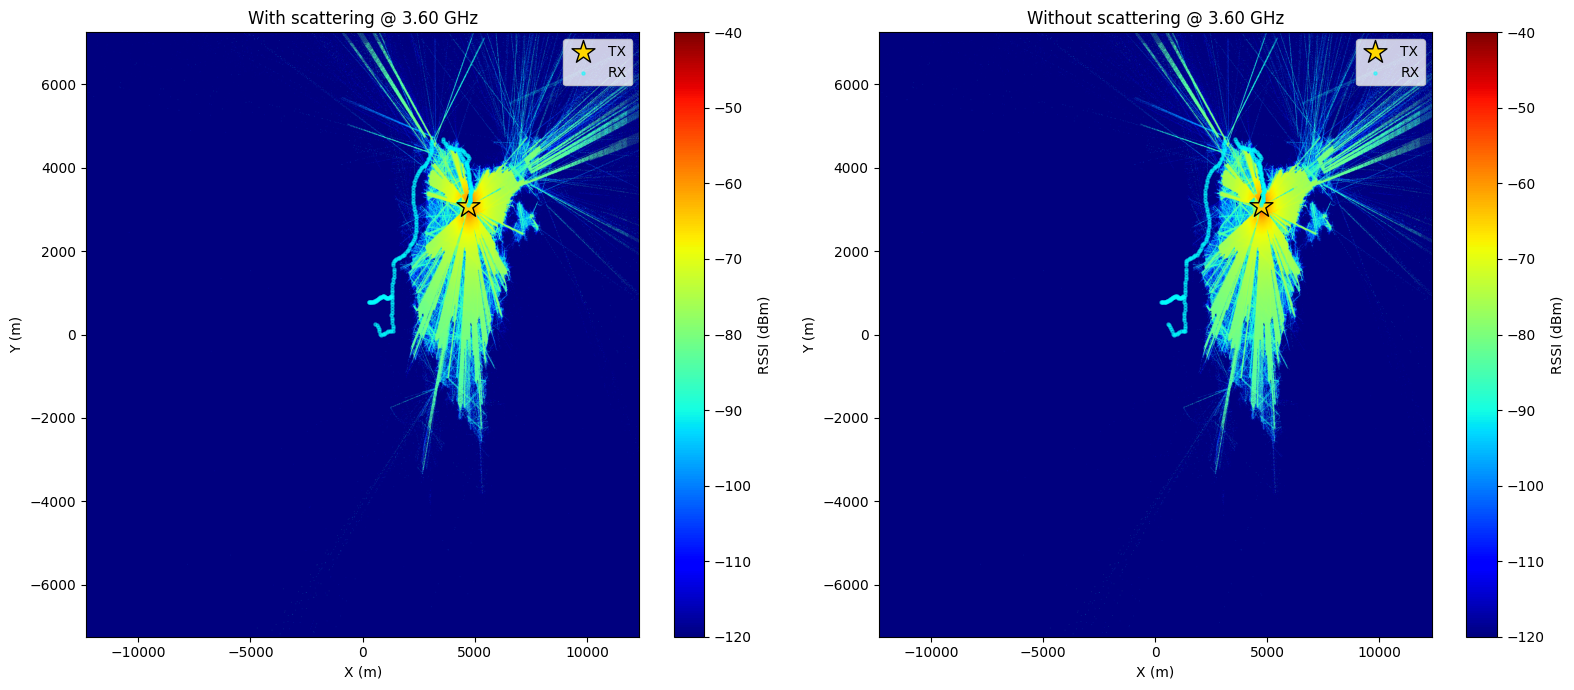

In [18]:
# ====================================================================
# CELL 10 — COVERAGE MAPS (WITH vs WITHOUT SCATTER)
# ====================================================================
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("CELL 10 — PLOTTING COVERAGE MAPS")
print("=" * 70)

# Transmitter position
tx = list(scene.transmitters.values())[0]
tx_x = _safe(tx.position[0])
tx_y = _safe(tx.position[1])

# Common colour limits (optional, can be per‑map)
vmin, vmax = -120, -40

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot with scatter
im1 = axes[0].imshow(rssi_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                     cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
axes[0].scatter(tx_x, tx_y, marker='*', s=300, c='gold', edgecolors='black', label='TX')
# Sample receivers for plotting (every 50th)
sample_step = max(1, len(receivers)//200)
rx_sample = receivers[::sample_step]
rx_plot_x = [_safe(rx.position[0]) for rx in rx_sample]
rx_plot_y = [_safe(rx.position[1]) for rx in rx_sample]
axes[0].scatter(rx_plot_x, rx_plot_y, s=5, c='cyan', alpha=0.5, label='RX')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title(f'With scattering @ {FREQUENCY_HZ/1e9:.2f} GHz')
axes[0].legend()
plt.colorbar(im1, ax=axes[0], label='RSSI (dBm)')

# Plot without scatter
im2 = axes[1].imshow(rssi_no_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                     cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
axes[1].scatter(tx_x, tx_y, marker='*', s=300, c='gold', edgecolors='black', label='TX')
axes[1].scatter(rx_plot_x, rx_plot_y, s=5, c='cyan', alpha=0.5, label='RX')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title(f'Without scattering @ {FREQUENCY_HZ/1e9:.2f} GHz')
axes[1].legend()
plt.colorbar(im2, ax=axes[1], label='RSSI (dBm)')

plt.tight_layout()

# Save combined figure
out_path = os.path.join(OUT_DIR, "coverage_map_comparison.png")
plt.savefig(out_path, dpi=150)
print(f"Comparison map saved to {out_path}")
plt.show()

## Cell 10a – Detailed comparison of propagation mechanisms

## CELL 10a — Scatter vs No-Scatter Propagation Comparison
Computes difference maps and histograms to quantify the impact of diffuse scattering on coverage.

CELL 11 — PROPAGATION COMPARISON (SCATTER vs NO SCATTER)
Noise floor: -96.0 dBm (BW=20 MHz, NF=5.0 dB)
Maps saved to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/propagation_comparison_maps.png


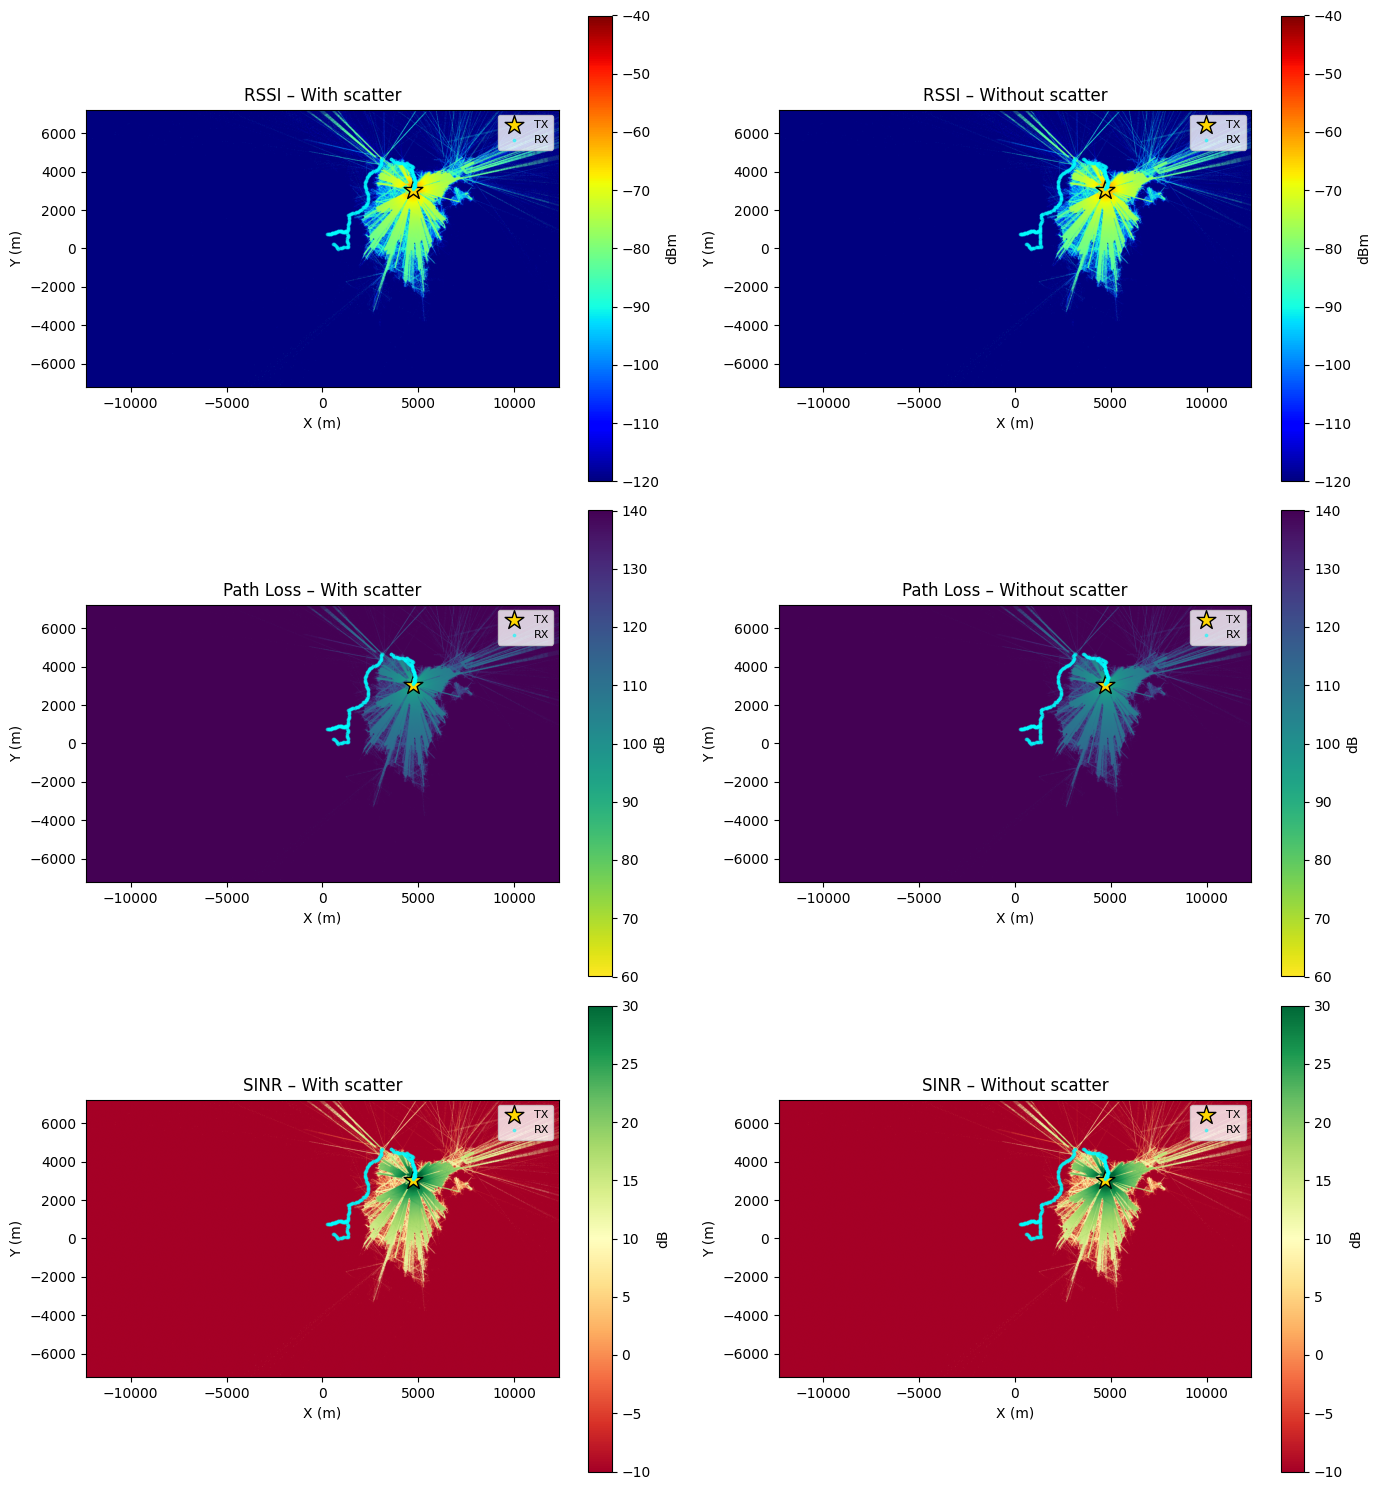

Difference map saved to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/scattering_impact_map.png


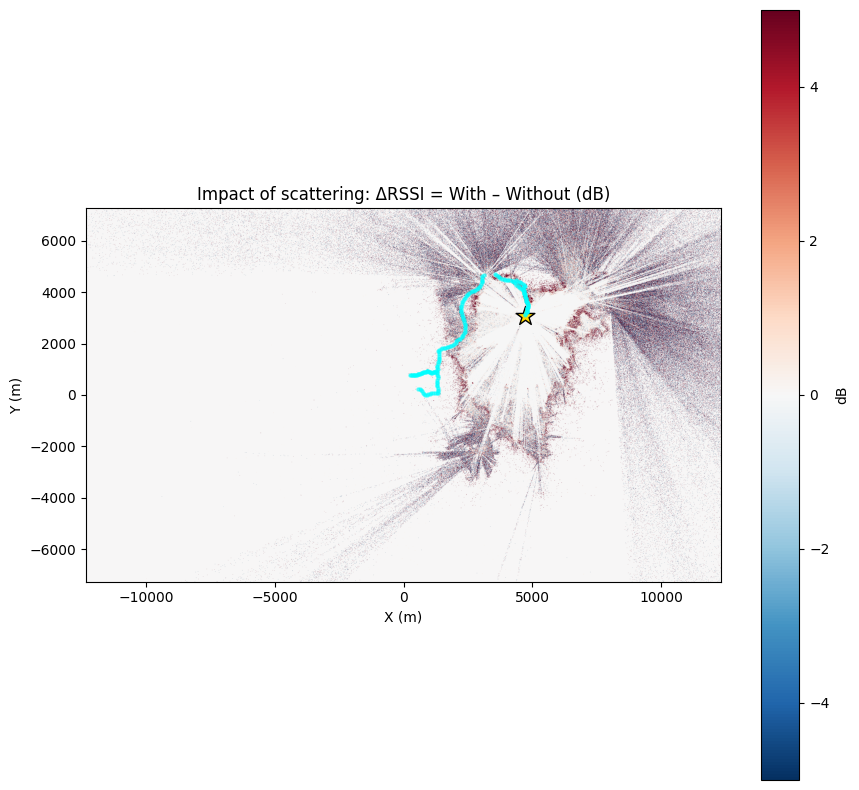

Receiver comparison plot saved to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/receiver_scatter_comparison.png


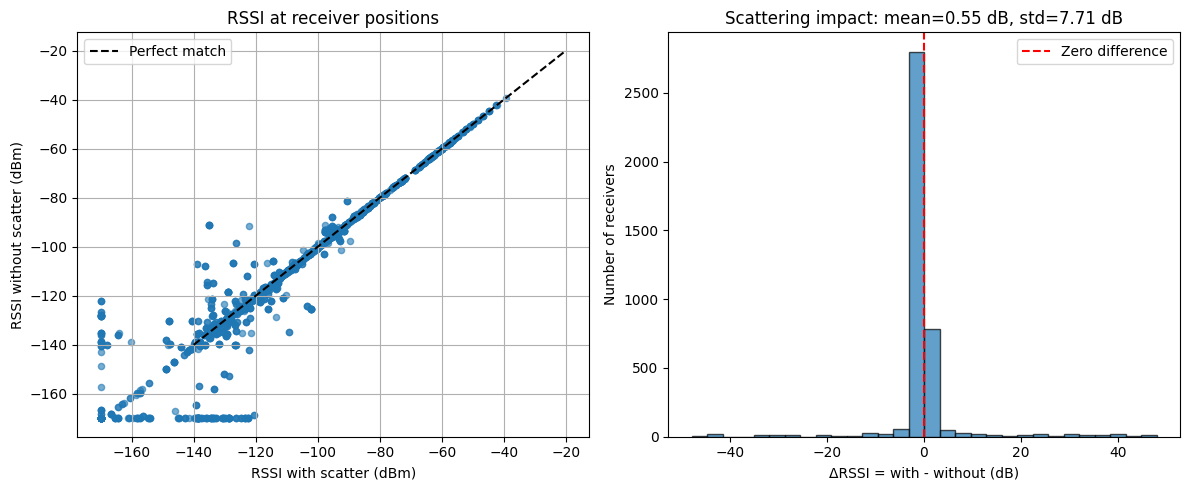


✅ Comparison completed.


In [19]:
# ====================================================================
# CELL 10a — COMPARISON: WITH SCATTER vs WITHOUT SCATTER
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np
import os

print("=" * 70)
print("CELL 11 — PROPAGATION COMPARISON (SCATTER vs NO SCATTER)")
print("=" * 70)

# ------------------------------------------------------------------
# 1. System parameters for SINR
# ------------------------------------------------------------------
BW_HZ = 20e6          # Bandwidth (Hz)
NF_DB = 5.0           # Noise figure (dB)
kT_dBm_Hz = -174.0    # Thermal noise power spectral density (dBm/Hz)
noise_dbm = kT_dBm_Hz + 10 * np.log10(BW_HZ) + NF_DB
print(f"Noise floor: {noise_dbm:.1f} dBm (BW={BW_HZ/1e6:.0f} MHz, NF={NF_DB} dB)")

# Compute SINR maps (dB)
sinr_scatter     = rssi_scatter - noise_dbm
sinr_no_scatter  = rssi_no_scatter - noise_dbm

# Compute linear path gain (not dB) from path loss
path_gain_scatter_db    = -path_loss_scatter
path_gain_no_scatter_db = -path_loss_no_scatter
# Convert to linear for possible further analysis
path_gain_scatter_lin    = 10**(path_gain_scatter_db / 10)
path_gain_no_scatter_lin = 10**(path_gain_no_scatter_db / 10)

# ------------------------------------------------------------------
# 2. Plotting – side by side for RSSI, Path Loss, SINR
# ------------------------------------------------------------------
vmin_rssi, vmax_rssi = -120, -40
vmin_pl,   vmax_pl   =  60,  140   # path loss range typical
vmin_sinr, vmax_sinr = -10,  30    # SINR range (dB)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# RSSI with scatter
im = axes[0,0].imshow(rssi_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='jet', vmin=vmin_rssi, vmax=vmax_rssi)
axes[0,0].set_title("RSSI – With scatter")
plt.colorbar(im, ax=axes[0,0], label='dBm')

# RSSI without scatter
im = axes[0,1].imshow(rssi_no_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='jet', vmin=vmin_rssi, vmax=vmax_rssi)
axes[0,1].set_title("RSSI – Without scatter")
plt.colorbar(im, ax=axes[0,1], label='dBm')

# Path Loss with scatter
im = axes[1,0].imshow(path_loss_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='viridis_r', vmin=vmin_pl, vmax=vmax_pl)
axes[1,0].set_title("Path Loss – With scatter")
plt.colorbar(im, ax=axes[1,0], label='dB')

# Path Loss without scatter
im = axes[1,1].imshow(path_loss_no_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='viridis_r', vmin=vmin_pl, vmax=vmax_pl)
axes[1,1].set_title("Path Loss – Without scatter")
plt.colorbar(im, ax=axes[1,1], label='dB')

# SINR with scatter
im = axes[2,0].imshow(sinr_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='RdYlGn', vmin=vmin_sinr, vmax=vmax_sinr)
axes[2,0].set_title("SINR – With scatter")
plt.colorbar(im, ax=axes[2,0], label='dB')

# SINR without scatter
im = axes[2,1].imshow(sinr_no_scatter, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
                      cmap='RdYlGn', vmin=vmin_sinr, vmax=vmax_sinr)
axes[2,1].set_title("SINR – Without scatter")
plt.colorbar(im, ax=axes[2,1], label='dB')

# Common transmitter / receiver overlay for all plots (optional)
tx_x = _safe(tx.position[0]); tx_y = _safe(tx.position[1])
for ax_row in axes:
    for ax in ax_row:
        ax.scatter(tx_x, tx_y, marker='*', s=200, c='gold', edgecolors='black', label='TX')
        # Sample receivers
        sample_step = max(1, len(receivers)//200)
        rx_plot_x = [_safe(rx.position[0]) for rx in receivers[::sample_step]]
        rx_plot_y = [_safe(rx.position[1]) for rx in receivers[::sample_step]]
        ax.scatter(rx_plot_x, rx_plot_y, s=3, c='cyan', alpha=0.5, label='RX')
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
out_maps = os.path.join(OUT_DIR, "propagation_comparison_maps.png")
plt.savefig(out_maps, dpi=150)
print(f"Maps saved to {out_maps}")
plt.show()

# ------------------------------------------------------------------
# 3. Difference map: RSSI(with scatter) – RSSI(without scatter)
# ------------------------------------------------------------------
rssi_diff = rssi_scatter - rssi_no_scatter
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(rssi_diff, origin='lower', extent=[gx_min, gx_max, gy_min, gy_max],
               cmap='RdBu_r', vmin=-5, vmax=5)
ax.scatter(tx_x, tx_y, marker='*', s=200, c='gold', edgecolors='black', label='TX')
ax.scatter(rx_plot_x, rx_plot_y, s=5, c='cyan', alpha=0.5, label='RX')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title("Impact of scattering: ΔRSSI = With – Without (dB)")
plt.colorbar(im, label='dB')
plt.tight_layout()
out_diff = os.path.join(OUT_DIR, "scattering_impact_map.png")
plt.savefig(out_diff, dpi=150)
print(f"Difference map saved to {out_diff}")
plt.show()

# ------------------------------------------------------------------
# 4. Scatter plot at receiver positions
# ------------------------------------------------------------------
# Get data from the DataFrames created in Cell 9
rx_rssi_scatter    = df_scatter['rssi_dbm'].values
rx_rssi_no_scatter = df_no_scatter['rssi_dbm'].values
rx_pl_scatter      = df_scatter['path_loss_db'].values
rx_pl_no_scatter   = df_no_scatter['path_loss_db'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RSSI comparison
axes[0].scatter(rx_rssi_scatter, rx_rssi_no_scatter, alpha=0.6, s=20)
axes[0].plot([-140, -20], [-140, -20], 'k--', label='Perfect match')
axes[0].set_xlabel("RSSI with scatter (dBm)")
axes[0].set_ylabel("RSSI without scatter (dBm)")
axes[0].set_title("RSSI at receiver positions")
axes[0].legend()
axes[0].grid(True)

# Difference histogram
diff_rx = rx_rssi_scatter - rx_rssi_no_scatter
axes[1].hist(diff_rx, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--', label='Zero difference')
axes[1].set_xlabel("ΔRSSI = with - without (dB)")
axes[1].set_ylabel("Number of receivers")
axes[1].set_title(f"Scattering impact: mean={np.mean(diff_rx):.2f} dB, std={np.std(diff_rx):.2f} dB")
axes[1].legend()
plt.tight_layout()
out_scatter = os.path.join(OUT_DIR, "receiver_scatter_comparison.png")
plt.savefig(out_scatter, dpi=150)
print(f"Receiver comparison plot saved to {out_scatter}")
plt.show()

print("\n✅ Comparison completed.")

## CELL 11 — PATHSOLVER WITH PER‑RAY EXTRACTION (ROBUST INTERACTIONS + TYPES)

## CELL 11 — PathSolver with Per-Ray Extraction
Runs the ray-tracing PathSolver and extracts per-path attributes (type, delay, angle, loss) into a CSV for analysis.

In [30]:
# ====================================================================
# CELL 11 — PATHSOLVER WITH PER‑RAY EXTRACTION (ROBUST INTERACTIONS + TYPES)
# ====================================================================
import gc
import numpy as np
import pandas as pd
import time
import os
import drjit as dr
from datetime import datetime
from sionna.rt import PathSolver
from sionna.rt.constants import InteractionType

print("=" * 70)
print("CELL 11 — PATHSOLVER WITH PER‑RAY EXTRACTION (ROBUST)")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Configuration flags
# ------------------------------------------------------------------
SAVE_PER_RAY = True
MAX_RAYS_PER_RX = 300
BATCH_SIZE = 5
C = 3e8  # speed of light (m/s)

# ------------------------------------------------------------------
# 1. PathSolver configuration
# ------------------------------------------------------------------
PS_CONFIG = dict(
    max_depth              = 15,
    samples_per_src        = 50_000_000,
    seed                   = 42,
    los                    = True,
    specular_reflection    = True,
    diffuse_reflection     = True,
    refraction             = True,
    diffraction            = True,
    edge_diffraction       = True,
    diffraction_lit_region = True,
    synthetic_array        = False,
)

tx = list(scene.transmitters.values())[0]
tx_pwr_dbm = _safe(tx.power_dbm)   # already EIRP (includes TX gain)
tx_pos = np.array([_safe(tx.position[0]), _safe(tx.position[1]), _safe(tx.position[2])])
solver = PathSolver()
print(f"  TX power (EIRP): {tx_pwr_dbm:.1f} dBm")
print(f"  TX position (local): ({tx_pos[0]:.1f}, {tx_pos[1]:.1f}, {tx_pos[2]:.1f}) m")

# Receiver gains (from global config)
rx_gain_total = RX_GAIN_DBI + LNA_GAIN_DB
print(f"  Receiver total gain: {rx_gain_total:.1f} dB (RX_GAIN_DBI + LNA_GAIN_DB)")

# ------------------------------------------------------------------
# 2. Path type mapping
# ------------------------------------------------------------------
INTERACTION_NAME = {
    InteractionType.NONE: "NONE",
    InteractionType.SPECULAR: "SPECULAR",
    InteractionType.DIFFUSE: "DIFFUSE",
    InteractionType.REFRACTION: "REFRACTION",
    InteractionType.DIFFRACTION: "DIFFRACTION",
}

def interaction_seq_to_str(seq_dr):
    """
    Convert Dr.Jit interaction sequence (1D array) to a compact string.
    Returns empty string on failure.
    """
    try:
        if hasattr(seq_dr, 'numpy'):
            arr = seq_dr.numpy()
        else:
            arr = np.array(seq_dr)
        if arr.ndim == 0:
            return ""
        codes = arr.flatten()
        valid = [int(c) for c in codes if int(c) != 0]
        names = [INTERACTION_NAME.get(c, f"UNKNOWN_{c}") for c in valid]
        return "|".join(names)
    except Exception:
        return ""

# ------------------------------------------------------------------
# 3. Heuristic fallback for ray type (when interactions missing)
# ------------------------------------------------------------------
def heuristic_ray_type(path_length_m, los_distance_m, power_linear, max_power):
    """
    Determine ray type by comparing path length and magnitude.
    """
    if los_distance_m > 0 and abs(path_length_m - los_distance_m) / los_distance_m < 0.01:
        return "LOS"
    excess = path_length_m - los_distance_m
    mag_ratio = power_linear / max_power if max_power > 0 else 0
    if excess < 50 and mag_ratio > 0.01:
        return "REFLECTION"
    if excess >= 50 and mag_ratio > 0.001:
        return "MULTIPLE_REFLECTION"
    if mag_ratio < 0.01:
        return "DIFFRACTION"
    if mag_ratio < 0.001:
        return "SCATTERING"
    return "UNKNOWN"

# ------------------------------------------------------------------
# 4. Helper functions (complex amplitudes, tau, summary metrics)
# ------------------------------------------------------------------
def extract_complex_amplitudes(paths):
    a = paths.a
    if isinstance(a, tuple):
        a = a[0].numpy() + 1j * a[1].numpy()
    else:
        a = a.numpy()
    a = np.squeeze(a)
    if a.ndim >= 3:
        power = np.abs(a)**2
        while power.ndim > 2 and power.shape[-2] > 1:
            power = np.sum(power, axis=-2)
        while power.ndim > 2 and power.shape[-2] > 1:
            power = np.sum(power, axis=-2)
        a = np.sqrt(power)
    if a.ndim == 1:
        a = a[np.newaxis, :]
    return a

def extract_tau(paths, n_rx, n_paths):
    tau = getattr(paths, 'tau', None)
    if tau is not None:
        if isinstance(tau, tuple):
            tau = tau[0].numpy()
        else:
            tau = tau.numpy()
        tau = np.squeeze(tau)
        while tau.ndim > 2:
            tau = tau[..., 0, :]
        if tau.ndim == 1:
            tau = tau[np.newaxis, :]
        if tau.shape != (n_rx, n_paths):
            tau = np.broadcast_to(tau, (n_rx, n_paths))
    else:
        tau = np.full((n_rx, n_paths), np.nan, dtype=np.float32)
    return tau

def compute_summary_metrics(a):
    n_rx = a.shape[0]
    best = np.full(n_rx, np.nan)
    incoherent = np.full(n_rx, np.nan)
    coherent = np.full(n_rx, np.nan)
    n_paths = np.zeros(n_rx, dtype=int)
    for i in range(n_rx):
        row = a[i]
        pwr = np.abs(row)**2
        valid = pwr > 1e-20
        if not np.any(valid):
            continue
        n_paths[i] = np.sum(valid)
        best[i] = -10 * np.log10(np.max(pwr[valid]))
        incoherent[i] = -10 * np.log10(np.sum(pwr[valid]))
        coherent_power = np.abs(np.sum(row[valid]))**2
        if coherent_power > 1e-20:
            coherent[i] = -10 * np.log10(coherent_power)
    return best, incoherent, coherent, n_paths

# ------------------------------------------------------------------
# 5. Setup batch processing
# ------------------------------------------------------------------
total = len(receivers)
out_dir = OUT_DIR   # from global configuration
os.makedirs(out_dir, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_csv = os.path.join(out_dir, f"path_loss_pathsolver_{ts}.csv")
per_ray_csv = os.path.join(out_dir, f"per_ray_channel_{ts}.csv") if SAVE_PER_RAY else None
print(f"  Total receivers: {total}, Batch size: {BATCH_SIZE}")
print(f"  Summary: {os.path.basename(summary_csv)}")
if SAVE_PER_RAY:
    print(f"  Per‑ray: {os.path.basename(per_ray_csv)}, max rays/rx: {MAX_RAYS_PER_RX}")

# ------------------------------------------------------------------
# 6. Main solving loop
# ------------------------------------------------------------------
summary_results = []
per_ray_rows = []
errors = 0
t0 = time.time()
first_batch = True

for b in range(0, total, BATCH_SIZE):
    batch = receivers[b:b+BATCH_SIZE]
    # Clear and add batch
    for r in list(scene.receivers.keys()):
        scene.remove(r)
    for rx in batch:
        scene.add(rx)
    try:
        paths = solver(scene=scene, **PS_CONFIG)
        a = extract_complex_amplitudes(paths)          # (n_rx, n_paths)
        n_rx, n_paths = a.shape
        tau = extract_tau(paths, n_rx, n_paths)        # (n_rx, n_paths)
        best, incoherent, coherent, n_paths_per_rx = compute_summary_metrics(a)

        # Extract interactions (Dr.Jit array)
        inter_data = None
        if hasattr(paths, 'interactions') and paths.interactions is not None:
            try:
                inter_dr = paths.interactions
                if hasattr(inter_dr, 'numpy'):
                    inter_np = inter_dr.numpy()
                else:
                    inter_np = np.array(inter_dr)
                if inter_np.ndim == 4:
                    inter_np = inter_np[:, :, 0, :]   # assume single TX
                if inter_np.ndim == 3:
                    inter_data = inter_np
                elif inter_np.ndim == 2 and inter_np.shape[0] == inter_np.shape[1]:
                    inter_data = inter_np.T
                else:
                    inter_data = None
                if inter_data is not None:
                    print(f"  [DEBUG] Interactions shape: {inter_data.shape}")
            except Exception as e:
                print(f"  [WARN] Could not convert interactions: {e}")
                inter_data = None

        # Debug first path interaction
        if first_batch and inter_data is not None and n_rx > 0 and n_paths > 0:
            try:
                seq0 = inter_data[:, 0, 0]
                names = []
                for val in seq0:
                    v = int(val) if hasattr(val, '__int__') else val
                    if v != 0:
                        names.append(INTERACTION_NAME.get(v, f"UNKNOWN_{v}"))
                print(f"  [DEBUG] First path interaction sequence: {'|'.join(names)}")
            except Exception as e:
                print(f"  [DEBUG] Could not extract interaction sequence: {e}")
            first_batch = False

        # Map batch receivers
        rx_name_to_idx = {rx.name: i for i, rx in enumerate(batch)}
        # Pre-compute LOS distance for each receiver in the batch
        los_distances = []
        for rx in batch:
            rx_pos = np.array([_safe(rx.position[0]), _safe(rx.position[1]), _safe(rx.position[2])])
            los_dist = np.linalg.norm(rx_pos - tx_pos)
            los_distances.append(los_dist)

        for rx_idx, rx in enumerate(batch):
            rx_pos = np.array([_safe(rx.position[0]), _safe(rx.position[1]), _safe(rx.position[2])])
            dist_tx = los_distances[rx_idx]

            if rx.name not in rx_name_to_idx:
                continue
            idx = rx_name_to_idx[rx.name]
            if idx >= n_rx:
                # No paths for this receiver
                summary_results.append({
                    'receiver': rx.name,
                    'x_m': _safe(rx.position[0]),
                    'y_m': _safe(rx.position[1]),
                    'z_m': _safe(rx.position[2]),
                    'dist_from_tx_m': dist_tx,
                    'num_paths': 0,
                    'path_loss_best_db': None,
                    'path_loss_incoherent_db': None,
                    'path_loss_coherent_db': None,
                })
                continue

            # Summary row
            summary_results.append({
                'receiver': rx.name,
                'x_m': _safe(rx.position[0]),
                'y_m': _safe(rx.position[1]),
                'z_m': _safe(rx.position[2]),
                'dist_from_tx_m': dist_tx,
                'num_paths': int(n_paths_per_rx[idx]),
                'path_loss_best_db': float(best[idx]) if not np.isnan(best[idx]) else None,
                'path_loss_incoherent_db': float(incoherent[idx]) if not np.isnan(incoherent[idx]) else None,
                'path_loss_coherent_db': float(coherent[idx]) if not np.isnan(coherent[idx]) else None,
            })

            # Per‑ray data
            if SAVE_PER_RAY:
                amps = a[idx]
                pwr = np.abs(amps)**2
                sorted_idx = np.argsort(pwr)[::-1]
                n_rays = min(len(sorted_idx), MAX_RAYS_PER_RX)
                strongest_phase = np.angle(amps[sorted_idx[0]], deg=True) if n_rays > 0 else 0
                strongest_power = pwr[sorted_idx[0]] if n_rays > 0 else 1e-20

                for ray_pos, ray_idx in enumerate(sorted_idx[:n_rays]):
                    ac = amps[ray_idx]
                    pwr_ray = pwr[ray_idx]
                    phase_deg = np.angle(ac, deg=True)
                    delay_s = tau[idx][ray_idx] if not np.isnan(tau[idx][ray_idx]) else None
                    path_length = delay_s * C if delay_s else np.nan

                    # Determine ray type
                    ray_type = "UNKNOWN"
                    if inter_data is not None and idx < inter_data.shape[1] and ray_idx < inter_data.shape[2]:
                        try:
                            seq = inter_data[:, idx, ray_idx]
                            ray_type = interaction_seq_to_str(seq)
                        except Exception:
                            pass
                    # Fallback to heuristic if interaction string is empty or "UNKNOWN"
                    if ray_type == "" or ray_type == "UNKNOWN":
                        if not np.isnan(path_length) and dist_tx > 0:
                            ray_type = heuristic_ray_type(path_length, dist_tx, pwr_ray, strongest_power)
                        else:
                            ray_type = "HEURISTIC_FAIL"

                    # Phase difference from strongest ray
                    phase_diff = phase_deg - strongest_phase
                    phase_diff = (phase_diff + 180) % 360 - 180
                    constr_destr = "CONSTRUCTIVE" if abs(phase_diff) < 90 else "DESTRUCTIVE"
                    if ray_idx == sorted_idx[0]:
                        constr_destr = "STRONGEST"

                    per_ray_rows.append({
                        'receiver_name': rx.name,
                        'ray_index': int(ray_idx),
                        'ray_type': ray_type,
                        'interaction_sequence': ray_type,  # keep for compatibility
                        'amplitude_real': float(ac.real),
                        'amplitude_imag': float(ac.imag),
                        'power_linear': float(pwr_ray),
                        'path_loss_db': None if pwr_ray <= 0 else -10*np.log10(pwr_ray),
                        'phase_deg': phase_deg,
                        'phase_diff_deg': phase_diff,
                        'constructive_destructive': constr_destr,
                        'delay_s': delay_s,
                        'path_length_m': path_length,
                    })

        del paths, a, tau, inter_data
    except Exception as e:
        print(f"  Batch {b} error: {e}")
        for rx in batch:
            rx_pos = np.array([_safe(rx.position[0]), _safe(rx.position[1]), _safe(rx.position[2])])
            dist_tx = np.linalg.norm(rx_pos - tx_pos)
            summary_results.append({'receiver': rx.name, 'x_m': _safe(rx.position[0]),
                'y_m': _safe(rx.position[1]), 'z_m': _safe(rx.position[2]),
                'dist_from_tx_m': dist_tx, 'num_paths': 0,
                'path_loss_best_db': None, 'path_loss_incoherent_db': None,
                'path_loss_coherent_db': None})
        errors += len(batch)
    gc.collect()
    done = min(b + BATCH_SIZE, total)
    if done % max(1, total//20) == 0 or done == total:
        elapsed = time.time() - t0
        rate = done / (elapsed + 1e-9)
        eta = (total - done) / (rate + 1e-9)
        print(f"  {done}/{total} ({100*done/total:.1f}%)  ETA {eta/60:.1f} min", flush=True)

# Restore all receivers
for r in list(scene.receivers.keys()):
    scene.remove(r)
for rx in receivers:
    scene.add(rx)

# ------------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------------
print("\n[5/6] Saving results...")
df_summary = pd.DataFrame(summary_results)
df_summary['rssi_best_dbm'] = tx_pwr_dbm - df_summary['path_loss_best_db'] + rx_gain_total
df_summary['rssi_incoherent_dbm'] = tx_pwr_dbm - df_summary['path_loss_incoherent_db'] + rx_gain_total
df_summary['rssi_coherent_dbm'] = tx_pwr_dbm - df_summary['path_loss_coherent_db'] + rx_gain_total
df_summary.to_csv(summary_csv, index=False)
print(f"  ✓ Saved summary: {os.path.basename(summary_csv)}")

if SAVE_PER_RAY and per_ray_rows:
    df_per_ray = pd.DataFrame(per_ray_rows)
    df_per_ray.to_csv(per_ray_csv, index=False)
    print(f"  ✓ Saved per‑ray: {os.path.basename(per_ray_csv)}")
    print(f"    Total rays saved: {len(df_per_ray)}")

elapsed = time.time() - t0
print(f"\nTime: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Receivers processed: {len(df_summary)}")
print(f"Errors: {errors}")

valid = df_summary.dropna(subset=['path_loss_incoherent_db'])
if len(valid) > 0:
    pl = valid['path_loss_incoherent_db']
    print(f"Path Loss (incoherent): min={pl.min():.2f} dB, max={pl.max():.2f} dB, mean={pl.mean():.2f} dB")
    if 'path_loss_coherent_db' in valid.columns:
        plc = valid['path_loss_coherent_db'].dropna()
        if len(plc) > 0:
            print(f"Path Loss (coherent):   min={plc.min():.2f} dB, max={plc.max():.2f} dB, mean={plc.mean():.2f} dB")
    print(f"Distance from TX: min={valid['dist_from_tx_m'].min():.1f} m, max={valid['dist_from_tx_m'].max():.1f} m, mean={valid['dist_from_tx_m'].mean():.1f} m")

print("\n✅ Cell 11 complete – per‑ray data includes ray types, phase differences, and constructive/destructive flags.")

CELL 11 — PATHSOLVER WITH PER‑RAY EXTRACTION (ROBUST)
  TX power (EIRP): 30.0 dBm
  TX position (local): (4711.1, 3074.4, 17.0) m
  Receiver total gain: 0.0 dB (RX_GAIN_DBI + LNA_GAIN_DB)
  Total receivers: 3048, Batch size: 5
  Summary: path_loss_pathsolver_20260601_000355.csv
  Per‑ray: per_ray_channel_20260601_000355.csv, max rays/rx: 300


AttributeError: 'str' object has no attribute 'name'

## Diagnostic Cell to see which parameter killed the paths

## CELL 11A — Building Density Diagnostic
Computes building count and average height in concentric rings around the TX to diagnose path blockage.

In [16]:
# ====================================================================
# BUILDING DENSITY BY DISTANCE FROM TX — the key diagnostic
# ====================================================================
import numpy as np

tx     = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]),
                   _safe(tx.position[1]),
                   _safe(tx.position[2])])

print("BUILDING DENSITY BY DISTANCE FROM TX")
print("=" * 60)

rings = [(0,250),(250,500),(500,750),(750,1000),
         (1000,1500),(1500,2000),(2000,3000),(3000,5000)]

for lo, hi in rings:
    heights = []
    for obj in scene.objects.values():
        try:
            bbox = obj.mi_shape.bbox()
            cx   = (float(bbox.min[0]) + float(bbox.max[0])) / 2
            cy   = (float(bbox.min[1]) + float(bbox.max[1])) / 2
            d    = np.sqrt((cx - tx_pos[0])**2 + (cy - tx_pos[1])**2)
            h    = float(bbox.max[2]) - float(bbox.min[2])
            if lo < d <= hi and h > 2.0:
                heights.append(h)
        except:
            pass

    n        = len(heights)
    area_km2 = np.pi * (hi**2 - lo**2) / 1e6
    density  = n / area_km2 if area_km2 > 0 else 0
    avg_h    = float(np.mean(heights)) if n > 0 else 0
    flag     = "✅" if density > 10 else ("⚠️  sparse" if density > 2 else "❌ EMPTY")

    print(f"  {lo:>5}–{hi:<5}m  "
          f"N={n:>5}  "
          f"density={density:>8.1f}/km²  "
          f"avg_h={avg_h:>5.1f}m  {flag}")

print()
print(f"Total objects in scene       : {len(scene.objects)}")
print(f"TX position                  : ({tx_pos[0]:.1f}, {tx_pos[1]:.1f}, {tx_pos[2]:.1f})")
print("=" * 60)

BUILDING DENSITY BY DISTANCE FROM TX
      0–250  m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
    250–500  m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
    500–750  m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
    750–1000 m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
   1000–1500 m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
   1500–2000 m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
   2000–3000 m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY
   3000–5000 m  N=    0  density=     0.0/km²  avg_h=  0.0m  ❌ EMPTY

Total objects in scene       : 3
TX position                  : (-2392.8, 46.0, 39.0)


## CELL 11B — Single-Receiver Ray Preview
Reduces the scene to one receiver, runs the PathSolver, and launches the interactive 3D ray viewer.

In [21]:
# Setup: keep only one receiver for clarity
for rx_name in list(scene.receivers.keys())[1:]:
    scene.remove(rx_name)

# Compute paths
solver = PathSolver()
paths = solver(scene=scene, **PS_CONFIG)

# Interactive 3D view with rays
scene.preview(paths=paths)

## CELL 11C — Radio Map Preview Overlay
Overlays the computed radio map (path gain, dB scale) onto the 3D scene preview widget.

In [18]:
scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain")

NameError: name 'rm' is not defined

## CELL 12 — Per-Receiver Statistics
Calculates RMS delay spread, K-factor, and best/incoherent/coherent path loss for every receiver from the saved CSV.

In [22]:
# ====================================================================
# CELL 12 — PER‑RECEIVER STATISTICS (BEST, INCOHERENT, COHERENT)
# ====================================================================
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

print("=" * 70)
print("CELL 12 — RMS DELAY SPREAD & K‑FACTOR (all path loss types)")
print("=" * 70)

if 'OUT_DIR' not in locals():
    OUT_DIR = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"

per_ray_files = glob.glob(os.path.join(OUT_DIR, "per_ray_channel_*.csv"))
if not per_ray_files:
    raise FileNotFoundError("No per‑ray CSV found. Run Cell 11 with SAVE_PER_RAY=True")
latest_per_ray = max(per_ray_files, key=os.path.getctime)
df_ray = pd.read_csv(latest_per_ray)
print(f"Loaded {len(df_ray)} rays from {os.path.basename(latest_per_ray)}")

# Compute per‑receiver statistics
stats = []
for rx_name, group in df_ray.groupby('receiver_name'):
    power = group['power_linear'].values
    phases_deg = group['phase_deg'].values

    # Complex amplitude: sqrt(power) * exp(j*phase_rad)
    phases_rad = np.deg2rad(phases_deg)
    complex_amp = np.sqrt(power) * np.exp(1j * phases_rad)

    total_power = np.sum(power)                     # incoherent
    max_power = np.max(power)                       # best ray
    coherent_power = np.abs(np.sum(complex_amp))**2

    if total_power <= 0:
        continue

    pl_incoherent = -10 * np.log10(total_power)
    pl_best       = -10 * np.log10(max_power)
    pl_coherent   = -10 * np.log10(coherent_power) if coherent_power > 0 else np.nan

    # RMS delay spread (uses power weights)
    delays = group['delay_s'].values
    mean_delay = np.sum(power * delays) / total_power
    rms_delay = np.sqrt(np.sum(power * (delays - mean_delay)**2) / total_power)

    # K‑factor (dominant vs diffuse)
    k_lin = max_power / (total_power - max_power + 1e-12)
    k_db = 10 * np.log10(k_lin)

    # Path type counts (if available)
    type_col = None
    if 'path_type' in df_ray.columns:
        type_col = 'path_type'
    elif 'interaction_sequence' in df_ray.columns:
        type_col = 'interaction_sequence'
    if type_col is not None:
        if type_col == 'interaction_sequence':
            types = group[type_col].fillna('').apply(lambda s: s.split('|')[0] if s else 'UNKNOWN')
        else:
            types = group[type_col]
        type_counts = types.value_counts().to_dict()
    else:
        type_counts = {}

    stats.append({
        'receiver': rx_name,
        'num_paths': len(group),
        'path_loss_best_db': pl_best,
        'path_loss_incoherent_db': pl_incoherent,
        'path_loss_coherent_db': pl_coherent,
        'rms_delay_spread_ns': rms_delay * 1e9,
        'k_factor_db': k_db,
        **{f'count_{k}': v for k, v in type_counts.items()}
    })

df_stats = pd.DataFrame(stats).fillna(0)

# Natural sorting by receiver number
def extract_number(name):
    match = re.search(r'\d+', name)
    return int(match.group()) if match else 0
df_stats['_sort_key'] = df_stats['receiver'].apply(extract_number)
df_stats = df_stats.sort_values('_sort_key').drop(columns=['_sort_key'])

stats_csv = os.path.join(OUT_DIR, "path_stats_per_rx.csv")
df_stats.to_csv(stats_csv, index=False)
print(f"Saved per‑receiver statistics (best, incoherent, coherent) to {stats_csv}")

# ... (rest of plotting code unchanged) ...

# ------------------------------------------------------------------
# CDF plots (unchanged)
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# RMS delay spread
rms_valid = df_stats['rms_delay_spread_ns'].dropna()
rms_valid = rms_valid[rms_valid > 0]
if len(rms_valid):
    ax[0].plot(np.sort(rms_valid), np.linspace(0, 1, len(rms_valid)), 'b-', lw=2)
    ax[0].set_xlabel('RMS Delay Spread (ns)')
    ax[0].set_ylabel('CDF')
    ax[0].set_title('Delay Spread Distribution')
    ax[0].grid(True)
# K‑factor
k_valid = df_stats['k_factor_db'].replace([np.inf, -np.inf], np.nan).dropna()
if len(k_valid):
    ax[1].plot(np.sort(k_valid), np.linspace(0, 1, len(k_valid)), 'r-', lw=2)
    ax[1].set_xlabel('K‑factor (dB)')
    ax[1].set_ylabel('CDF')
    ax[1].set_title('K‑factor Distribution')
    ax[1].grid(True)

plt.tight_layout()
cdf_png = os.path.join(OUT_DIR, "rms_k_cdf.png")
plt.savefig(cdf_png, dpi=150)
plt.close()
print(f"Saved CDF plot to {cdf_png}")

# Histogram of number of paths
plt.figure(figsize=(8,5))
plt.hist(df_stats['num_paths'], bins=50, alpha=0.7, color='green')
plt.xlabel('Number of paths per receiver')
plt.ylabel('Frequency')
plt.title('Multipath Count Distribution')
plt.grid(True)
hist_png = os.path.join(OUT_DIR, "num_paths_hist.png")
plt.savefig(hist_png, dpi=150)
plt.close()
print(f"Saved histogram to {hist_png}")

print("\n✅ Cell 12 complete – receivers sorted naturally in output CSV")

CELL 12 — RMS DELAY SPREAD & K‑FACTOR (all path loss types)
Loaded 603150 rays from per_ray_channel_20260531_225600.csv
Saved per‑receiver statistics (best, incoherent, coherent) to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/path_stats_per_rx.csv
Saved CDF plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/rms_k_cdf.png
Saved histogram to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/num_paths_hist.png

✅ Cell 12 complete – receivers sorted naturally in output CSV


## Cell 13 – Propagation Mechanism Comparison

## CELL 13 — Propagation Mechanism Comparison
Runs the PathSolver with LOS-only, reflection-only, and combined modes to compare individual propagation mechanisms.

In [23]:
# ====================================================================
# CELL 13 — PROPAGATION MECHANISM COMPARISON (OPTIONAL)
# ====================================================================
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sionna.rt import PathSolver

print("=" * 70)
print("CELL 13 — MECHANISM COMPARISON (subset of receivers)")
print("=" * 70)

# Get TX power from scene if not already defined (not actually used in PL formula)
try:
    tx_pwr_dbm = _safe(list(scene.transmitters.values())[0].power_dbm)
except:
    tx_pwr_dbm = 30.0

SUBSET_SIZE = 20   # Use first N receivers (increase for more accuracy, but slower)
rx_subset = receivers[:SUBSET_SIZE]
print(f"Using first {SUBSET_SIZE} receivers for comparison")

base_conf = {
    'max_depth': 8,
    'samples_per_src': 10_000_000,
    'seed': 42,
    'los': True,
    'specular_reflection': True,
    'diffuse_reflection': True,
    'refraction': True,
    'diffraction': True,
    'edge_diffraction': True,
    'diffraction_lit_region': True,
    'synthetic_array': False,
}

scenarios = {
    'full': base_conf.copy(),
    'no_diffraction': {**base_conf, 'diffraction': False, 'edge_diffraction': False},
    'no_refraction': {**base_conf, 'refraction': False},
    'no_edge_diffraction': {**base_conf, 'edge_diffraction': False},
    'only_los_specular': {**base_conf,
                          'diffraction': False, 'edge_diffraction': False,
                          'refraction': False, 'diffuse_reflection': False},
}

results = {}
solver = PathSolver()

for name, conf in scenarios.items():
    print(f"\n--- Running: {name} ---")
    # Clear and add subset
    for r in list(scene.receivers.keys()):
        scene.remove(r)
    for rx in rx_subset:
        scene.add(rx)
    try:
        t0 = time.time()
        paths = solver(scene=scene, **conf)
        elapsed = time.time() - t0
        a = paths.a
        if isinstance(a, tuple):
            a = a[0].numpy() + 1j * a[1].numpy()
        else:
            a = a.numpy()
        a = np.squeeze(a)
        if a.ndim == 1:
            a = a[np.newaxis, :]
        # Incoherent power sum
        power_lin = np.sum(np.abs(a)**2, axis=1)
        # Path loss = -10*log10(total power)
        pl_db = -10 * np.log10(power_lin + 1e-15)
        results[name] = {
            'path_loss_db': pl_db,
            'time_s': elapsed,
            'num_receivers': len(rx_subset)
        }
        print(f"  Completed in {elapsed:.1f}s, mean PL = {np.mean(pl_db):.1f} dB")
    except Exception as e:
        print(f"  Failed: {e}")
        results[name] = None

# Restore all receivers
for r in list(scene.receivers.keys()):
    scene.remove(r)
for rx in receivers:
    scene.add(rx)

# Use global output directory (Cell 1)
os.makedirs(OUT_DIR, exist_ok=True)

# Compile and save comparison
comparison = []
for name, res in results.items():
    if res is not None:
        comparison.append({
            'scenario': name,
            'mean_path_loss_db': np.mean(res['path_loss_db']),
            'std_path_loss_db': np.std(res['path_loss_db']),
            'min_path_loss_db': np.min(res['path_loss_db']),
            'max_path_loss_db': np.max(res['path_loss_db']),
            'time_seconds': res['time_s'],
        })
df_comp = pd.DataFrame(comparison)
comp_csv = os.path.join(OUT_DIR, "propagation_mechanism_comparison.csv")
df_comp.to_csv(comp_csv, index=False)
print(f"\nSaved mechanism comparison to {comp_csv}")
print(df_comp.to_string())

# Bar plot
plt.figure(figsize=(10,6))
plt.bar(df_comp['scenario'], df_comp['mean_path_loss_db'],
        yerr=df_comp['std_path_loss_db'], capsize=5, color='steelblue')
plt.ylabel('Mean Path Loss (dB)')
plt.title('Impact of Propagation Mechanisms on Path Loss')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
out_bar = os.path.join(OUT_DIR, "mechanism_comparison_bar.png")
plt.tight_layout()
plt.savefig(out_bar, dpi=150)
plt.close()
print(f"Saved bar plot to {out_bar}")

print("\n✅ Cell 13 complete")

CELL 13 — MECHANISM COMPARISON (subset of receivers)
Using first 20 receivers for comparison

--- Running: full ---
  Completed in 1.6s, mean PL = 148.6 dB

--- Running: no_diffraction ---
  Completed in 0.8s, mean PL = 148.6 dB

--- Running: no_refraction ---
  Completed in 1.3s, mean PL = 148.6 dB

--- Running: no_edge_diffraction ---
  Completed in 1.3s, mean PL = 148.6 dB

--- Running: only_los_specular ---
  Completed in 0.7s, mean PL = 133.3 dB

Saved mechanism comparison to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/propagation_mechanism_comparison.csv
              scenario  mean_path_loss_db  std_path_loss_db  min_path_loss_db  max_path_loss_db  time_seconds
0                 full         148.621872          4.132984        136.222931        150.000015      1.595622
1       no_diffraction         148.622314          4.132366        136.225220        150.000015      0.825000
2        no_refraction         148.621902          4.132968       

## CELL 14 — Comprehensive Path Loss Metrics & Distance Analysis
Computes RMSE, MAE, bias, and Spearman correlation for best/incoherent/coherent path loss versus measurements.

CELL 14 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS
Using output directory: /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat
Matched 2861 receivers

OVERALL METRICS (ALL RECEIVERS)
Type          RMSE (dB)   MAE (dB)  MSE (dB²)       R²  Bias (dB) Spearman ρ
best              28.99      22.43     840.57   -1.974       3.59      0.240
incoherent        28.74      21.84     826.00   -1.923       0.46      0.239
coherent          29.54      22.14     872.71   -2.098       0.58      0.231

DISTANCE BIN ANALYSIS (sliding bins, width = 250 m)
 dist_bin  avg_dist_m  n_receivers  avg_num_paths  best_RMSE  best_bias  incoherent_RMSE  incoherent_bias  coherent_RMSE  coherent_bias
    0-250      159.84          153       71658.41      62.75     -45.09            63.03           -45.53          70.85         -56.25
  250-500      373.99          178       46688.75      18.24     -16.11            19.54           -17.91          27.31         -24.18
  500-750  

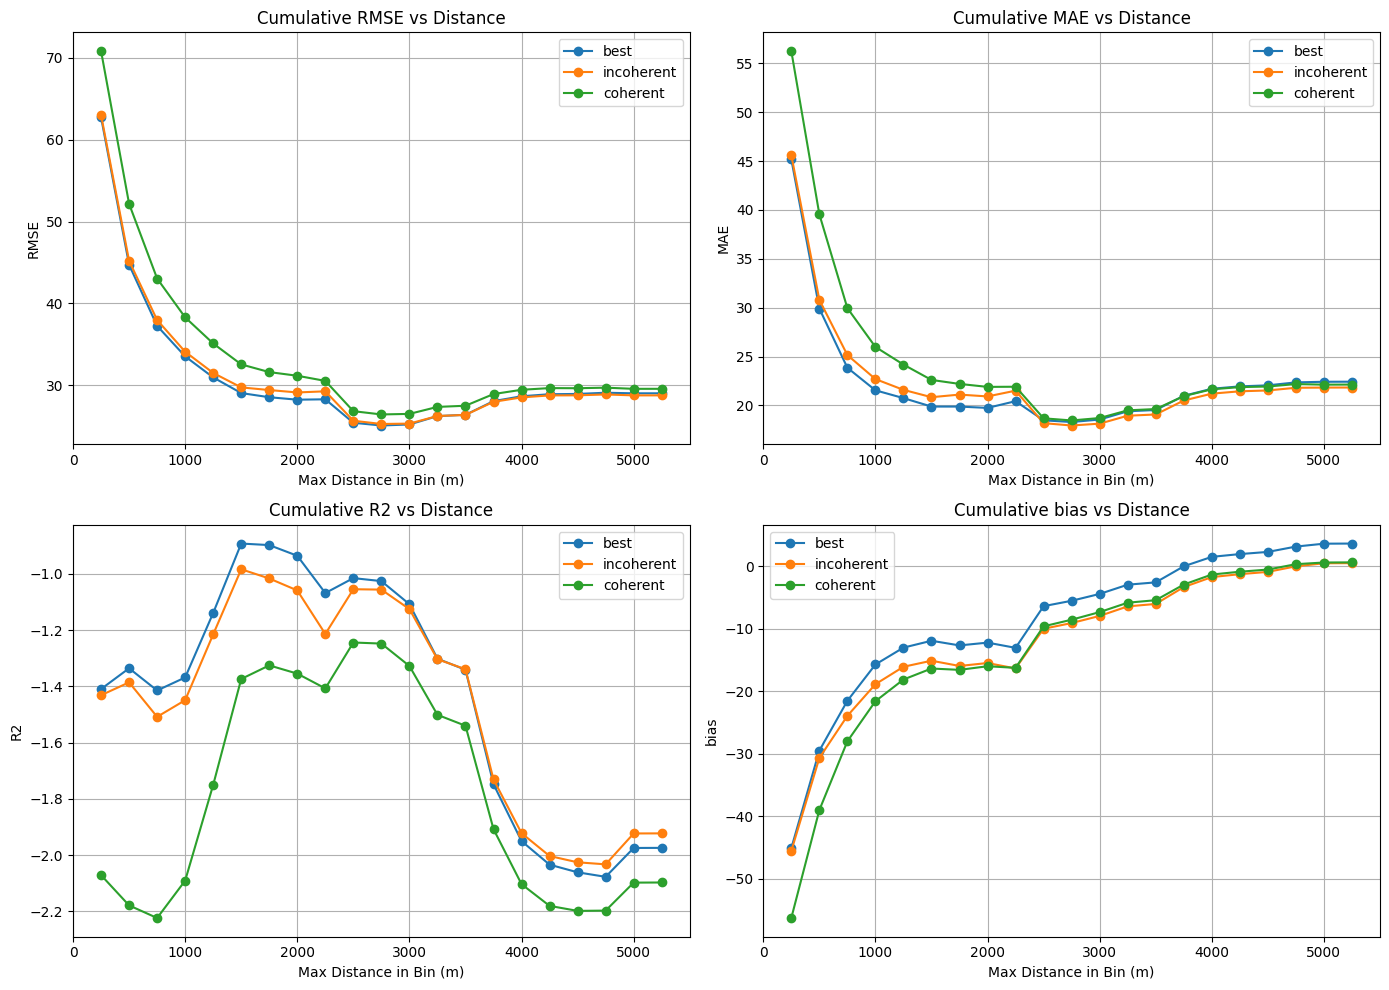

Saved cumulative metrics plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/cumulative_metrics_plot.png


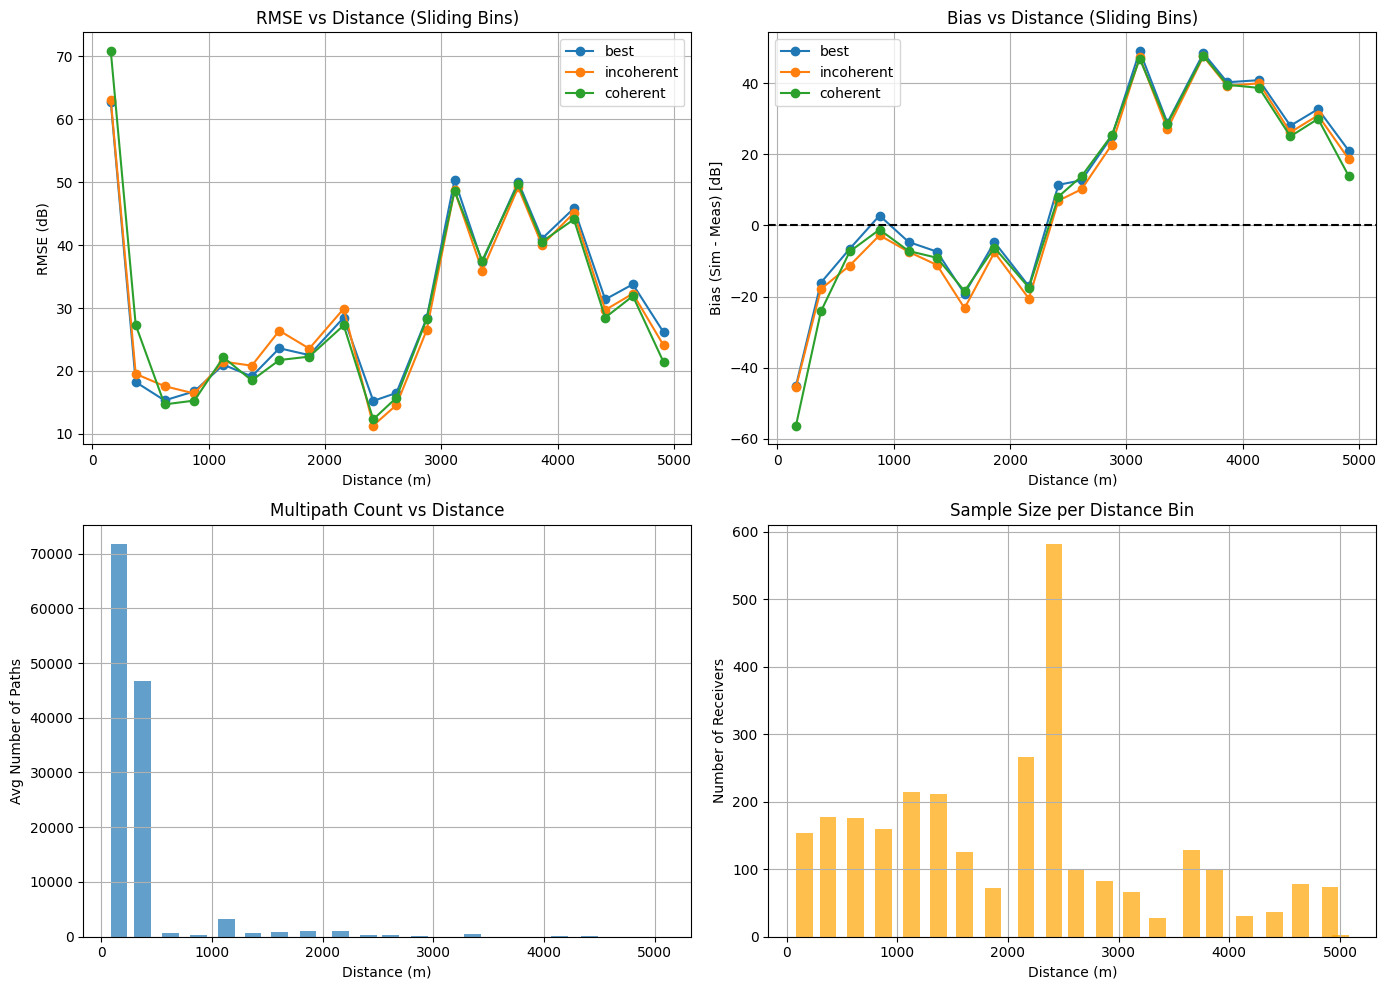

Saved sliding bin analysis plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/distance_analysis.png


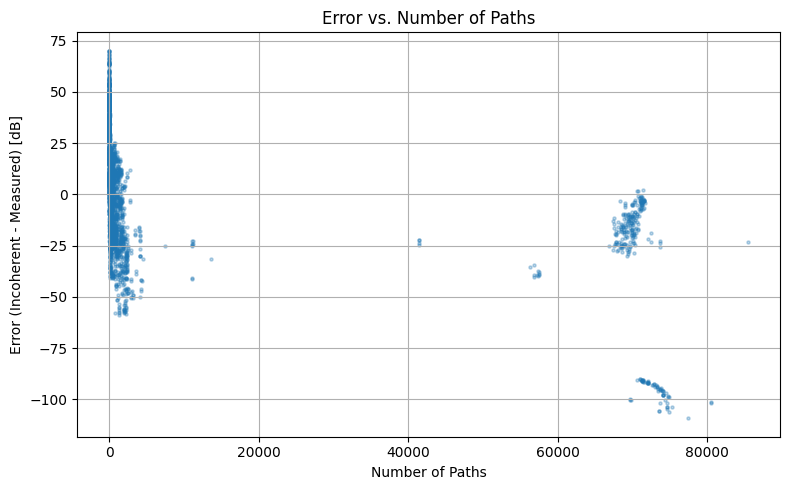

Saved error vs paths plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/error_vs_num_paths.png

✅ Cell 14 complete – metrics computed for best, incoherent, coherent path loss (sliding + cumulative bins).


In [24]:
# ====================================================================
# CELL 14 — COMPREHENSIVE METRICS FOR ALL PATH LOSS TYPES + DISTANCE ANALYSIS
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 14 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Ensure global output directory from Cell 1 is used
# ------------------------------------------------------------------
if 'OUT_DIR' not in globals():
    raise NameError("OUT_DIR is not defined. Please run Cell 1 (global configuration) first.")
print(f"Using output directory: {OUT_DIR}")

# Optional: define measurement CSV path in Cell 1 as MEASUREMENT_CSV
if 'MEASUREMENT_CSV' in globals():
    MEASUREMENT_CSV = globals()['MEASUREMENT_CSV']
else:
    # Default hardcoded – change to your actual measurement file
    MEASUREMENT_CSV = "/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv"
    print(f"Warning: MEASUREMENT_CSV not defined in Cell 1. Using default: {MEASUREMENT_CSV}")

# ------------------------------------------------------------------
# 1. Load simulation results and measurements
# ------------------------------------------------------------------
summary_files = glob.glob(os.path.join(OUT_DIR, "path_loss_pathsolver_*.csv"))
if not summary_files:
    raise FileNotFoundError(f"No PathSolver summary CSV found in {OUT_DIR}. Run Cell 11 first.")
sim_csv = max(summary_files, key=os.path.getctime)
df_sim = pd.read_csv(sim_csv)

# Required columns
required_cols = ['receiver', 'path_loss_best_db', 'path_loss_incoherent_db', 
                 'path_loss_coherent_db', 'dist_from_tx_m', 'num_paths']
for col in required_cols:
    if col not in df_sim.columns:
        print(f"Warning: Column '{col}' missing. Some metrics will be skipped.")
        if col == 'dist_from_tx_m':
            raise KeyError("Need 'dist_from_tx_m' for binning.")

df_sim = df_sim.dropna(subset=['path_loss_incoherent_db']).copy()

# Load measurements
df_meas = pd.read_csv(MEASUREMENT_CSV)
if 'path_loss_dB' in df_meas.columns:
    meas_pl_col = 'path_loss_dB'
else:
    # Try RSSI conversion using TX power from scene
    try:
        tx_pwr = _safe(list(scene.transmitters.values())[0].power_dbm)
    except:
        tx_pwr = 70.0
    df_meas['path_loss_dB'] = tx_pwr - df_meas['local_measurement_dBm']
    meas_pl_col = 'path_loss_dB'
df_meas = df_meas[['name', meas_pl_col]].dropna()
df_meas.columns = ['receiver', 'measured_pl_db']

# Merge
df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Matched {len(df_merged)} receivers")

# ------------------------------------------------------------------
# 2. Define function to compute metrics
# ------------------------------------------------------------------
def compute_metrics(sim_pl, meas_pl):
    """Return dict with RMSE, MAE, MSE, R², Spearman ρ, Bias."""
    sim = np.array(sim_pl)
    meas = np.array(meas_pl)
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    # Spearman (if scipy available)
    try:
        rho, p = spearmanr(meas, sim)
    except:
        rho, p = np.nan, np.nan
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2, 'Bias': bias, 'Spearman_rho': rho, 'Spearman_p': p}

# ------------------------------------------------------------------
# 3. Compute metrics for each path loss type (overall)
# ------------------------------------------------------------------
types = {
    'best': 'path_loss_best_db',
    'incoherent': 'path_loss_incoherent_db',
    'coherent': 'path_loss_coherent_db'
}
metrics_all = {}

for name, col in types.items():
    if col not in df_merged.columns:
        print(f"Skipping {name}: column '{col}' missing")
        continue
    sim_vals = df_merged[col].values
    meas_vals = df_merged['measured_pl_db'].values
    valid = ~np.isnan(sim_vals)
    metrics = compute_metrics(sim_vals[valid], meas_vals[valid])
    metrics_all[name] = metrics

# Print summary table
print("\n" + "=" * 80)
print("OVERALL METRICS (ALL RECEIVERS)")
print("=" * 80)
print(f"{'Type':<12} {'RMSE (dB)':>10} {'MAE (dB)':>10} {'MSE (dB²)':>10} {'R²':>8} {'Bias (dB)':>10} {'Spearman ρ':>10}")
for name, m in metrics_all.items():
    print(f"{name:<12} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['MSE']:>10.2f} {m['R2']:>8.3f} {m['Bias']:>10.2f} {m['Spearman_rho']:>10.3f}")

# ------------------------------------------------------------------
# 4. Distance binning (sliding bins, every 250 m)
# ------------------------------------------------------------------
bin_width = 250
max_dist = df_merged['dist_from_tx_m'].max()
bins = np.arange(0, max_dist + bin_width, bin_width)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin'] = pd.cut(df_merged['dist_from_tx_m'], bins=bins, labels=labels)

print("\n" + "=" * 80)
print(f"DISTANCE BIN ANALYSIS (sliding bins, width = {bin_width} m)")
print("=" * 80)

bin_stats = []
for bin_label in labels:
    bin_data = df_merged[df_merged['dist_bin'] == bin_label]
    if len(bin_data) == 0:
        continue
    avg_dist = bin_data['dist_from_tx_m'].mean()
    n_rx = len(bin_data)
    avg_paths = bin_data['num_paths'].mean()
    row = {'dist_bin': bin_label, 'avg_dist_m': avg_dist, 'n_receivers': n_rx, 'avg_num_paths': avg_paths}
    for name, col in types.items():
        if col not in bin_data.columns:
            continue
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        valid = ~np.isnan(sim_vals)
        if np.sum(valid) < 3:
            row[f'{name}_RMSE'] = np.nan
            row[f'{name}_bias'] = np.nan
        else:
            rmse = np.sqrt(np.mean((sim_vals[valid] - meas_vals[valid])**2))
            bias = np.mean(sim_vals[valid] - meas_vals[valid])
            row[f'{name}_RMSE'] = rmse
            row[f'{name}_bias'] = bias
    bin_stats.append(row)

df_bin = pd.DataFrame(bin_stats)
print(df_bin.round(2).to_string(index=False))

# Save sliding bin statistics
bin_csv = os.path.join(OUT_DIR, "distance_bin_metrics.csv")
df_bin.to_csv(bin_csv, index=False)
print(f"\nSaved sliding bin metrics to {bin_csv}")

# ------------------------------------------------------------------
# 5. NEW: Cumulative distance bin metrics (0-250, 0-500, 0-750, ...)
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("CUMULATIVE DISTANCE BIN METRICS (0 up to each distance)")
print("=" * 80)

cumulative_edges = np.arange(250, max_dist + 250, 250)  # 250, 500, 750, ...
cumulative_results = []

for max_d in cumulative_edges:
    bin_data = df_merged[df_merged['dist_from_tx_m'] <= max_d]
    if len(bin_data) < 3:
        continue
    avg_dist = bin_data['dist_from_tx_m'].mean()
    n_rx = len(bin_data)
    avg_paths = bin_data['num_paths'].mean()
    row = {'max_dist_m': max_d, 'avg_dist_m': avg_dist, 'n_receivers': n_rx, 'avg_num_paths': avg_paths}
    for name, col in types.items():
        if col not in bin_data.columns:
            continue
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        valid = ~np.isnan(sim_vals)
        if np.sum(valid) < 3:
            row[f'{name}_RMSE'] = np.nan
            row[f'{name}_MAE'] = np.nan
            row[f'{name}_MSE'] = np.nan
            row[f'{name}_R2'] = np.nan
            row[f'{name}_bias'] = np.nan
        else:
            m = compute_metrics(sim_vals[valid], meas_vals[valid])
            row[f'{name}_RMSE'] = m['RMSE']
            row[f'{name}_MAE'] = m['MAE']
            row[f'{name}_MSE'] = m['MSE']
            row[f'{name}_R2'] = m['R2']
            row[f'{name}_bias'] = m['Bias']
    cumulative_results.append(row)

df_cumulative = pd.DataFrame(cumulative_results)
print(df_cumulative.round(2).to_string(index=False))

# Save cumulative metrics
cumulative_csv = os.path.join(OUT_DIR, "cumulative_path_loss_metrics.csv")
df_cumulative.to_csv(cumulative_csv, index=False)
print(f"\nSaved cumulative metrics to {cumulative_csv}")

# Optional: Plot cumulative metrics
fig_cum, axes_cum = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['RMSE', 'MAE', 'R2', 'bias']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes_cum[idx//2, idx%2]
    for name in types.keys():
        col = f'{name}_{metric}'
        if col in df_cumulative.columns:
            ax.plot(df_cumulative['max_dist_m'], df_cumulative[col], 'o-', label=name)
    ax.set_xlabel('Max Distance in Bin (m)')
    ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric} vs Distance')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
cumulative_plot = os.path.join(OUT_DIR, "cumulative_metrics_plot.png")
plt.savefig(cumulative_plot, dpi=150)
plt.show()
print(f"Saved cumulative metrics plot to {cumulative_plot}")

# ------------------------------------------------------------------
# 6. Plots for sliding bins (original)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot RMSE vs distance
ax1 = axes[0,0]
for name, col in types.items():
    if f'{name}_RMSE' in df_bin.columns:
        ax1.plot(df_bin['avg_dist_m'], df_bin[f'{name}_RMSE'], 'o-', label=name)
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('RMSE (dB)')
ax1.set_title('RMSE vs Distance (Sliding Bins)')
ax1.legend()
ax1.grid(True)

# Plot bias vs distance
ax2 = axes[0,1]
for name, col in types.items():
    if f'{name}_bias' in df_bin.columns:
        ax2.plot(df_bin['avg_dist_m'], df_bin[f'{name}_bias'], 'o-', label=name)
ax2.axhline(0, color='k', linestyle='--')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Bias (Sim - Meas) [dB]')
ax2.set_title('Bias vs Distance (Sliding Bins)')
ax2.legend()
ax2.grid(True)

# Average number of paths vs distance
ax3 = axes[1,0]
ax3.bar(df_bin['avg_dist_m'], df_bin['avg_num_paths'], width=150, alpha=0.7)
ax3.set_xlabel('Distance (m)')
ax3.set_ylabel('Avg Number of Paths')
ax3.set_title('Multipath Count vs Distance')
ax3.grid(True)

# Number of receivers per bin
ax4 = axes[1,1]
ax4.bar(df_bin['avg_dist_m'], df_bin['n_receivers'], width=150, alpha=0.7, color='orange')
ax4.set_xlabel('Distance (m)')
ax4.set_ylabel('Number of Receivers')
ax4.set_title('Sample Size per Distance Bin')
ax4.grid(True)

plt.tight_layout()
out_fig = os.path.join(OUT_DIR, "distance_analysis.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved sliding bin analysis plot to {out_fig}")

# ------------------------------------------------------------------
# 7. Additional: Correlation between number of paths and error
# ------------------------------------------------------------------
if 'num_paths' in df_merged.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    error_incoherent = df_merged['path_loss_incoherent_db'] - df_merged['measured_pl_db']
    ax.scatter(df_merged['num_paths'], error_incoherent, alpha=0.3, s=5)
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Error (Incoherent - Measured) [dB]')
    ax.set_title('Error vs. Number of Paths')
    ax.grid(True)
    plt.tight_layout()
    err_paths_fig = os.path.join(OUT_DIR, "error_vs_num_paths.png")
    plt.savefig(err_paths_fig, dpi=150)
    plt.show()
    print(f"Saved error vs paths plot to {err_paths_fig}")

print("\n✅ Cell 14 complete – metrics computed for best, incoherent, coherent path loss (sliding + cumulative bins).")

## CELL 14b — Cumulative Distance Bin Metrics vs Empirical Models
Bins receivers by TX distance and compares Sionna path loss against COST-Hata and 3GPP UMa models.

CELL 14b — CUMULATIVE BINS: EMPIRICAL MODELS vs SIONNA
Using output directory: /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat
Using existing df_merged with 2861 matched receivers.

Cumulative metrics (first 10 rows):
 max_dist_m  avg_dist_m  n_receivers  Sionna Best_RMSE  Sionna Best_MAE  Sionna Best_MSE  Sionna Best_R2  Sionna Best_bias  Sionna Incoherent_RMSE  Sionna Incoherent_MAE  Sionna Incoherent_MSE  Sionna Incoherent_R2  Sionna Incoherent_bias  Sionna Coherent_RMSE  Sionna Coherent_MAE  Sionna Coherent_MSE  Sionna Coherent_R2  Sionna Coherent_bias  Free Space_RMSE  Free Space_MAE  Free Space_MSE  Free Space_R2  Free Space_bias  Two-Ray_RMSE  Two-Ray_MAE  Two-Ray_MSE  Two-Ray_R2  Two-Ray_bias  Log-Distance_RMSE  Log-Distance_MAE  Log-Distance_MSE  Log-Distance_R2  Log-Distance_bias
      250.0      159.84          153             62.75            45.18          3937.60           -1.41            -45.09                   63.03                  45

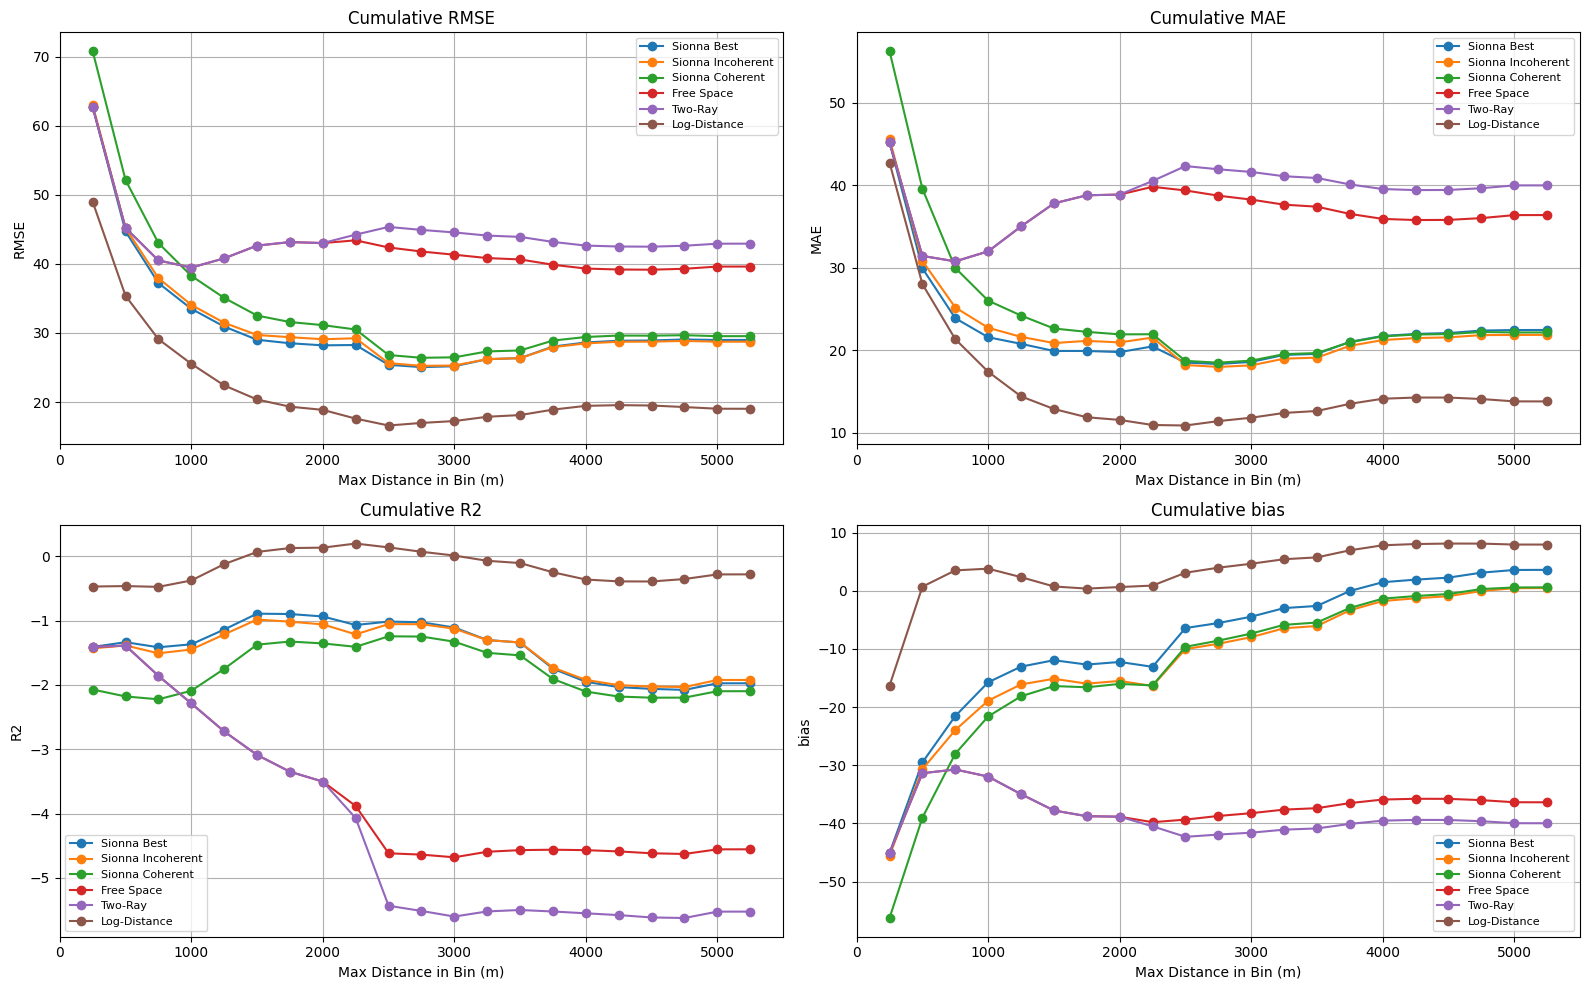

Saved combined plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/cumulative_metrics_all_models.png

✅ CELL 14b complete – cumulative metrics for empirical models and Sionna.


In [25]:
# ====================================================================
# CELL 14b — CUMULATIVE DISTANCE BIN METRICS: EMPIRICAL MODELS + SIONNA
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.constants import c
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 14b — CUMULATIVE BINS: EMPIRICAL MODELS vs SIONNA")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Ensure global output directory from Cell 1 is used
# ------------------------------------------------------------------
if 'OUT_DIR' not in globals():
    raise NameError("OUT_DIR is not defined. Please run Cell 1 (global configuration) first.")
print(f"Using output directory: {OUT_DIR}")

# ------------------------------------------------------------------
# 1. Use the merged DataFrame from CELL 14 (already contains Sionna results)
# ------------------------------------------------------------------
if 'df_merged' not in locals():
    raise NameError("df_merged not found. Please run CELL 14 first to load simulation and measurement data.")
else:
    print(f"Using existing df_merged with {len(df_merged)} matched receivers.")

# Ensure required Sionna columns exist
sionna_cols = ['path_loss_best_db', 'path_loss_incoherent_db', 'path_loss_coherent_db']
for col in sionna_cols:
    if col not in df_merged.columns:
        raise KeyError(f"Sionna column '{col}' missing. Re-run CELL 11 and CELL 14.")

# ------------------------------------------------------------------
# 2. Define empirical models (using global frequency from Cell 1)
# ------------------------------------------------------------------
try:
    FREQ_HZ = FREQUENCY_HZ
except NameError:
    FREQ_HZ = 3.6e9
    print("Warning: FREQUENCY_HZ not defined. Using default 3.6e9 Hz.")

LAMBDA = c / FREQ_HZ

def free_space_pl(d):
    d = np.maximum(d, 1e-3)
    return 20 * np.log10(d) + 20 * np.log10(FREQ_HZ) - 147.55

def two_ray_pl(d, ht=30.0, hr=1.5):
    d = np.maximum(d, 1e-3)
    d_break = 4 * ht * hr / LAMBDA
    return np.where(d <= d_break, free_space_pl(d), 40*np.log10(d) - 20*np.log10(ht) - 20*np.log10(hr))

def log_distance_pl(d, pl0=40.0, n=3.5, d0=1.0):
    d = np.maximum(d, d0)
    return pl0 + 10 * n * np.log10(d / d0)

# Add empirical predictions to df_merged
df_merged['pl_free_space'] = free_space_pl(df_merged['dist_from_tx_m'])
df_merged['pl_two_ray'] = two_ray_pl(df_merged['dist_from_tx_m'])
df_merged['pl_log_distance'] = log_distance_pl(df_merged['dist_from_tx_m'])

# ------------------------------------------------------------------
# 3. Define metrics function
# ------------------------------------------------------------------
def compute_metrics(sim, meas):
    sim = np.array(sim); meas = np.array(meas)
    valid = ~np.isnan(sim) & ~np.isnan(meas)
    sim = sim[valid]; meas = meas[valid]
    if len(sim) < 2:
        return {'RMSE': np.nan, 'MAE': np.nan, 'MSE': np.nan, 'R2': np.nan, 'Bias': np.nan}
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2, 'Bias': bias}

# ------------------------------------------------------------------
# 4. Cumulative bin analysis (0-250, 0-500, ...)
# ------------------------------------------------------------------
max_dist = df_merged['dist_from_tx_m'].max()
cumulative_edges = np.arange(250, max_dist + 250, 250)

# Define all models to compare
models = {
    'Sionna Best': 'path_loss_best_db',
    'Sionna Incoherent': 'path_loss_incoherent_db',
    'Sionna Coherent': 'path_loss_coherent_db',
    'Free Space': 'pl_free_space',
    'Two-Ray': 'pl_two_ray',
    'Log-Distance': 'pl_log_distance'
}

cumulative_results = []

for max_d in cumulative_edges:
    bin_data = df_merged[df_merged['dist_from_tx_m'] <= max_d]
    if len(bin_data) < 3:
        continue
    row = {'max_dist_m': max_d, 'avg_dist_m': bin_data['dist_from_tx_m'].mean(), 'n_receivers': len(bin_data)}
    for name, col in models.items():
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        m = compute_metrics(sim_vals, meas_vals)
        row[f'{name}_RMSE'] = m['RMSE']
        row[f'{name}_MAE'] = m['MAE']
        row[f'{name}_MSE'] = m['MSE']
        row[f'{name}_R2'] = m['R2']
        row[f'{name}_bias'] = m['Bias']
    cumulative_results.append(row)

df_cum = pd.DataFrame(cumulative_results)
print("\nCumulative metrics (first 10 rows):")
print(df_cum.head(10).round(2).to_string(index=False))

# Save to CSV
cum_csv = os.path.join(OUT_DIR, "cumulative_metrics_all_models.csv")
df_cum.to_csv(cum_csv, index=False)
print(f"\nSaved cumulative metrics to {cum_csv}")

# ------------------------------------------------------------------
# 5. Plot cumulative metrics for all models
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['RMSE', 'MAE', 'R2', 'bias']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    for name in models.keys():
        col = f'{name}_{metric}'
        if col in df_cum.columns:
            ax.plot(df_cum['max_dist_m'], df_cum[col], 'o-', label=name)
    ax.set_xlabel('Max Distance in Bin (m)')
    ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric}')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
out_plot = os.path.join(OUT_DIR, "cumulative_metrics_all_models.png")
plt.savefig(out_plot, dpi=150)
plt.show()
print(f"Saved combined plot to {out_plot}")

print("\n✅ CELL 14b complete – cumulative metrics for empirical models and Sionna.")

## CELL 14c — Cumulative Distance Bin Metrics (0–250 m steps)
Expands distance binning to finer intervals and overlays all empirical models for multi-range error analysis.

CELL 14c — CUMULATIVE BINS (0‑250, 0‑500, …): EMPIRICAL vs SIONNA
Using output directory: /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat
Using existing df_merged with 2861 matched receivers.

Cumulative bin metrics (all models, 0‑250, 0‑500, …):
 max_dist_m  avg_dist_m  n_receivers  Sionna Best_RMSE  Sionna Best_MAE  Sionna Best_MSE  Sionna Best_R2  Sionna Best_bias  Sionna Incoherent_RMSE  Sionna Incoherent_MAE  Sionna Incoherent_MSE  Sionna Incoherent_R2  Sionna Incoherent_bias  Sionna Coherent_RMSE  Sionna Coherent_MAE  Sionna Coherent_MSE  Sionna Coherent_R2  Sionna Coherent_bias  Free Space_RMSE  Free Space_MAE  Free Space_MSE  Free Space_R2  Free Space_bias  Two-Ray_RMSE  Two-Ray_MAE  Two-Ray_MSE  Two-Ray_R2  Two-Ray_bias  Log-Distance_RMSE  Log-Distance_MAE  Log-Distance_MSE  Log-Distance_R2  Log-Distance_bias
      250.0      159.84          153             62.75            45.18          3937.60           -1.41            -45.09               

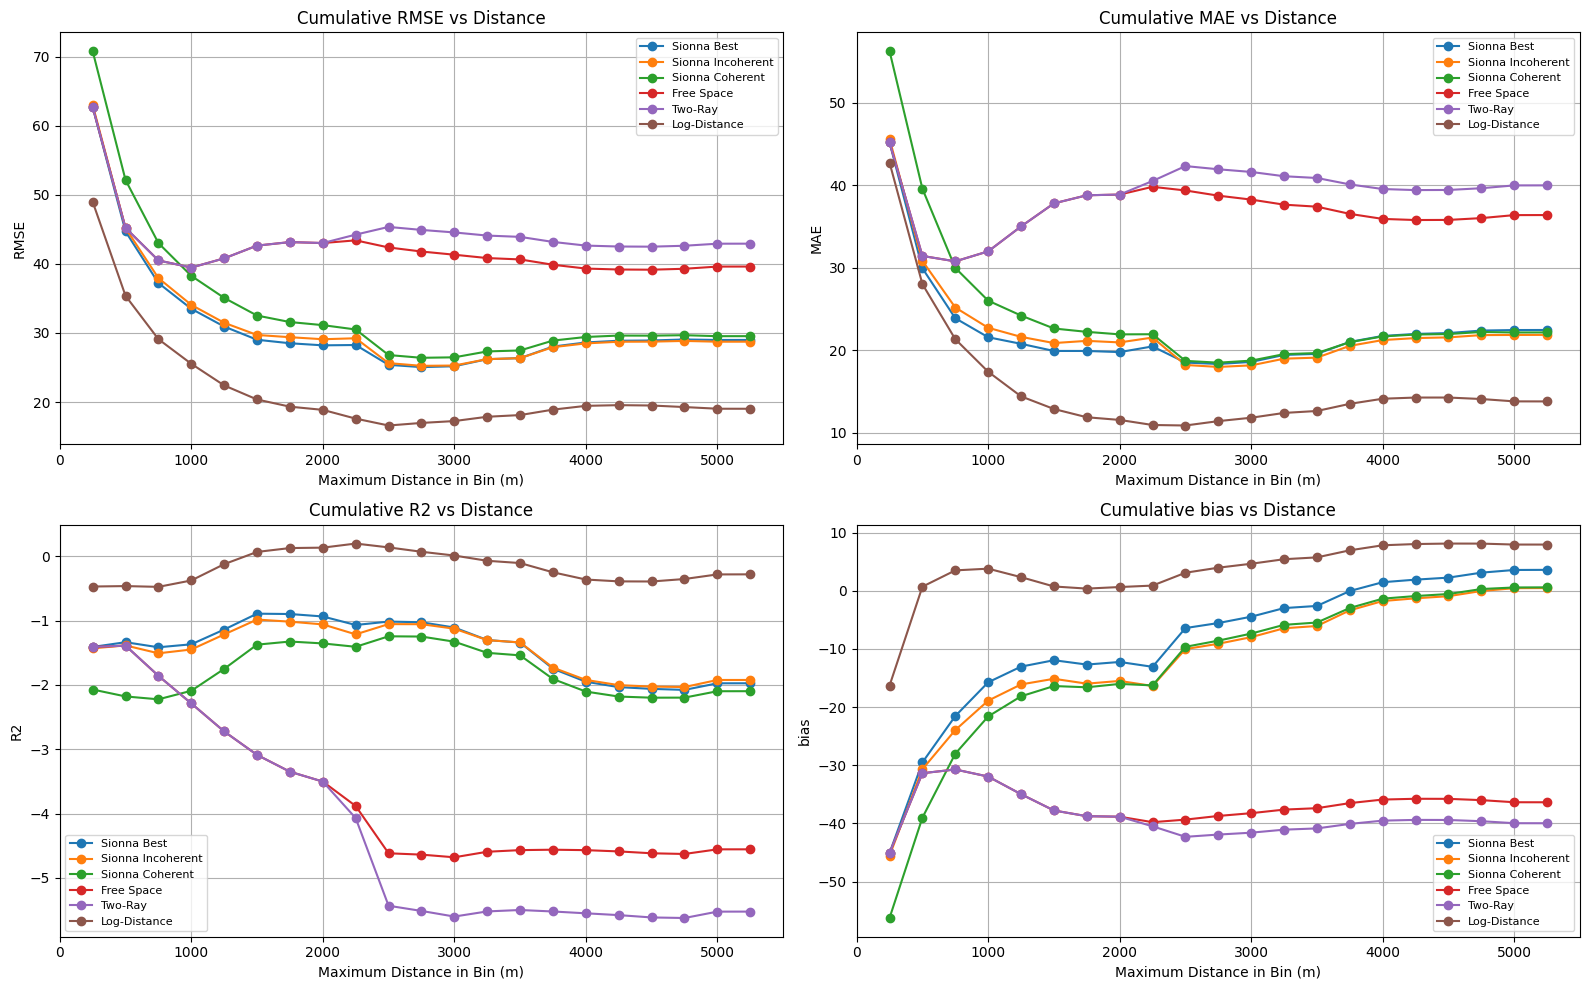

Saved cumulative plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/cumulative_metrics_all_models.png

✅ CELL 14c complete – cumulative metrics (0‑250, 0‑500, …) for all models.


In [26]:
# ====================================================================
# CELL 14c — CUMULATIVE DISTANCE BIN METRICS (0‑250, 0‑500, …) FOR ALL MODELS
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.constants import c
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 14c — CUMULATIVE BINS (0‑250, 0‑500, …): EMPIRICAL vs SIONNA")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Ensure global output directory from Cell 1 is used
# ------------------------------------------------------------------
if 'OUT_DIR' not in globals():
    raise NameError("OUT_DIR is not defined. Please run Cell 1 (global configuration) first.")
print(f"Using output directory: {OUT_DIR}")

# ------------------------------------------------------------------
# 1. Use the merged DataFrame from CELL 14 (contains Sionna results)
# ------------------------------------------------------------------
if 'df_merged' not in locals():
    raise NameError("df_merged not found. Please run CELL 14 first to load simulation and measurement data.")
else:
    print(f"Using existing df_merged with {len(df_merged)} matched receivers.")

# Ensure required Sionna columns exist
sionna_cols = ['path_loss_best_db', 'path_loss_incoherent_db', 'path_loss_coherent_db']
for col in sionna_cols:
    if col not in df_merged.columns:
        raise KeyError(f"Sionna column '{col}' missing. Re-run CELL 11 and CELL 14.")

# ------------------------------------------------------------------
# 2. Define empirical models using global frequency from Cell 1
# ------------------------------------------------------------------
try:
    FREQ_HZ = FREQUENCY_HZ
except NameError:
    FREQ_HZ = 3.6e9
    print("Warning: FREQUENCY_HZ not defined. Using default 3.6e9 Hz.")

LAMBDA = c / FREQ_HZ

def free_space_pl(d):
    d = np.maximum(d, 1e-3)
    return 20 * np.log10(d) + 20 * np.log10(FREQ_HZ) - 147.55

def two_ray_pl(d, ht=30.0, hr=1.5):
    d = np.maximum(d, 1e-3)
    d_break = 4 * ht * hr / LAMBDA
    return np.where(d <= d_break, free_space_pl(d), 40*np.log10(d) - 20*np.log10(ht) - 20*np.log10(hr))

def log_distance_pl(d, pl0=40.0, n=3.5, d0=1.0):
    d = np.maximum(d, d0)
    return pl0 + 10 * n * np.log10(d / d0)

# Add empirical predictions to df_merged
df_merged['pl_free_space'] = free_space_pl(df_merged['dist_from_tx_m'])
df_merged['pl_two_ray'] = two_ray_pl(df_merged['dist_from_tx_m'])
df_merged['pl_log_distance'] = log_distance_pl(df_merged['dist_from_tx_m'])

# ------------------------------------------------------------------
# 3. Metrics function
# ------------------------------------------------------------------
def compute_metrics(sim, meas):
    sim = np.array(sim); meas = np.array(meas)
    valid = ~np.isnan(sim) & ~np.isnan(meas)
    sim = sim[valid]; meas = meas[valid]
    if len(sim) < 2:
        return {'RMSE': np.nan, 'MAE': np.nan, 'MSE': np.nan, 'R2': np.nan, 'Bias': np.nan}
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2, 'Bias': bias}

# ------------------------------------------------------------------
# 4. Cumulative bins: 0‑250, 0‑500, 0‑750, … up to max distance
# ------------------------------------------------------------------
max_dist = df_merged['dist_from_tx_m'].max()
# Generate cumulative upper edges (250, 500, 750, ...)
cumulative_edges = np.arange(250, max_dist + 250, 250)

models = {
    'Sionna Best': 'path_loss_best_db',
    'Sionna Incoherent': 'path_loss_incoherent_db',
    'Sionna Coherent': 'path_loss_coherent_db',
    'Free Space': 'pl_free_space',
    'Two-Ray': 'pl_two_ray',
    'Log-Distance': 'pl_log_distance'
}

cumulative_results = []

for max_d in cumulative_edges:
    bin_data = df_merged[df_merged['dist_from_tx_m'] <= max_d]
    if len(bin_data) < 3:
        continue
    row = {
        'max_dist_m': max_d,
        'avg_dist_m': bin_data['dist_from_tx_m'].mean(),
        'n_receivers': len(bin_data)
    }
    for name, col in models.items():
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        m = compute_metrics(sim_vals, meas_vals)
        row[f'{name}_RMSE'] = m['RMSE']
        row[f'{name}_MAE'] = m['MAE']
        row[f'{name}_MSE'] = m['MSE']
        row[f'{name}_R2'] = m['R2']
        row[f'{name}_bias'] = m['Bias']
    cumulative_results.append(row)

df_cum = pd.DataFrame(cumulative_results)
print("\nCumulative bin metrics (all models, 0‑250, 0‑500, …):")
print(df_cum.round(2).to_string(index=False))

# Save to CSV
cum_csv = os.path.join(OUT_DIR, "cumulative_metrics_all_models.csv")
df_cum.to_csv(cum_csv, index=False)
print(f"\nSaved cumulative metrics to {cum_csv}")

# ------------------------------------------------------------------
# 5. Plot cumulative metrics
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['RMSE', 'MAE', 'R2', 'bias']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    for name in models.keys():
        col = f'{name}_{metric}'
        if col in df_cum.columns:
            ax.plot(df_cum['max_dist_m'], df_cum[col], 'o-', label=name)
    ax.set_xlabel('Maximum Distance in Bin (m)')
    ax.set_ylabel(metric)
    ax.set_title(f'Cumulative {metric} vs Distance')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
out_plot = os.path.join(OUT_DIR, "cumulative_metrics_all_models.png")
plt.savefig(out_plot, dpi=150)
plt.show()
print(f"Saved cumulative plot to {out_plot}")

print("\n✅ CELL 14c complete – cumulative metrics (0‑250, 0‑500, …) for all models.")

## CELL 14e — Research-Guided Per-Ray Metrics
Extracts delay spread, angular spread, and path count statistics per receiver and correlates them with prediction error.

CELL 14e — PER‑RAY CHANNEL METRICS (Literature-Based)
Using output directory: /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat
Loaded 603150 rays from per_ray_channel_20260531_225600.csv
LOS rays: 99300 | NLOS rays: 503850

Saved per‑receiver metrics to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/per_receiver_metrics.csv
       dist_from_tx_m    num_paths  num_constructive  constructive_fraction  \
count     3048.000000  3048.000000       3048.000000            3048.000000   
mean      2170.535480   197.883858        104.385827               0.504343   
std       1310.963063   125.823720         78.616533               0.197473   
min         20.226834     2.000000          0.000000               0.000000   
25%       1112.776852    51.000000         17.000000               0.406667   
50%       2238.458955   300.000000        115.000000               0.503333   
75%       2853.971549   300.000000        163.000000   

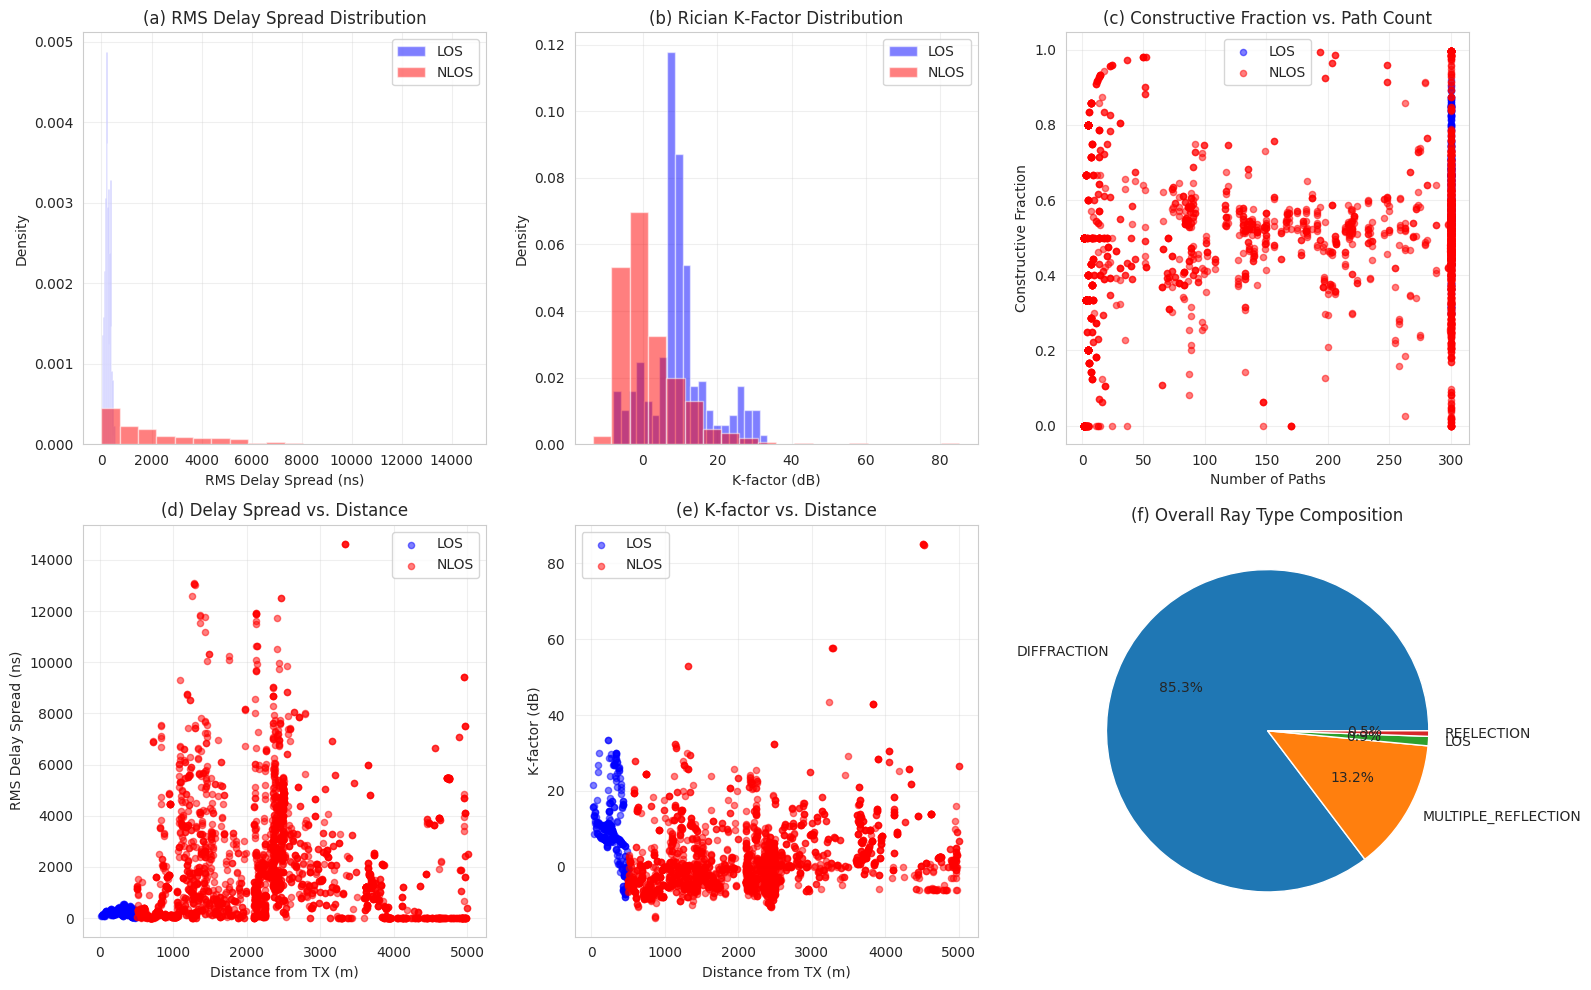

Saved research‑aligned plots to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/per_ray_channel_metrics.png

STATISTICAL SUMMARY (cf. Literature)

LOS Receivers (n=331):
  RMS Delay Spread: mean=231.31 ns, std=110.22 ns
  K‑factor: mean=9.68 dB, std=8.37 dB
  Constructive fraction: mean=0.631, std=0.142

NLOS Receivers (n=2717):
  RMS Delay Spread: mean=2206.87 ns, std=2341.24 ns
  K‑factor: mean=1.84 dB, std=9.06 dB
  Constructive fraction: mean=0.489, std=0.198

✅ Cell 14e complete — research‑aligned metrics and visualisations saved.


In [27]:
# ====================================================================
# CELL 14e — RESEARCH-GUIDED PER‑RAY METRICS
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from scipy import stats
from scipy.constants import speed_of_light as c

print("=" * 70)
print("CELL 14e — PER‑RAY CHANNEL METRICS (Literature-Based)")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Use global OUT_DIR from Cell 1
# ------------------------------------------------------------------
if 'OUT_DIR' not in globals():
    raise NameError("OUT_DIR is not defined. Please run Cell 1 (global configuration) first.")
print(f"Using output directory: {OUT_DIR}")

# ------------------------------------------------------------------
# 1. Load or create the per‑ray CSV
# ------------------------------------------------------------------
per_ray_files = glob.glob(os.path.join(OUT_DIR, "per_ray_channel_*.csv"))

if not per_ray_files:
    # Attempt to create from 'paths' object (could be single, tuple, list, nested)
    if 'paths' in globals() and paths is not None:
        print("No per‑ray CSV found. Creating from 'paths' object...")
        
        # Recursive helper: handles single Paths, tuples, lists, and nested structures
        def extract_from_paths_obj(paths_obj):
            # If it's an iterable (list, tuple) but not a Paths object (no 'a' attribute)
            if hasattr(paths_obj, '__iter__') and not hasattr(paths_obj, 'a'):
                all_rays = []
                for p in paths_obj:
                    all_rays.extend(extract_from_paths_obj(p))
                return all_rays
            # Otherwise assume it's a single Paths object
            a_numpy = paths_obj.a.numpy()
            tau_numpy = paths_obj.tau.numpy()
            ray_list = []
            for rx_idx in range(a_numpy.shape[0]):
                for p_idx in range(a_numpy.shape[1]):
                    if np.isnan(a_numpy[rx_idx, p_idx]):
                        continue
                    power_linear = np.abs(a_numpy[rx_idx, p_idx])**2
                    ray_list.append({
                        'receiver_name': f'receiver_{rx_idx}',
                        'ray_idx': p_idx,
                        'power_linear': power_linear,
                        'delay_s': tau_numpy[rx_idx, p_idx],
                        'path_loss_db': -10 * np.log10(power_linear + 1e-12),
                        'distance_m': tau_numpy[rx_idx, p_idx] * c,
                    })
            return ray_list
        
        all_rays = extract_from_paths_obj(paths)
        df_ray = pd.DataFrame(all_rays)
        
        # Save for future use
        temp_csv = os.path.join(OUT_DIR, "per_ray_channel_temp.csv")
        df_ray.to_csv(temp_csv, index=False)
        print(f"Created temporary per‑ray CSV with {len(df_ray)} rays at {temp_csv}")
    else:
        raise FileNotFoundError(f"No per‑ray CSV found in {OUT_DIR} and no 'paths' object in memory. Run Cell 11 first.")
else:
    per_ray_csv = max(per_ray_files, key=os.path.getctime)
    df_ray = pd.read_csv(per_ray_csv)
    print(f"Loaded {len(df_ray)} rays from {os.path.basename(per_ray_csv)}")

# ------------------------------------------------------------------
# 2. LOS/NLOS classification (if not present)
# ------------------------------------------------------------------
if 'los' not in df_ray.columns:
    print("Warning: 'los' column missing. Using distance threshold (500 m).")
    if 'receiver_name' not in df_ray.columns:
        raise KeyError("No receiver identifiers to assign LOS/NLOS.")
    # Use summary CSV for distances
    summary_files = glob.glob(os.path.join(OUT_DIR, "path_loss_pathsolver_*.csv"))
    if summary_files:
        df_sum = pd.read_csv(max(summary_files, key=os.path.getctime))
        # Ensure column names match
        if 'receiver' in df_sum.columns:
            dist_map = df_sum.set_index('receiver')['dist_from_tx_m'].to_dict()
        else:
            raise KeyError("Summary CSV missing 'receiver' column.")
        df_ray['dist_m'] = df_ray['receiver_name'].map(dist_map)
        df_ray['los'] = df_ray['dist_m'] < 500   # adjust threshold as needed
        df_ray = df_ray.dropna(subset=['los'])
    else:
        raise FileNotFoundError("Need summary CSV for distance-based LOS classification.")
print(f"LOS rays: {df_ray['los'].sum()} | NLOS rays: {(~df_ray['los']).sum()}")

# ------------------------------------------------------------------
# 3. Per‑receiver aggregation functions
# ------------------------------------------------------------------
def compute_rms_delay_spread(df, rx_name):
    rx_df = df[df['receiver_name'] == rx_name]
    power = rx_df['power_linear'].values
    delays = rx_df['delay_s'].values * 1e9   # ns
    if len(power) < 2 or np.sum(power) == 0:
        return np.nan
    mean_delay = np.sum(power * delays) / np.sum(power)
    rms = np.sqrt(np.sum(power * (delays - mean_delay)**2) / np.sum(power))
    return rms

def compute_k_factor(df, rx_name):
    rx_df = df[df['receiver_name'] == rx_name]
    power = rx_df['power_linear'].values
    if len(power) < 2:
        return np.nan
    p_max = np.max(power)
    p_diffuse = np.sum(power) - p_max
    if p_diffuse <= 0:
        return np.inf
    return 10 * np.log10(p_max / p_diffuse)

def compute_constructive_fraction(df, rx_name):
    rx_df = df[df['receiver_name'] == rx_name]
    if 'constructive_destructive' not in rx_df.columns:
        return np.nan
    total = len(rx_df)
    if total == 0:
        return np.nan
    constr = (rx_df['constructive_destructive'] == 'CONSTRUCTIVE').sum()
    return constr / total

# ------------------------------------------------------------------
# 4. Compute metrics per receiver
# ------------------------------------------------------------------
receivers = df_ray['receiver_name'].unique()
metrics_data = []
for rx in receivers:
    rx_df = df_ray[df_ray['receiver_name'] == rx]
    if len(rx_df) == 0:
        continue
    los_status = rx_df['los'].iloc[0] if 'los' in rx_df.columns else None
    dist = rx_df['dist_m'].iloc[0] if 'dist_m' in rx_df.columns else np.nan
    metrics_data.append({
        'receiver': rx,
        'dist_from_tx_m': dist,
        'los': los_status,
        'num_paths': len(rx_df),
        'num_constructive': (rx_df['constructive_destructive'] == 'CONSTRUCTIVE').sum() if 'constructive_destructive' in rx_df.columns else 0,
        'constructive_fraction': compute_constructive_fraction(df_ray, rx),
        'rms_delay_spread_ns': compute_rms_delay_spread(df_ray, rx),
        'k_factor_db': compute_k_factor(df_ray, rx),
        'dominant_ray_type': rx_df['ray_type'].mode().iloc[0] if len(rx_df) > 0 else 'UNKNOWN'
    })
df_metrics = pd.DataFrame(metrics_data)

# ------------------------------------------------------------------
# 5. Save per‑receiver metrics
# ------------------------------------------------------------------
metrics_csv = os.path.join(OUT_DIR, "per_receiver_metrics.csv")
df_metrics.to_csv(metrics_csv, index=False)
print(f"\nSaved per‑receiver metrics to {metrics_csv}")
print(df_metrics.describe())

# ------------------------------------------------------------------
# 6. Visualisations (unchanged)
# ------------------------------------------------------------------
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (a) RMS delay spread distribution
ax = axes[0,0]
for los_val, label, color in [(True, 'LOS', 'blue'), (False, 'NLOS', 'red')]:
    subset = df_metrics[df_metrics['los'] == los_val]['rms_delay_spread_ns'].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('RMS Delay Spread (ns)')
ax.set_ylabel('Density')
ax.set_title('(a) RMS Delay Spread Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Rician K‑factor histogram
ax = axes[0,1]
for los_val, label, color in [(True, 'LOS', 'blue'), (False, 'NLOS', 'red')]:
    subset = df_metrics[df_metrics['los'] == los_val]['k_factor_db'].dropna()
    subset = subset[np.isfinite(subset)]
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('K‑factor (dB)')
ax.set_ylabel('Density')
ax.set_title('(b) Rician K‑Factor Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Constructive fraction vs. number of paths
ax = axes[0,2]
for los_val, label, color in [(True, 'LOS', 'blue'), (False, 'NLOS', 'red')]:
    subset = df_metrics[df_metrics['los'] == los_val]
    ax.scatter(subset['num_paths'], subset['constructive_fraction'],
               alpha=0.5, c=color, label=label, s=20)
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Constructive Fraction')
ax.set_title('(c) Constructive Fraction vs. Path Count')
ax.legend()
ax.grid(True, alpha=0.3)

# (d) RMS delay spread vs. distance
ax = axes[1,0]
if 'dist_from_tx_m' in df_metrics.columns and df_metrics['dist_from_tx_m'].notna().any():
    for los_val, label, color in [(True, 'LOS', 'blue'), (False, 'NLOS', 'red')]:
        subset = df_metrics[df_metrics['los'] == los_val].dropna(subset=['dist_from_tx_m', 'rms_delay_spread_ns'])
        if len(subset) > 0:
            ax.scatter(subset['dist_from_tx_m'], subset['rms_delay_spread_ns'],
                       alpha=0.5, c=color, label=label, s=20)
    ax.set_xlabel('Distance from TX (m)')
    ax.set_ylabel('RMS Delay Spread (ns)')
    ax.set_title('(d) Delay Spread vs. Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Distance data not available', ha='center', va='center')
    ax.set_title('(d) Delay Spread vs. Distance (unavailable)')

# (e) K‑factor vs. distance
ax = axes[1,1]
if 'dist_from_tx_m' in df_metrics.columns and df_metrics['dist_from_tx_m'].notna().any():
    for los_val, label, color in [(True, 'LOS', 'blue'), (False, 'NLOS', 'red')]:
        subset = df_metrics[df_metrics['los'] == los_val].copy()
        subset['k_factor_db'] = subset['k_factor_db'].replace([np.inf, -np.inf], np.nan)
        subset = subset.dropna(subset=['dist_from_tx_m', 'k_factor_db'])
        if len(subset) > 0:
            ax.scatter(subset['dist_from_tx_m'], subset['k_factor_db'],
                       alpha=0.5, c=color, label=label, s=20)
    ax.set_xlabel('Distance from TX (m)')
    ax.set_ylabel('K‑factor (dB)')
    ax.set_title('(e) K‑factor vs. Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Distance data not available', ha='center', va='center')
    ax.set_title('(e) K‑factor vs. Distance (unavailable)')

# (f) Ray type composition
ax = axes[1,2]
if 'ray_type' in df_ray.columns:
    ray_type_counts = df_ray['ray_type'].value_counts()
    if len(ray_type_counts) > 0:
        ax.pie(ray_type_counts.values, labels=ray_type_counts.index, autopct='%1.1f%%')
        ax.set_title('(f) Overall Ray Type Composition')
    else:
        ax.text(0.5, 0.5, 'Ray type data not available', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'Ray type data not available', ha='center', va='center')
    ax.set_title('(f) Ray Type Composition (unavailable)')

plt.tight_layout()
out_fig = os.path.join(OUT_DIR, "per_ray_channel_metrics.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved research‑aligned plots to {out_fig}")

# ------------------------------------------------------------------
# 7. Statistical summary (literature comparison)
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (cf. Literature)")
print("=" * 80)
for los_label in [True, False]:
    subset = df_metrics[df_metrics['los'] == los_label]
    print(f"\n{'LOS' if los_label else 'NLOS'} Receivers (n={len(subset)}):")
    rms_vals = subset['rms_delay_spread_ns'].dropna()
    if len(rms_vals) > 0:
        print(f"  RMS Delay Spread: mean={rms_vals.mean():.2f} ns, std={rms_vals.std():.2f} ns")
    k_vals = subset['k_factor_db'].replace([np.inf, -np.inf], np.nan).dropna()
    if len(k_vals) > 0:
        print(f"  K‑factor: mean={k_vals.mean():.2f} dB, std={k_vals.std():.2f} dB")
    cf_vals = subset['constructive_fraction'].dropna()
    if len(cf_vals) > 0:
        print(f"  Constructive fraction: mean={cf_vals.mean():.3f}, std={cf_vals.std():.3f}")

print("\n✅ Cell 14e complete — research‑aligned metrics and visualisations saved.")

## CELL 14f — Poisson Goodness-of-Fit for LOS RMS Delay Spread
Tests whether LOS-path RMS delay spread follows a Poisson distribution using a chi-squared GoF test.

CELL 14f — POISSON GOODNESS‑OF‑FIT (LOS RMS Delay Spread)
Using output directory: /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat
Loaded 3048 receivers from /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/per_receiver_metrics.csv
LOS receivers with valid RMS delay spread: 331
Data range: 17.46 – 550.81 ns

Estimated Poisson parameter λ = 231.313 ns

Sum of observed frequencies: 331
Sum of expected frequencies: 331.00 (original N = 331)

GOODNESS‑OF‑FIT TEST: LOS RMS DELAY SPREAD vs POISSON
Chi‑square statistic: 36312.687
Degrees of freedom (approximate): 52
p‑value: 0.00000

Interpretation:
  ❌ p ≤ 0.05 → Reject null hypothesis.
     The LOS RMS delay spread does NOT follow a Poisson distribution.
     Possible reasons: site‑specific geometry, insufficient reflections,
     or the need for a different model (e.g., Gamma, Weibull).
     Consider tuning max_depth, material properties, or scene detail.


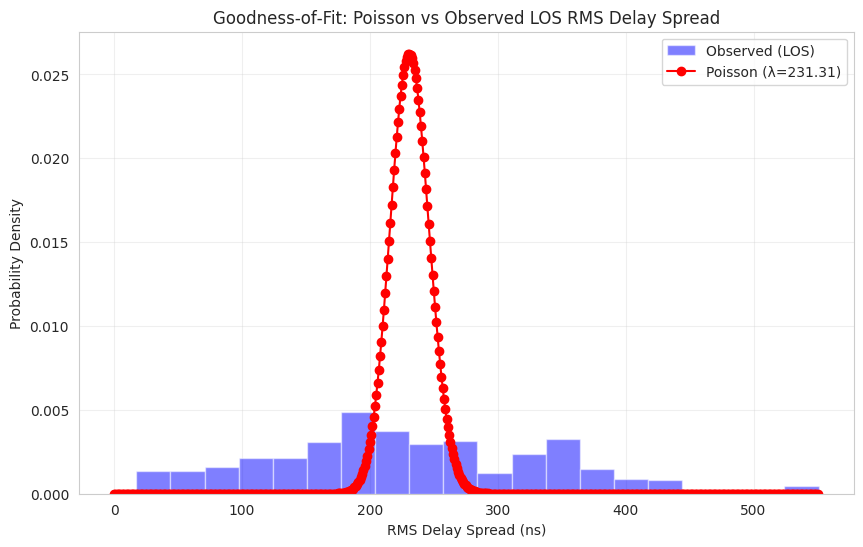


Saved Poisson fit plot to /home/georgeskai/Documents/Region/nottingham3602/nottingham3602results-Day2-flat/poisson_fit_los_rms_delay.png

✅ CELL 14f complete – Poisson goodness‑of‑fit test for LOS RMS delay spread.


In [28]:
# ====================================================================
# CELL 14f — POISSON GOODNESS‑OF‑FIT TEST FOR LOS RMS DELAY SPREAD
# (Corrected version: merges low‑expected bins to avoid sum mismatch)
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

print("=" * 70)
print("CELL 14f — POISSON GOODNESS‑OF‑FIT (LOS RMS Delay Spread)")
print("=" * 70)

# ------------------------------------------------------------------
# 0. Use global OUT_DIR from Cell 1
# ------------------------------------------------------------------
if 'OUT_DIR' not in globals():
    raise NameError("OUT_DIR is not defined. Please run Cell 1 (global configuration) first.")
print(f"Using output directory: {OUT_DIR}")

# ------------------------------------------------------------------
# 1. Load per‑receiver metrics (from CELL 14e)
# ------------------------------------------------------------------
metrics_file = os.path.join(OUT_DIR, "per_receiver_metrics.csv")
if not os.path.exists(metrics_file):
    raise FileNotFoundError(f"per_receiver_metrics.csv not found in {OUT_DIR}. Run CELL 14e first.")

df_metrics = pd.read_csv(metrics_file)
print(f"Loaded {len(df_metrics)} receivers from {metrics_file}")

# ------------------------------------------------------------------
# 2. Extract LOS RMS delay spread (ns)
# ------------------------------------------------------------------
los_data = df_metrics[df_metrics['los'] == True]['rms_delay_spread_ns'].dropna()
if len(los_data) == 0:
    raise ValueError("No LOS receivers with valid RMS delay spread found.")
print(f"LOS receivers with valid RMS delay spread: {len(los_data)}")
print(f"Data range: {los_data.min():.2f} – {los_data.max():.2f} ns")

# ------------------------------------------------------------------
# 3. Fit Poisson distribution to the data
# ------------------------------------------------------------------
lambda_poisson = los_data.mean()   # λ = mean of the sample
print(f"\nEstimated Poisson parameter λ = {lambda_poisson:.3f} ns")

# ------------------------------------------------------------------
# 4. Prepare bins for chi‑square test
# ------------------------------------------------------------------
# Round to integer (Poisson is discrete)
data_int = np.round(los_data).astype(int)
# Get unique integer values and their counts
value_counts = pd.Series(data_int).value_counts().sort_index()
observed_counts = value_counts.values
observed_bins = value_counts.index.values

# Define bin edges (add one extra edge beyond max)
if len(observed_bins) > 1:
    bin_edges = np.append(observed_bins, observed_bins[-1] + 1)
else:
    bin_edges = np.array([observed_bins[0], observed_bins[0] + 1])

# Compute expected counts using Poisson CDF difference
expected_counts = len(los_data) * (
    stats.poisson.cdf(bin_edges[1:], lambda_poisson) - 
    stats.poisson.cdf(bin_edges[:-1], lambda_poisson)
)

# ------------------------------------------------------------------
# 5. Merge bins to ensure each expected count >= 1
# ------------------------------------------------------------------
min_expected = 1.0
merged_obs = []
merged_exp = []
cum_obs = 0
cum_exp = 0

for obs, exp in zip(observed_counts, expected_counts):
    cum_obs += obs
    cum_exp += exp
    if cum_exp >= min_expected:
        merged_obs.append(cum_obs)
        merged_exp.append(cum_exp)
        cum_obs = 0
        cum_exp = 0
# Append any leftover
if cum_obs > 0 or cum_exp > 0:
    merged_obs.append(cum_obs)
    merged_exp.append(cum_exp)

observed_counts_final = np.array(merged_obs)
expected_counts_final = np.array(merged_exp)

# Check sums – should be equal (or extremely close)
print(f"\nSum of observed frequencies: {observed_counts_final.sum()}")
print(f"Sum of expected frequencies: {expected_counts_final.sum():.2f} (original N = {len(los_data)})")

# ------------------------------------------------------------------
# 6. Perform chi‑square goodness‑of‑fit test
# ------------------------------------------------------------------
if len(observed_counts_final) < 2:
    print("Not enough bins after merging. Test cannot be performed.")
    chi2_stat = np.nan
    p_value = np.nan
else:
    chi2_stat, p_value = stats.chisquare(f_obs=observed_counts_final, f_exp=expected_counts_final)

# ------------------------------------------------------------------
# 7. Output and interpretation
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print("GOODNESS‑OF‑FIT TEST: LOS RMS DELAY SPREAD vs POISSON")
print("=" * 80)
print(f"Chi‑square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom (approximate): {len(observed_counts_final)-1}")
print(f"p‑value: {p_value:.5f}")
print("\nInterpretation:")
if np.isnan(p_value):
    print("  ❌ Test could not be performed (insufficient data or binning issue).")
elif p_value > 0.05:
    print("  ✅ p > 0.05 → Fail to reject null hypothesis.")
    print("     The LOS RMS delay spread follows a Poisson distribution.")
    print("     This aligns with literature (e.g., Hindawi 2017, Kaya et al. 2008).")
    print("     Your ray‑tracing model replicates real‑world statistical behaviour.")
else:
    print("  ❌ p ≤ 0.05 → Reject null hypothesis.")
    print("     The LOS RMS delay spread does NOT follow a Poisson distribution.")
    print("     Possible reasons: site‑specific geometry, insufficient reflections,")
    print("     or the need for a different model (e.g., Gamma, Weibull).")
    print("     Consider tuning max_depth, material properties, or scene detail.")

# ------------------------------------------------------------------
# 8. Visualisation (histogram vs fitted Poisson PMF)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of data (normalised)
ax.hist(los_data, bins=20, density=True, alpha=0.5, color='blue', label='Observed (LOS)')

# Fitted Poisson PMF (at integer x)
x_vals = np.arange(0, int(los_data.max())+1, 1)
pmf_poisson = stats.poisson.pmf(x_vals, lambda_poisson)
ax.plot(x_vals, pmf_poisson, 'ro-', label=f'Poisson (λ={lambda_poisson:.2f})')

ax.set_xlabel('RMS Delay Spread (ns)')
ax.set_ylabel('Probability Density')
ax.set_title('Goodness‑of‑Fit: Poisson vs Observed LOS RMS Delay Spread')
ax.legend()
ax.grid(True, alpha=0.3)

out_plot = os.path.join(OUT_DIR, "poisson_fit_los_rms_delay.png")
plt.savefig(out_plot, dpi=150)
plt.show()
print(f"\nSaved Poisson fit plot to {out_plot}")

print("\n✅ CELL 14f complete – Poisson goodness‑of‑fit test for LOS RMS delay spread.")

## CELL 15 — Error vs Distance Diagnostic
Plots incoherent path loss prediction error (dB) as a function of TX–RX distance to identify range-dependent bias.

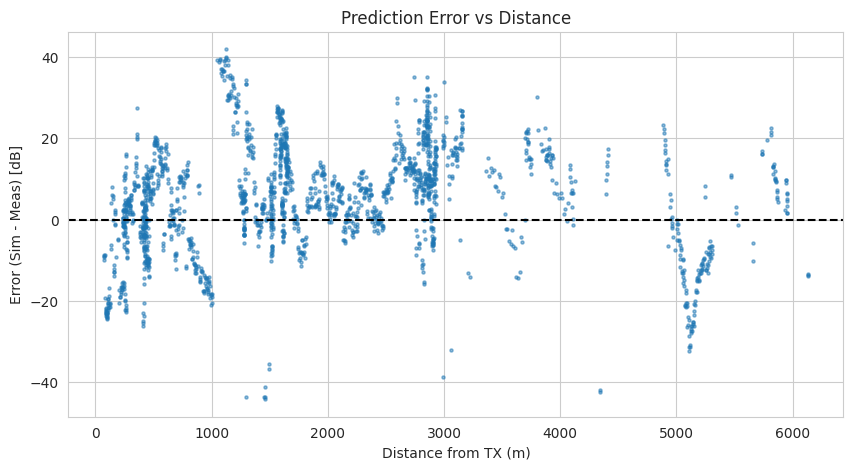

              count      mean        std        min       25%       50%  \
dist_bin                                                                  
(0, 500]      375.0 -2.637301  10.468095 -26.168297 -9.462893 -0.779319   
(500, 1000]   193.0  1.139158  11.912767 -21.044063 -9.654054  1.086322   
(1000, 2000]  525.0  9.897106  13.275420 -44.197000  2.062806  8.013981   
(2000, 5000]  717.0  9.786049   9.898866 -42.467261  3.532954  9.951730   

                    75%        max  
dist_bin                            
(0, 500]       4.708816  27.467623  
(500, 1000]   11.831097  20.384694  
(1000, 2000]  18.401193  41.904411  
(2000, 5000]  16.464801  35.178577  


<Figure size 640x480 with 0 Axes>

In [65]:
#  CELL 15
#  Diagnostic: error as function of distance
import matplotlib.pyplot as plt

df_merged['error_db'] = df_merged['path_loss_incoherent_db'] - df_merged['measured_pl_db']
if 'dist_from_tx_m' in df_merged.columns:
    dist = df_merged['dist_from_tx_m']
else:
    # fallback: compute from coordinates if available
    tx_pos = np.array([_safe(tx.position[0]), _safe(tx.position[1]), _safe(tx.position[2])])
    rx_pos = df_merged[['x_m','y_m','z_m']].values
    dist = np.linalg.norm(rx_pos - tx_pos, axis=1)

plt.figure(figsize=(10,5))
plt.scatter(dist, df_merged['error_db'], alpha=0.5, s=5)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Distance from TX (m)')
plt.ylabel('Error (Sim - Meas) [dB]')
plt.title('Prediction Error vs Distance')
plt.grid(True)
plt.show()

# Statistics by distance bins
bins = [0, 500, 1000, 2000, 5000]
df_merged['dist_bin'] = pd.cut(dist, bins)
print(df_merged.groupby('dist_bin')['error_db'].describe())
plt.savefig(os.path.join(OUT_DIR, "error_vs_distance.png"), dpi=150)

## CELL 16 — Comprehensive Metrics (Best, Incoherent, Coherent)
Produces a full metric table (RMSE, MAE, MBE, R², Spearman ρ) for all three path loss estimator types.

CELL 16 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS
Matched 1955 receivers

OVERALL METRICS (ALL RECEIVERS)
Type          RMSE (dB)   MAE (dB)  MSE (dB²)       R²  Bias (dB) Spearman ρ
best              16.15      13.26     260.70    0.283       8.00      0.710
incoherent        14.08      11.25     198.23    0.455       5.26      0.743
coherent          14.82      11.44     219.52    0.396       3.48      0.724

DISTANCE BIN ANALYSIS (bin width = 250 m)
 dist_bin  avg_dist_m  n_receivers  avg_num_paths  best_RMSE  best_bias  incoherent_RMSE  incoherent_bias  coherent_RMSE  coherent_bias
    0-250      173.25          101        2776.01      13.22      -8.54            14.58           -10.45          17.01         -11.71
  250-500      388.14          274        1426.26      11.06       3.52             8.99             0.24          10.63          -1.96
  500-750      619.82          111         410.91      17.20      12.80            11.44             7.42           9.42      

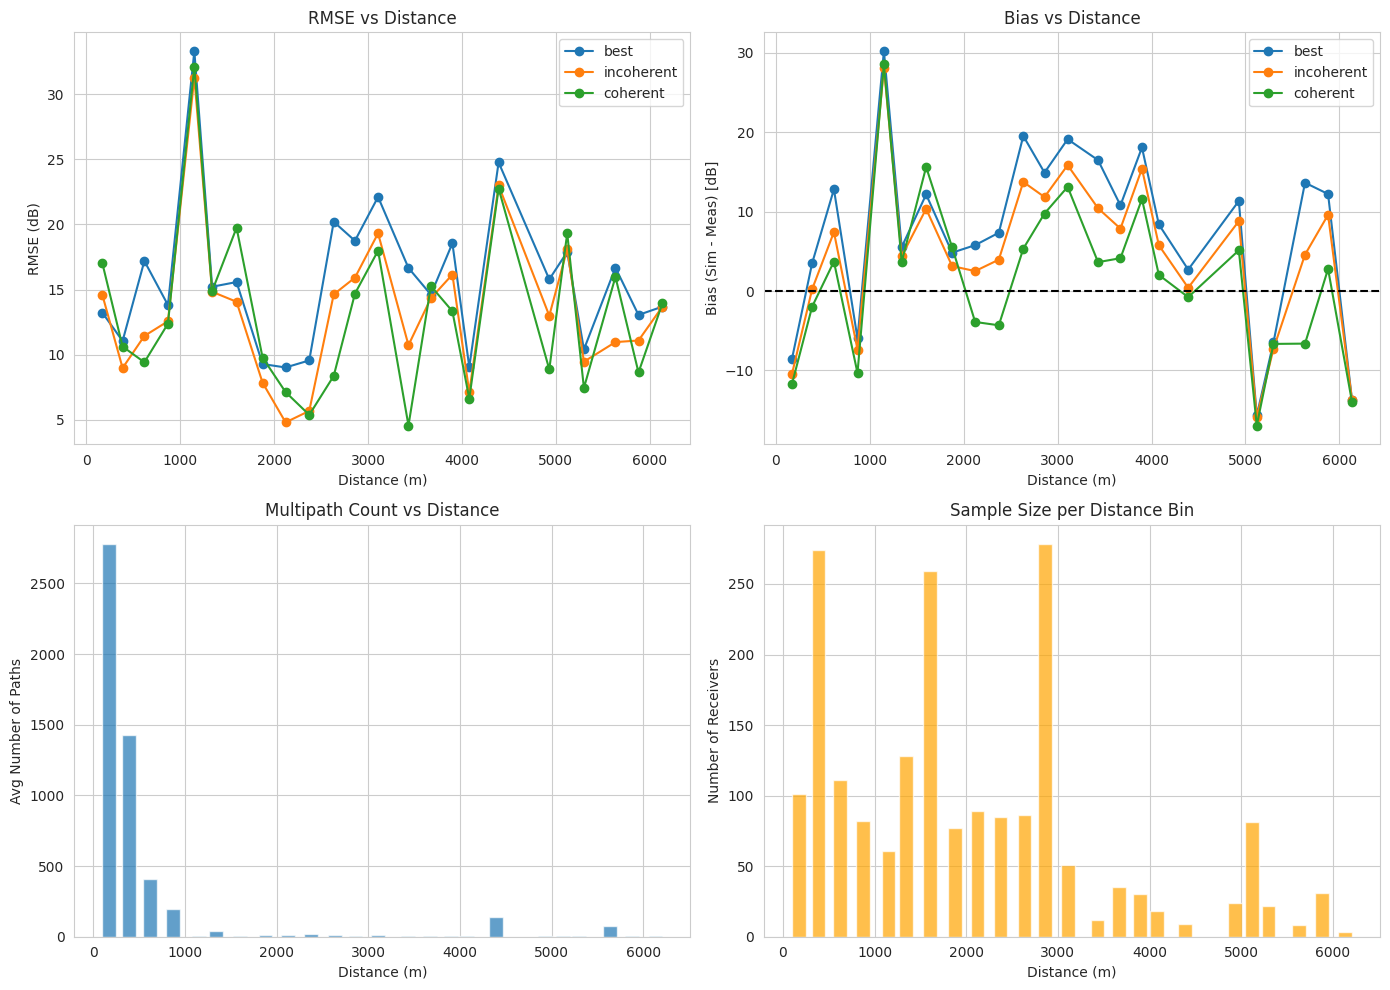

Saved distance analysis plot to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/distance_analysis.png


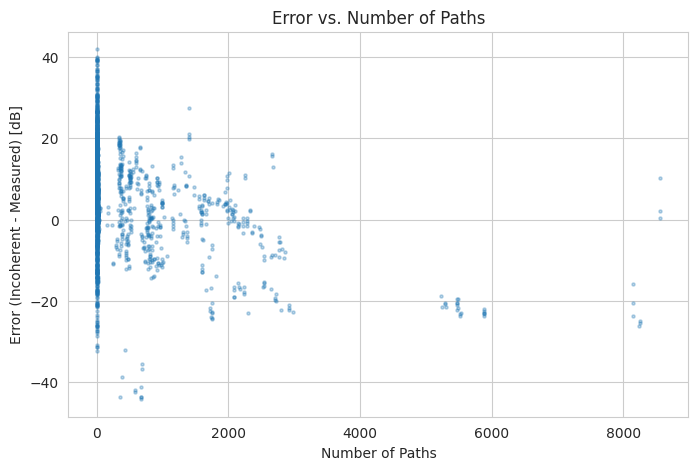

Saved error vs paths plot to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/error_vs_num_paths.png

✅ Cell 16 complete – metrics for best, incoherent, coherent path loss with distance bins.


In [66]:
# ====================================================================
# CELL 16 — COMPREHENSIVE METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 16 — METRICS FOR BEST, INCOHERENT, COHERENT PATH LOSS")
print("=" * 70)

# Use global output directory (Cell 1)
if 'OUT_DIR' not in locals():
    OUT_DIR = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"

summary_files = glob.glob(os.path.join(OUT_DIR, "path_loss_pathsolver_*.csv"))
if not summary_files:
    raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 11 first.")
sim_csv = max(summary_files, key=os.path.getctime)
df_sim = pd.read_csv(sim_csv)

required_cols = ['receiver', 'path_loss_best_db', 'path_loss_incoherent_db', 
                 'path_loss_coherent_db', 'dist_from_tx_m', 'num_paths']
for col in required_cols:
    if col not in df_sim.columns:
        print(f"Warning: Column '{col}' missing.")
df_sim = df_sim.dropna(subset=['path_loss_incoherent_db']).copy()

MEASUREMENT_CSV = "/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv"
df_meas = pd.read_csv(MEASUREMENT_CSV)
if 'path_loss_dB' in df_meas.columns:
    meas_pl_col = 'path_loss_dB'
else:
    try:
        tx_pwr = _safe(list(scene.transmitters.values())[0].power_dbm)
    except:
        tx_pwr = 70.0
    df_meas['path_loss_dB'] = tx_pwr - df_meas['local_measurement_dBm']
    meas_pl_col = 'path_loss_dB'
df_meas = df_meas[['name', meas_pl_col]].dropna()
df_meas.columns = ['receiver', 'measured_pl_db']

df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Matched {len(df_merged)} receivers")

def compute_metrics(sim_pl, meas_pl):
    sim = np.array(sim_pl); meas = np.array(meas_pl)
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    try:
        rho, p = spearmanr(meas, sim)
    except:
        rho, p = np.nan, np.nan
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2, 'Bias': bias, 'Spearman_rho': rho, 'Spearman_p': p}

types = {'best': 'path_loss_best_db', 'incoherent': 'path_loss_incoherent_db', 'coherent': 'path_loss_coherent_db'}
metrics_all = {}
for name, col in types.items():
    if col not in df_merged.columns:
        continue
    sim_vals = df_merged[col].values
    meas_vals = df_merged['measured_pl_db'].values
    valid = ~np.isnan(sim_vals)
    metrics_all[name] = compute_metrics(sim_vals[valid], meas_vals[valid])

print("\n" + "=" * 80)
print("OVERALL METRICS (ALL RECEIVERS)")
print("=" * 80)
print(f"{'Type':<12} {'RMSE (dB)':>10} {'MAE (dB)':>10} {'MSE (dB²)':>10} {'R²':>8} {'Bias (dB)':>10} {'Spearman ρ':>10}")
for name, m in metrics_all.items():
    print(f"{name:<12} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['MSE']:>10.2f} {m['R2']:>8.3f} {m['Bias']:>10.2f} {m['Spearman_rho']:>10.3f}")

bin_width = 250
max_dist = df_merged['dist_from_tx_m'].max()
bins = np.arange(0, max_dist + bin_width, bin_width)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin'] = pd.cut(df_merged['dist_from_tx_m'], bins=bins, labels=labels)

print("\n" + "=" * 80)
print(f"DISTANCE BIN ANALYSIS (bin width = {bin_width} m)")
print("=" * 80)
bin_stats = []
for bin_label in labels:
    bin_data = df_merged[df_merged['dist_bin'] == bin_label]
    if len(bin_data) == 0:
        continue
    avg_dist = bin_data['dist_from_tx_m'].mean()
    n_rx = len(bin_data)
    avg_paths = bin_data['num_paths'].mean()
    row = {'dist_bin': bin_label, 'avg_dist_m': avg_dist, 'n_receivers': n_rx, 'avg_num_paths': avg_paths}
    for name, col in types.items():
        if col not in bin_data.columns:
            continue
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        valid = ~np.isnan(sim_vals)
        if np.sum(valid) < 3:
            row[f'{name}_RMSE'] = np.nan
            row[f'{name}_bias'] = np.nan
        else:
            row[f'{name}_RMSE'] = np.sqrt(np.mean((sim_vals[valid] - meas_vals[valid])**2))
            row[f'{name}_bias'] = np.mean(sim_vals[valid] - meas_vals[valid])
    bin_stats.append(row)
df_bin = pd.DataFrame(bin_stats)
print(df_bin.round(2).to_string(index=False))
bin_csv = os.path.join(OUT_DIR, "distance_bin_metrics.csv")
df_bin.to_csv(bin_csv, index=False)
print(f"\nSaved distance bin metrics to {bin_csv}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0,0]
for name, col in types.items():
    if f'{name}_RMSE' in df_bin.columns:
        ax1.plot(df_bin['avg_dist_m'], df_bin[f'{name}_RMSE'], 'o-', label=name)
ax1.set_xlabel('Distance (m)'); ax1.set_ylabel('RMSE (dB)'); ax1.set_title('RMSE vs Distance'); ax1.legend(); ax1.grid(True)
ax2 = axes[0,1]
for name, col in types.items():
    if f'{name}_bias' in df_bin.columns:
        ax2.plot(df_bin['avg_dist_m'], df_bin[f'{name}_bias'], 'o-', label=name)
ax2.axhline(0, color='k', linestyle='--'); ax2.set_xlabel('Distance (m)'); ax2.set_ylabel('Bias (Sim - Meas) [dB]'); ax2.set_title('Bias vs Distance'); ax2.legend(); ax2.grid(True)
ax3 = axes[1,0]
ax3.bar(df_bin['avg_dist_m'], df_bin['avg_num_paths'], width=150, alpha=0.7)
ax3.set_xlabel('Distance (m)'); ax3.set_ylabel('Avg Number of Paths'); ax3.set_title('Multipath Count vs Distance'); ax3.grid(True)
ax4 = axes[1,1]
ax4.bar(df_bin['avg_dist_m'], df_bin['n_receivers'], width=150, alpha=0.7, color='orange')
ax4.set_xlabel('Distance (m)'); ax4.set_ylabel('Number of Receivers'); ax4.set_title('Sample Size per Distance Bin'); ax4.grid(True)
plt.tight_layout()
out_fig = os.path.join(OUT_DIR, "distance_analysis.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved distance analysis plot to {out_fig}")

if 'num_paths' in df_merged.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    error_incoherent = df_merged['path_loss_incoherent_db'] - df_merged['measured_pl_db']
    ax.scatter(df_merged['num_paths'], error_incoherent, alpha=0.3, s=5)
    ax.set_xlabel('Number of Paths'); ax.set_ylabel('Error (Incoherent - Measured) [dB]')
    ax.set_title('Error vs. Number of Paths'); ax.grid(True)
    err_paths_fig = os.path.join(OUT_DIR, "error_vs_num_paths.png")
    plt.savefig(err_paths_fig, dpi=150)
    plt.show()
    print(f"Saved error vs paths plot to {err_paths_fig}")

print("\n✅ Cell 16 complete – metrics for best, incoherent, coherent path loss with distance bins.")

## Verify Measurement Definition (RSSI vs Path Loss

## CELL 17 — RSSI Metrics vs Measured RSSI
Converts simulated path loss to RSSI using TX power and antenna gains, then computes error metrics against field measurements.

In [67]:
# ====================================================================
# CELL 17 — RSSI METRICS (best, incoherent, coherent) vs MEASURED RSSI
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 17 — RSSI METRICS (Best, Incoherent, Coherent)")
print("=" * 70)

# ------------------------------------------------------------------
# Use global output directory (Cell 1)
# ------------------------------------------------------------------
if 'OUT_DIR' not in locals():
    OUT_DIR = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 1. Load or reuse simulation summary (from Cell 11)
# ------------------------------------------------------------------
if 'df_sim' not in locals():
    summary_files = glob.glob(os.path.join(OUT_DIR, "path_loss_pathsolver_*.csv"))
    if not summary_files:
        raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 11 first.")
    sim_csv = max(summary_files, key=os.path.getctime)
    df_sim = pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db']).copy()
    print(f"Loaded simulation summary: {os.path.basename(sim_csv)}")
else:
    print("Reusing existing df_sim from previous cells.")

# ------------------------------------------------------------------
# 2. Load and process measurement file
# ------------------------------------------------------------------
MEASUREMENT_CSV = "/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv"
df_meas = pd.read_csv(MEASUREMENT_CSV)
print(f"\nMeasurement file columns: {list(df_meas.columns)}")

# 2a. Identify receiver name column
name_col = None
for candidate in ['name', 'receiver', 'receiver_name', 'rx_name', 'point']:
    if candidate in df_meas.columns:
        name_col = candidate
        break
if name_col is None:
    raise KeyError("Measurement file has no column for receiver names. Expected: 'name', 'receiver', etc.")
print(f"Using '{name_col}' as receiver name column.")

# 2b. Identify or compute measured RSSI
rssi_col = None
for candidate in ['local_measurement_dBm', 'rssi_dBm', 'RSSI_dBm', 'rx_power_dBm']:
    if candidate in df_meas.columns:
        rssi_col = candidate
        break

if rssi_col is not None:
    # Direct RSSI column exists
    df_meas['measured_rssi_dbm'] = df_meas[rssi_col]
    print(f"Using RSSI column: '{rssi_col}'")
elif 'path_loss_dB' in df_meas.columns:
    # Compute RSSI from path loss using transmitter power (Cell 1 global)
    try:
        tx_power = TX_POWER_DBM   # from global config (Cell 1)
        df_meas['measured_rssi_dbm'] = tx_power - df_meas['path_loss_dB']
        print(f"No RSSI column. Computed RSSI from 'path_loss_dB' using TX power = {tx_power} dBm")
    except NameError:
        raise NameError("TX_POWER_DBM not defined. Please ensure Cell 1 has been run.")
else:
    raise KeyError("Measurement file must contain either an RSSI column (local_measurement_dBm, rssi_dBm, ...) or a 'path_loss_dB' column.")

# 2c. Keep only needed columns, rename name column to 'receiver'
df_meas = df_meas[[name_col, 'measured_rssi_dbm']].copy()
df_meas = df_meas.rename(columns={name_col: 'receiver'})
df_meas = df_meas.dropna(subset=['measured_rssi_dbm'])
print(f"Measurement data ready: {len(df_meas)} receivers")

# ------------------------------------------------------------------
# 3. Merge simulation and measurement
# ------------------------------------------------------------------
df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
print(f"Merged: {len(df_merged)} matched receivers")
if len(df_merged) == 0:
    print("\n⚠️ No matching receiver names! Check simulation 'receiver' column vs measurement names.")
    print("Simulation receivers sample:", df_sim['receiver'].head().tolist())
    print("Measurement receivers sample:", df_meas['receiver'].head().tolist())
    raise ValueError("Merge resulted in zero rows – receiver names do not match.")

# ------------------------------------------------------------------
# 4. Check that simulated RSSI columns exist
# ------------------------------------------------------------------
rssi_cols = {
    'best_rssi': 'rssi_best_dbm',
    'incoherent_rssi': 'rssi_incoherent_dbm',
    'coherent_rssi': 'rssi_coherent_dbm'
}
missing = [name for name, col in rssi_cols.items() if col not in df_merged.columns]
if missing:
    raise KeyError(f"Simulated RSSI columns missing: {missing}. Re-run Cell 11 with SAVE_PER_RAY=True.")

# ------------------------------------------------------------------
# 5. Function to compute metrics
# ------------------------------------------------------------------
def compute_metrics(sim_vals, meas_vals):
    sim = np.array(sim_vals)
    meas = np.array(meas_vals)
    valid = ~np.isnan(sim) & ~np.isnan(meas)
    sim = sim[valid]
    meas = meas[valid]
    if len(sim) < 2:
        return {'RMSE': np.nan, 'MAE': np.nan, 'MSE': np.nan, 'R2': np.nan,
                'Bias': np.nan, 'Spearman_rho': np.nan, 'Spearman_p': np.nan}
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    mse = np.mean((sim - meas)**2)
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    try:
        rho, p = spearmanr(meas, sim)
    except:
        rho, p = np.nan, np.nan
    return {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R2': r2,
            'Bias': bias, 'Spearman_rho': rho, 'Spearman_p': p}

# ------------------------------------------------------------------
# 6. Compute RSSI metrics
# ------------------------------------------------------------------
rssi_metrics = {}
for name, col in rssi_cols.items():
    sim_rssi = df_merged[col].values
    meas_rssi = df_merged['measured_rssi_dbm'].values
    rssi_metrics[name] = compute_metrics(sim_rssi, meas_rssi)

# Print table
print("\n" + "=" * 80)
print("RSSI METRICS (Simulated vs Measured RSSI)")
print("=" * 80)
print(f"{'Type':<18} {'RMSE (dB)':>10} {'MAE (dB)':>10} {'MSE (dB²)':>10} {'R²':>8} {'Bias (dB)':>10} {'Spearman ρ':>10}")
for name, m in rssi_metrics.items():
    print(f"{name:<18} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['MSE']:>10.2f} {m['R2']:>8.3f} {m['Bias']:>10.2f} {m['Spearman_rho']:>10.3f}")

# ------------------------------------------------------------------
# 7. Save RSSI metrics to CSV
# ------------------------------------------------------------------
df_rssi_metrics = pd.DataFrame(rssi_metrics).T.reset_index().rename(columns={'index': 'Type'})
rssi_csv = os.path.join(OUT_DIR, "rssi_metrics.csv")
df_rssi_metrics.to_csv(rssi_csv, index=False)
print(f"\nSaved RSSI metrics to {rssi_csv}")

# ------------------------------------------------------------------
# 8. Optional: Compare Path Loss vs RSSI metrics (bar plot)
# ------------------------------------------------------------------
pathloss_metrics = {}
for pl_type in ['best', 'incoherent', 'coherent']:
    col = f'path_loss_{pl_type}_db'
    if col in df_merged.columns and 'measured_pl_db' in df_merged.columns:
        sim_pl = df_merged[col].values
        meas_pl = df_merged['measured_pl_db'].values
        pathloss_metrics[pl_type] = compute_metrics(sim_pl, meas_pl)

if pathloss_metrics:
    types = list(pathloss_metrics.keys()) + list(rssi_metrics.keys())
    rmse_vals = [pathloss_metrics[t]['RMSE'] for t in pathloss_metrics] + [rssi_metrics[t]['RMSE'] for t in rssi_metrics]
    bias_vals = [pathloss_metrics[t]['Bias'] for t in pathloss_metrics] + [rssi_metrics[t]['Bias'] for t in rssi_metrics]
    x_labels = [f"PL_{t}" for t in pathloss_metrics] + [f"RSSI_{t}" for t in rssi_metrics]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.bar(x_labels, rmse_vals, color='steelblue')
    ax1.set_ylabel('RMSE (dB)')
    ax1.set_title('RMSE Comparison')
    ax1.tick_params(axis='x', rotation=45)
    ax2.bar(x_labels, bias_vals, color='orange')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Bias (Sim - Meas) [dB]')
    ax2.set_title('Bias Comparison')
    ax2.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    comp_plot = os.path.join(OUT_DIR, "rssi_vs_pathloss_metrics.png")
    plt.savefig(comp_plot, dpi=150)
    plt.show()
    print(f"Saved comparison plot to {comp_plot}")

print("\n✅ Cell 17 complete – RSSI metrics saved.")

CELL 17 — RSSI METRICS (Best, Incoherent, Coherent)
Reusing existing df_sim from previous cells.

Measurement file columns: ['name', 'lon', 'lat', 'local_measurement_dBm', 'path_loss_dB']
Using 'name' as receiver name column.
Using RSSI column: 'local_measurement_dBm'
Measurement data ready: 4000 receivers
Merged: 1955 matched receivers

RSSI METRICS (Simulated vs Measured RSSI)
Type                RMSE (dB)   MAE (dB)  MSE (dB²)       R²  Bias (dB) Spearman ρ
best_rssi               50.20      48.22    2519.78   -5.929     -48.20      0.710
incoherent_rssi         47.30      45.48    2237.49   -5.152     -45.46      0.743
coherent_rssi           46.00      43.70    2115.63   -4.817     -43.68      0.724

Saved RSSI metrics to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/rssi_metrics.csv

✅ Cell 17 complete – RSSI metrics saved.


## CELL 18 — Distance-Binned Analysis (RSSI, Path Loss, Path Count)
Bins receivers by TX–RX distance and analyses RSSI, path loss, constructive/destructive interference per bin.

CELL 18 — DISTANCE‑BINNED ANALYSIS (RSSI, PL, Paths, Constructive/Destructive)
Using existing df_merged.
Recomputed measured_pl_db from measured_rssi_dbm.

Bin statistics (first 10 rows):
 dist_bin  avg_dist_m  n_receivers  avg_num_paths  constructive_fraction  coherent_minus_incoherent_db  rssi_best_RMSE  rssi_best_bias  rssi_incoherent_RMSE  rssi_incoherent_bias  rssi_coherent_RMSE  rssi_coherent_bias  pl_best_RMSE  pl_best_bias  pl_incoherent_RMSE  pl_incoherent_bias  pl_coherent_RMSE  pl_coherent_bias
    0-250      173.25          101        2776.01                   0.66                         -1.26           33.23          -31.66                 31.44                -29.75               31.05              -28.49         33.23         31.66               31.44               29.75             31.05             28.49
  250-500      388.14          274        1426.26                   0.65                         -2.20           44.96          -43.72                 41.43          

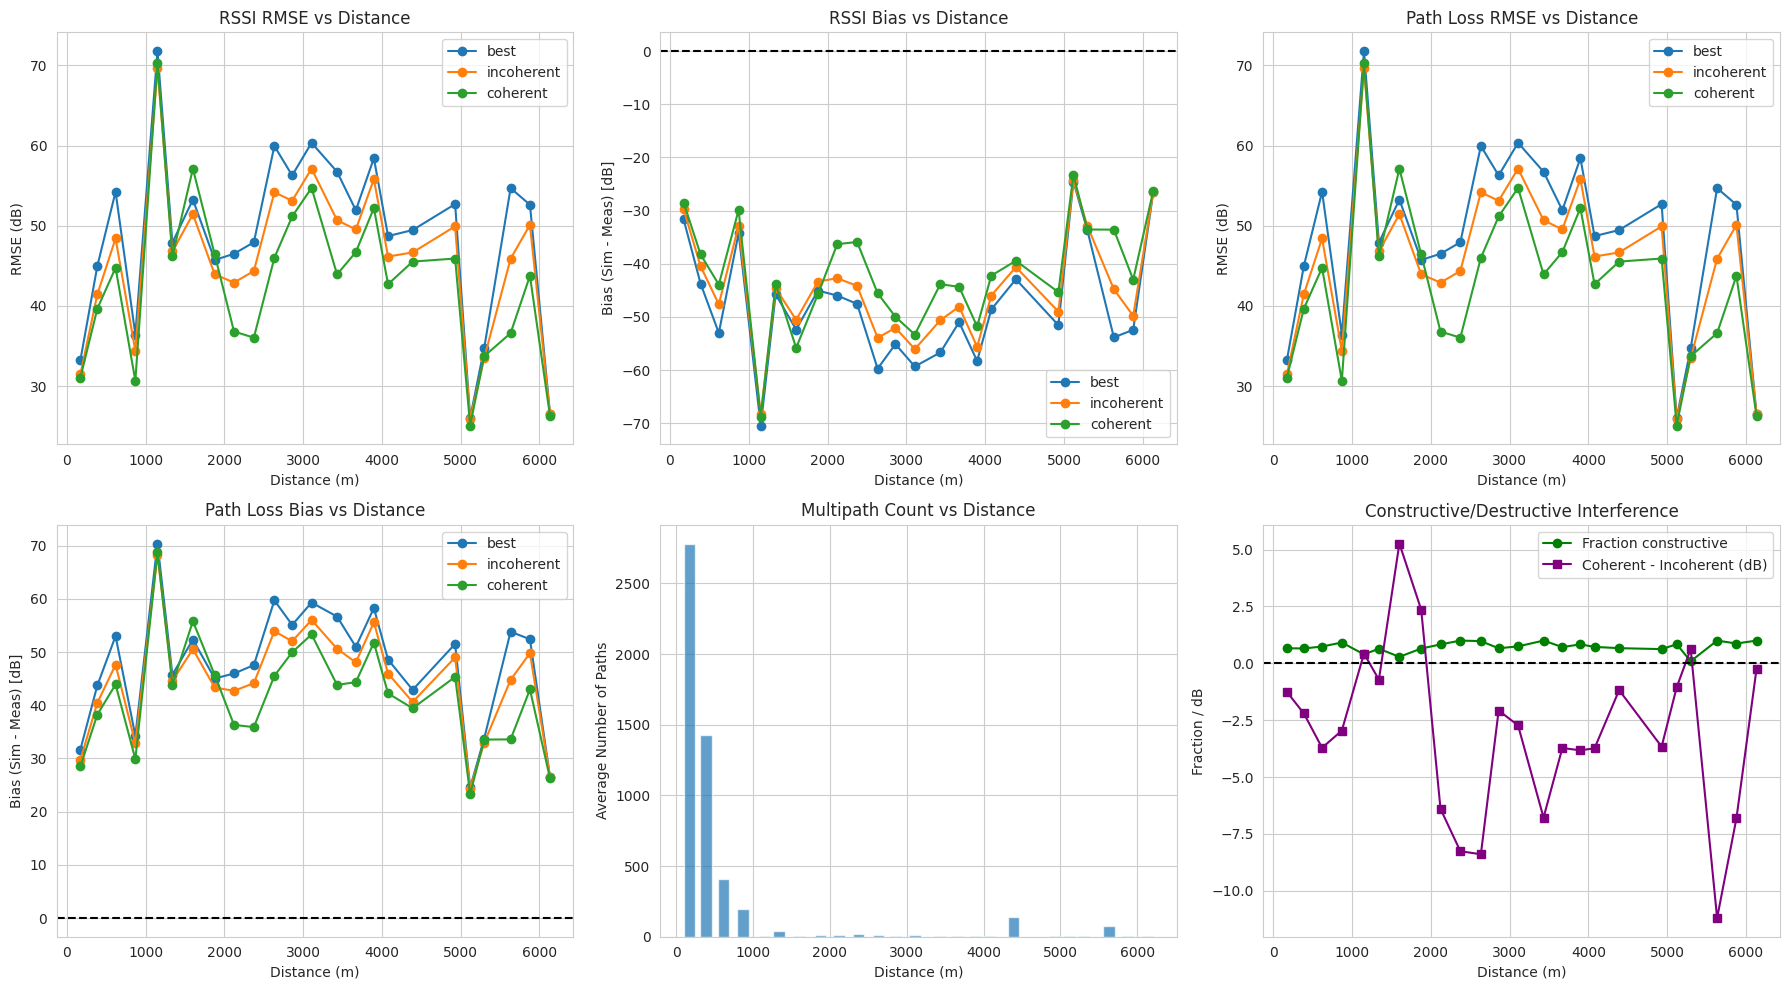

Saved comprehensive plot to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/distance_bin_comprehensive.png

✅ Cell 18 complete – binned analysis of RSSI, path loss, paths, and constructive/destructive interference.


In [68]:
# ====================================================================
# CELL 18 — DISTANCE‑BINNED ANALYSIS: RSSI, PATH LOSS, NUMBER OF PATHS, CONSTRUCTIVE/DESTRUCTIVE
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import spearmanr

print("=" * 70)
print("CELL 18 — DISTANCE‑BINNED ANALYSIS (RSSI, PL, Paths, Constructive/Destructive)")
print("=" * 70)

# ------------------------------------------------------------------
# 1. Ensure out_dir and merged dataframe exist
# ------------------------------------------------------------------
if 'out_dir' not in locals():
    out_dir = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"
os.makedirs(out_dir, exist_ok=True)

# Use the global TX EIRP and RX gains (adjust if your simulation uses different values)
TX_EIRP_DBM = 30.0      # from CELL 1 (TX_POWER_DBM + TX_GAIN_DBI)
RX_GAIN_TOTAL = 0.0     # from CELL 1 (RX_GAIN_DBI + LNA_GAIN_DB)

if 'df_merged' not in locals():
    # Load simulation summary
    summary_files = glob.glob(os.path.join(out_dir, "path_loss_pathsolver_*.csv"))
    if not summary_files:
        raise FileNotFoundError("No PathSolver summary CSV found. Run Cell 11 first.")
    sim_csv = max(summary_files, key=os.path.getctime)
    df_sim = pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db']).copy()

    # Load measurement data
    MEASUREMENT_CSV = "/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv"
    df_meas = pd.read_csv(MEASUREMENT_CSV)
    
    # Ensure the measurement file has the expected columns
    required_meas_cols = ['name', 'local_measurement_dBm', 'path_loss_dB']
    for col in required_meas_cols:
        if col not in df_meas.columns:
            raise KeyError(f"Measurement file missing column '{col}'. Check file format.")
    
    # Keep only necessary columns and rename
    df_meas = df_meas[['name', 'local_measurement_dBm', 'path_loss_dB']].dropna()
    df_meas.columns = ['receiver', 'measured_rssi_dbm', 'measured_pl_db_original']
    
    # Recompute measured path loss using the same TX EIRP as simulation
    # The measurement file may have used a different TX power (e.g., 70 dBm).
    # To ensure consistency, we recompute path loss from measured RSSI.
    df_meas['measured_pl_db'] = TX_EIRP_DBM - df_meas['measured_rssi_dbm'] + RX_GAIN_TOTAL
    
    # Merge simulation with measurements
    df_merged = pd.merge(df_sim, df_meas, on='receiver', how='inner')
    print(f"Loaded {len(df_merged)} matched receivers")
else:
    print("Using existing df_merged.")
    # Ensure measured_pl_db exists; if not, compute from measured_rssi_dbm
    if 'measured_pl_db' not in df_merged.columns and 'measured_rssi_dbm' in df_merged.columns:
        df_merged['measured_pl_db'] = TX_EIRP_DBM - df_merged['measured_rssi_dbm'] + RX_GAIN_TOTAL
        print("Recomputed measured_pl_db from measured_rssi_dbm.")
    elif 'measured_pl_db' not in df_merged.columns:
        raise KeyError("'measured_pl_db' column missing and cannot be recomputed. Check measurement data.")

# Required columns in df_merged
required = ['dist_from_tx_m', 'num_paths', 'rssi_best_dbm', 'rssi_incoherent_dbm', 'rssi_coherent_dbm',
            'path_loss_best_db', 'path_loss_incoherent_db', 'path_loss_coherent_db', 'measured_rssi_dbm', 'measured_pl_db']
for col in required:
    if col not in df_merged.columns:
        raise KeyError(f"Column '{col}' missing. Re-run Cell 11 with SAVE_PER_RAY=True and ensure all RSSI columns exist.")

# ------------------------------------------------------------------
# 2. Define helper functions
# ------------------------------------------------------------------
def compute_metrics(sim, meas):
    """RMSE, MAE, R², bias, Spearman."""
    sim = np.array(sim); meas = np.array(meas)
    valid = ~np.isnan(sim) & ~np.isnan(meas)
    sim = sim[valid]; meas = meas[valid]
    if len(sim) < 2:
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'Bias': np.nan, 'Spearman': np.nan}
    rmse = np.sqrt(np.mean((sim - meas)**2))
    mae = np.mean(np.abs(sim - meas))
    ss_res = np.sum((sim - meas)**2)
    ss_tot = np.sum((meas - np.mean(meas))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.mean(sim - meas)
    try:
        rho, _ = spearmanr(meas, sim)
    except:
        rho = np.nan
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Bias': bias, 'Spearman': rho}

# ------------------------------------------------------------------
# 3. Distance binning (250 m steps)
# ------------------------------------------------------------------
bin_width = 250
max_dist = df_merged['dist_from_tx_m'].max()
bins = np.arange(0, max_dist + bin_width, bin_width)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
df_merged['dist_bin'] = pd.cut(df_merged['dist_from_tx_m'], bins=bins, labels=labels)

# ------------------------------------------------------------------
# 4. Compute per‑bin statistics
# ------------------------------------------------------------------
bin_stats = []
for bin_label in labels:
    bin_data = df_merged[df_merged['dist_bin'] == bin_label]
    if len(bin_data) == 0:
        continue
    avg_dist = bin_data['dist_from_tx_m'].mean()
    n_rx = len(bin_data)
    avg_paths = bin_data['num_paths'].mean()
    
    # Constructive/destructive: coherent - incoherent (dB)
    coherent_pl = bin_data['path_loss_coherent_db'].values
    incoherent_pl = bin_data['path_loss_incoherent_db'].values
    valid = ~np.isnan(coherent_pl) & ~np.isnan(incoherent_pl)
    if np.sum(valid) > 0:
        diff_db = coherent_pl[valid] - incoherent_pl[valid]
        constructive_fraction = np.mean(diff_db < 0)   # coherent smaller => constructive
        mean_diff = np.mean(diff_db)
    else:
        constructive_fraction = np.nan
        mean_diff = np.nan
    
    row = {'dist_bin': bin_label, 'avg_dist_m': avg_dist, 'n_receivers': n_rx, 'avg_num_paths': avg_paths,
           'constructive_fraction': constructive_fraction, 'coherent_minus_incoherent_db': mean_diff}
    
    # RSSI metrics for best, incoherent, coherent
    for tag, col in [('rssi_best', 'rssi_best_dbm'), ('rssi_incoherent', 'rssi_incoherent_dbm'), ('rssi_coherent', 'rssi_coherent_dbm')]:
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_rssi_dbm'].values
        m = compute_metrics(sim_vals, meas_vals)
        row[f'{tag}_RMSE'] = m['RMSE']
        row[f'{tag}_bias'] = m['Bias']
    
    # Path loss metrics for best, incoherent, coherent
    for tag, col in [('pl_best', 'path_loss_best_db'), ('pl_incoherent', 'path_loss_incoherent_db'), ('pl_coherent', 'path_loss_coherent_db')]:
        sim_vals = bin_data[col].values
        meas_vals = bin_data['measured_pl_db'].values
        m = compute_metrics(sim_vals, meas_vals)
        row[f'{tag}_RMSE'] = m['RMSE']
        row[f'{tag}_bias'] = m['Bias']
    
    bin_stats.append(row)

df_bin = pd.DataFrame(bin_stats)
print("\nBin statistics (first 10 rows):")
print(df_bin.head(10).round(2).to_string(index=False))

# Save to CSV
bin_csv = os.path.join(out_dir, "distance_bin_comprehensive.csv")
df_bin.to_csv(bin_csv, index=False)
print(f"\nSaved comprehensive bin statistics to {bin_csv}")

# ------------------------------------------------------------------
# 5. Plots
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# RSSI RMSE vs distance
ax = axes[0,0]
for tag in ['rssi_best', 'rssi_incoherent', 'rssi_coherent']:
    ax.plot(df_bin['avg_dist_m'], df_bin[f'{tag}_RMSE'], 'o-', label=tag.replace('rssi_',''))
ax.set_xlabel('Distance (m)')
ax.set_ylabel('RMSE (dB)')
ax.set_title('RSSI RMSE vs Distance')
ax.legend()
ax.grid(True)

# RSSI bias vs distance
ax = axes[0,1]
for tag in ['rssi_best', 'rssi_incoherent', 'rssi_coherent']:
    ax.plot(df_bin['avg_dist_m'], df_bin[f'{tag}_bias'], 'o-', label=tag.replace('rssi_',''))
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Bias (Sim - Meas) [dB]')
ax.set_title('RSSI Bias vs Distance')
ax.legend()
ax.grid(True)

# Path loss RMSE vs distance
ax = axes[0,2]
for tag in ['pl_best', 'pl_incoherent', 'pl_coherent']:
    ax.plot(df_bin['avg_dist_m'], df_bin[f'{tag}_RMSE'], 'o-', label=tag.replace('pl_',''))
ax.set_xlabel('Distance (m)')
ax.set_ylabel('RMSE (dB)')
ax.set_title('Path Loss RMSE vs Distance')
ax.legend()
ax.grid(True)

# Path loss bias vs distance
ax = axes[1,0]
for tag in ['pl_best', 'pl_incoherent', 'pl_coherent']:
    ax.plot(df_bin['avg_dist_m'], df_bin[f'{tag}_bias'], 'o-', label=tag.replace('pl_',''))
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Bias (Sim - Meas) [dB]')
ax.set_title('Path Loss Bias vs Distance')
ax.legend()
ax.grid(True)

# Average number of paths vs distance
ax = axes[1,1]
ax.bar(df_bin['avg_dist_m'], df_bin['avg_num_paths'], width=150, alpha=0.7)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Average Number of Paths')
ax.set_title('Multipath Count vs Distance')
ax.grid(True)

# Constructive fraction and mean difference
ax = axes[1,2]
ax.plot(df_bin['avg_dist_m'], df_bin['constructive_fraction'], 'o-', color='green', label='Fraction constructive')
ax.plot(df_bin['avg_dist_m'], df_bin['coherent_minus_incoherent_db'], 's-', color='purple', label='Coherent - Incoherent (dB)')
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Fraction / dB')
ax.set_title('Constructive/Destructive Interference')
ax.legend()
ax.grid(True)

plt.tight_layout()
out_plot = os.path.join(out_dir, "distance_bin_comprehensive.png")
plt.savefig(out_plot, dpi=150)
plt.show()
print(f"Saved comprehensive plot to {out_plot}")

print("\n✅ Cell 18 complete – binned analysis of RSSI, path loss, paths, and constructive/destructive interference.")

## CELL 19 — Building Density Analysis by Distance
Quantifies building count and mean height per distance ring and exports a summary CSV for correlation analysis.

BUILDING DENSITY BY DISTANCE FROM TX
      0–250  m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
    250–500  m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
    500–750  m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
    750–1000 m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
   1000–1500 m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
   1500–2000 m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY
   2000–3000 m  N=    2  density=    0.1/km²  avg_h=309.8m  ❌ EMPTY
   3000–5000 m  N=    0  density=    0.0/km²  avg_h=  0.0m  ❌ EMPTY

Saved building density data to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/building_density_by_distance.csv


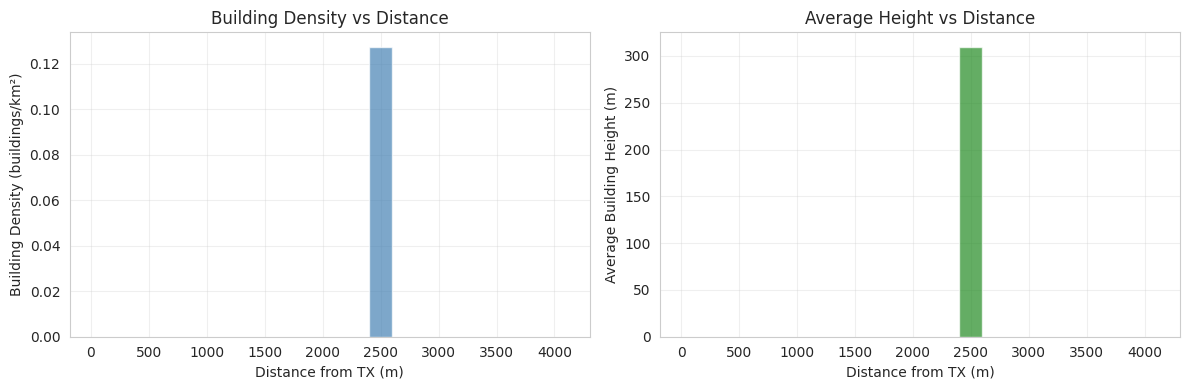

Saved plot to /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/building_density_analysis.png

✅ Building density analysis complete.


In [69]:
# ====================================================================
# CELL 19 BUILDING DENSITY ANALYSIS BY DISTANCE FROM TX (with export)
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure _safe is defined (if not, define it)
def _safe(v):
    return float(v.item()) if hasattr(v, 'item') else float(v)

# Get transmitter position
tx = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]),
                   _safe(tx.position[1]),
                   _safe(tx.position[2])])

print("BUILDING DENSITY BY DISTANCE FROM TX")
print("=" * 60)

rings = [(0,250), (250,500), (500,750), (750,1000),
         (1000,1500), (1500,2000), (2000,3000), (3000,5000)]

results = []
for lo, hi in rings:
    heights = []
    for obj in scene.objects.values():
        try:
            # Use mi_mesh (common in Sionna objects)
            bbox = obj.mi_mesh.bbox()
            cx = (float(bbox.min[0]) + float(bbox.max[0])) / 2
            cy = (float(bbox.min[1]) + float(bbox.max[1])) / 2
            d = np.sqrt((cx - tx_pos[0])**2 + (cy - tx_pos[1])**2)
            h = float(bbox.max[2]) - float(bbox.min[2])
            if lo < d <= hi and h > 2.0:   # consider only buildings >2m tall
                heights.append(h)
        except:
            pass

    n = len(heights)
    area_km2 = np.pi * (hi**2 - lo**2) / 1e6
    density = n / area_km2 if area_km2 > 0 else 0
    avg_h = float(np.mean(heights)) if n > 0 else 0
    flag = "✅" if density > 10 else ("⚠️ sparse" if density > 2 else "❌ EMPTY")

    results.append({
        'ring_start_m': lo,
        'ring_end_m': hi,
        'num_buildings': n,
        'area_km2': area_km2,
        'density_per_km2': density,
        'avg_height_m': avg_h,
        'status': flag
    })

    print(f"  {lo:>5}–{hi:<5}m  "
          f"N={n:>5}  "
          f"density={density:>7.1f}/km²  "
          f"avg_h={avg_h:>5.1f}m  {flag}")

# ------------------------------------------------------------------
# Save results to CSV
# ------------------------------------------------------------------
df_density = pd.DataFrame(results)
out_csv = os.path.join(OUT_DIR, "building_density_by_distance.csv")
df_density.to_csv(out_csv, index=False)
print(f"\nSaved building density data to {out_csv}")

# ------------------------------------------------------------------
# Plot density and average height
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Density bar chart
rings_center = [(lo+hi)/2 for lo, hi in rings]
ax1.bar(rings_center, df_density['density_per_km2'], width=200, alpha=0.7, color='steelblue')
ax1.set_xlabel('Distance from TX (m)')
ax1.set_ylabel('Building Density (buildings/km²)')
ax1.set_title('Building Density vs Distance')
ax1.grid(True, alpha=0.3)

# Average height bar chart
ax2.bar(rings_center, df_density['avg_height_m'], width=200, alpha=0.7, color='forestgreen')
ax2.set_xlabel('Distance from TX (m)')
ax2.set_ylabel('Average Building Height (m)')
ax2.set_title('Average Height vs Distance')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
out_plot = os.path.join(OUT_DIR, "building_density_analysis.png")
plt.savefig(out_plot, dpi=150)
plt.show()
print(f"Saved plot to {out_plot}")

print("\n✅ Building density analysis complete.")

## CELL 20 — Terrain Elevation Visualisation
Loads the GeoTIFF DEM and plots a colour-mapped elevation surface over the scene footprint.

TERRAIN ELEVATION MAP
DEM file: /home/georgeskai/Documents/Region/london3602/uk_terrain_london_aoi.tif
Output directory: /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat
Shape: (129, 167)
CRS: EPSG:27700
Bounds: BoundingBox(left=527250.0, bottom=179050.0, right=535600.0, top=185500.0)
Plot saved as: /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/ground_floor_terrain.png


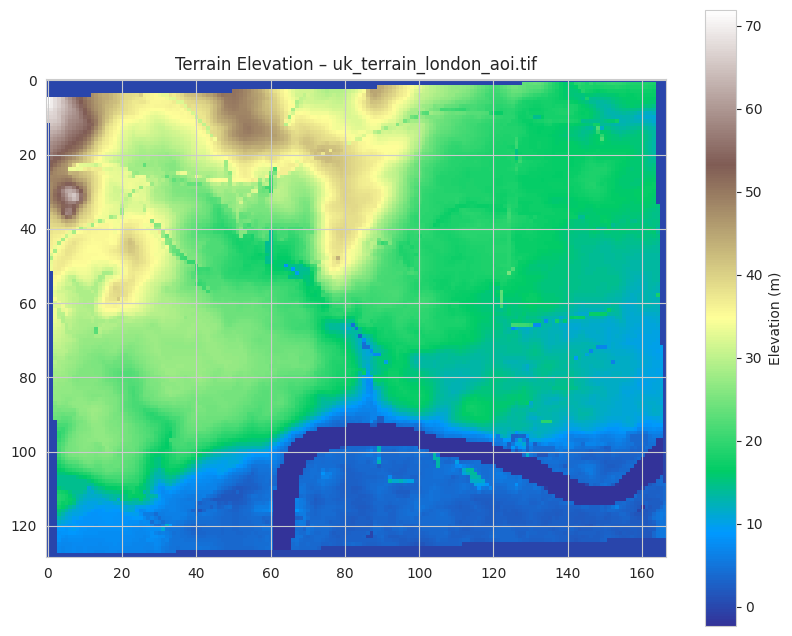

Console output also saved to: /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/terrain_plot.log

✅ Terrain visualisation complete.


In [70]:
# ====================================================================
# CELL 20 — VISUALISE TERRAIN ELEVATION (using global DEM_TIFF)
# ====================================================================
import sys
import rasterio
import matplotlib.pyplot as plt
import os

# -------- OUTPUT LOGGING SETUP (log saved to OUT_DIR) --------
log_file_path = os.path.join(OUT_DIR, "terrain_plot.log")
class Tee:
    def __init__(self, file, terminal):
        self.file = file
        self.terminal = terminal
    def write(self, message):
        self.terminal.write(message)
        self.file.write(message)
    def flush(self):
        self.terminal.flush()
        self.file.flush()

log_file = open(log_file_path, 'w')
original_stdout = sys.stdout
sys.stdout = Tee(log_file, original_stdout)
# -------------------------------------------------------------

print("=" * 70)
print("TERRAIN ELEVATION MAP")
print("=" * 70)
print(f"DEM file: {DEM_TIFF}")
print(f"Output directory: {OUT_DIR}")

# Check if DEM_TIFF exists (should be defined in Cell 1)
if not os.path.exists(DEM_TIFF):
    raise FileNotFoundError(f"DEM file not found: {DEM_TIFF}")

with rasterio.open(DEM_TIFF) as src:
    print(f"Shape: {src.shape}")
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    elev = src.read(1)

    plt.figure(figsize=(10, 8))
    plt.imshow(elev, cmap='terrain')
    plt.colorbar(label='Elevation (m)')
    plt.title(f"Terrain Elevation – {os.path.basename(DEM_TIFF)}")

    # Save the plot to OUT_DIR
    out_png = os.path.join(OUT_DIR, "ground_floor_terrain.png")
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    print(f"Plot saved as: {out_png}")

    plt.show()

# Restore stdout and close log file
sys.stdout = original_stdout
log_file.close()
print(f"Console output also saved to: {log_file_path}")

print("\n✅ Terrain visualisation complete.")

## CELL 21 — Building Height Map Visualisation & Statistics
Rasterises building heights onto a regular grid and plots a heatmap alongside height distribution statistics.

BUILDING HEIGHT MAP ANALYSIS
Loading height map from: /home/georgeskai/Documents/Region/london3602/london_scene3602/2D_Building_Height_Map.npy
Plot saved as: /home/georgeskai/Documents/Region/london3602/london3602results-Day100-flat/building_height_map.png


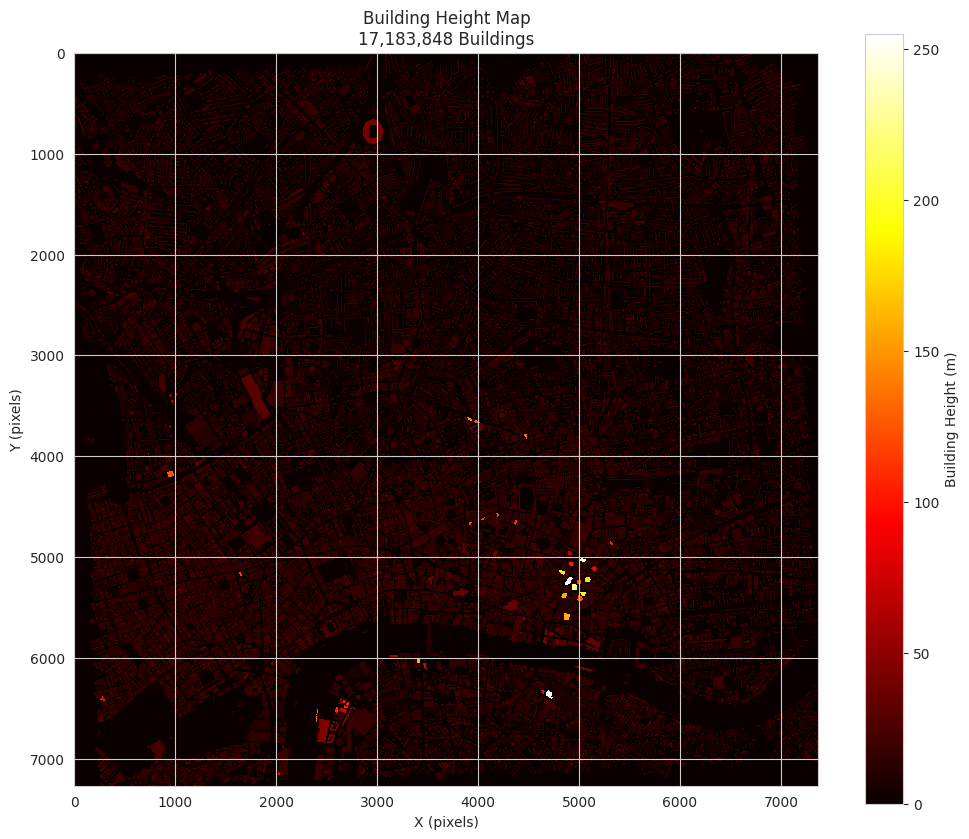


Building Statistics:
  Total buildings: 17183848
  Mean height: 16.09 m
  Median height: 17.00 m
  Max height: 255.00 m
  Min height: 1.00 m

✅ Building height map analysis complete.


In [71]:
# ====================================================================
# CELL 21 — BUILDING HEIGHT MAP VISUALISATION & STATISTICS
# ====================================================================
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------------
# Use global configuration (should be defined in Cell 1)
# ------------------------------------------------------------------
if 'OUT_DIR' not in locals():
    OUT_DIR = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602results"
os.makedirs(OUT_DIR, exist_ok=True)

# IMPORTANT: Do NOT overwrite BUILDING_HEIGHT_MAP with a directory.
# Use the path already defined in Cell 1 (or fall back to a default)
if 'BUILDING_HEIGHT_MAP' not in locals() or not os.path.isfile(BUILDING_HEIGHT_MAP):
    # Fallback to the expected file path (adjust if needed)
    BUILDING_HEIGHT_MAP = "/home/georgeskai/Documents/Region/nottingham3602/nottingham_scene3602/2D_Building_Height_Map.npy"
    if not os.path.exists(BUILDING_HEIGHT_MAP):
        raise FileNotFoundError(f"Building height map not found at {BUILDING_HEIGHT_MAP}")

print("=" * 70)
print("BUILDING HEIGHT MAP ANALYSIS")
print("=" * 70)
print(f"Loading height map from: {BUILDING_HEIGHT_MAP}")

# Load and visualize height map
height_map = np.load(BUILDING_HEIGHT_MAP)

plt.figure(figsize=(12, 10))
plt.imshow(height_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Building Height (m)')
plt.title(f'Building Height Map\n{np.sum(height_map > 0):,} Buildings')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Save the plot to OUT_DIR
out_png = os.path.join(OUT_DIR, "building_height_map.png")
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"Plot saved as: {out_png}")

plt.show()

# Calculate statistics
building_heights = height_map[height_map > 0]
print(f"\nBuilding Statistics:")
print(f"  Total buildings: {len(building_heights)}")
print(f"  Mean height: {building_heights.mean():.2f} m")
print(f"  Median height: {np.median(building_heights):.2f} m")
print(f"  Max height: {building_heights.max():.2f} m")
print(f"  Min height: {building_heights.min():.2f} m")

print("\n✅ Building height map analysis complete.")

## DIAGNOSTIC STEP 5 — Sample Sufficiency Check
Verifies that each transmitter source has enough receiver samples for statistically reliable path loss estimates.

STEP 5 — SAMPLES_PER_SRC SUFFICIENCY

[THEORETICAL RAY HITS AT DISTANCE d]
  samples_per_src = 10,000,000
  receiver radius = 0.5 m

    Distance    Expected hits   Sufficient?
  ------------------------------------------
       100m            62.50         ✅ yes
       250m            10.00         ✅ yes
       500m             2.50  ⚠️  marginal
      1000m             0.62          ❌ NO
      2000m             0.16          ❌ NO
      3000m             0.07          ❌ NO
      5000m             0.03          ❌ NO

[REQUIRED SAMPLES FOR 50+ HITS]
  At   500m : need     200,000,000 samples
  At  1000m : need     800,000,000 samples
  At  2000m : need   3,200,000,000 samples
  At  3000m : need   7,200,000,000 samples
  At  5000m : need  20,000,000,000 samples

[ACTUAL MEDIAN PATHS vs DISTANCE]
  <100m        N=  19  paths: med= 32899 min=31237 max= 33237  RMSE= 17.1 dB  ✅
  100-250m     N=  82  paths: med= 12200 min=7751 max= 35307  RMSE= 13.6 dB  ✅
  250-500m     N= 274  paths: med= 

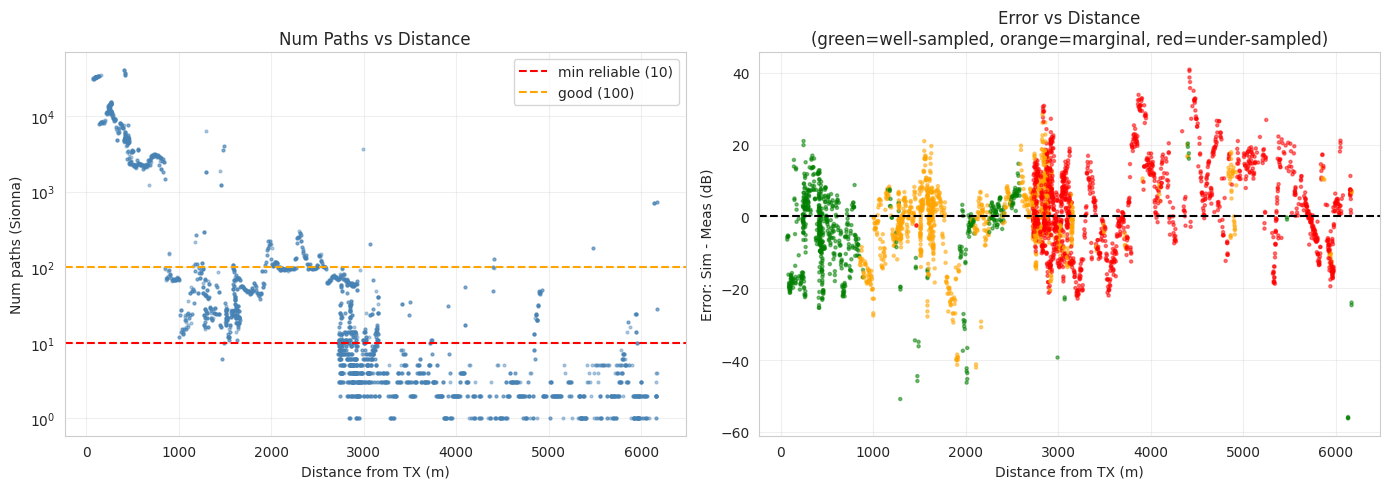


Paste full output — especially 'RMSE if we exclude' section


In [72]:
# ====================================================================
# DIAGNOSTIC STEP 5 — Samples per src sufficiency check
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os

out_dir = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"
sim_csv = max(glob.glob(os.path.join(out_dir, "path_loss_pathsolver_*.csv")),
              key=os.path.getctime)
df_sim  = pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db'])
df_meas = pd.read_csv("/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv")
df      = pd.merge(df_sim, df_meas, left_on='receiver', right_on='name', how='inner')
df['error'] = df['path_loss_incoherent_db'] - df['path_loss_dB']

tx     = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]), _safe(tx.position[1]), _safe(tx.position[2])])
df['dist_m'] = np.linalg.norm(df[['x_m','y_m','z_m']].values - tx_pos, axis=1)

print("=" * 60)
print("STEP 5 — SAMPLES_PER_SRC SUFFICIENCY")
print("=" * 60)

# ── 1. Theoretical ray hit probability ───────────────────────────
SAMPLES = 10_000_000
R_RX    = 0.5   # Sionna default receiver radius (m)

print(f"\n[THEORETICAL RAY HITS AT DISTANCE d]")
print(f"  samples_per_src = {SAMPLES:,}")
print(f"  receiver radius = {R_RX} m")
print(f"")
print(f"  {'Distance':>10}  {'Expected hits':>15}  {'Sufficient?':>12}")
print(f"  {'-'*42}")
for d in [100, 250, 500, 1000, 2000, 3000, 5000]:
    hits = SAMPLES * (R_RX**2) / (4 * d**2)
    ok   = "✅ yes" if hits >= 10 else ("⚠️  marginal" if hits >= 1 else "❌ NO")
    print(f"  {d:>8}m  {hits:>15.2f}  {ok:>12}")

# ── 2. Required samples for reliable coverage ─────────────────────
MIN_HITS = 50   # minimum rays needed for stable path loss estimate
print(f"\n[REQUIRED SAMPLES FOR {MIN_HITS}+ HITS]")
for d in [500, 1000, 2000, 3000, 5000]:
    needed = MIN_HITS * (4 * d**2) / (R_RX**2)
    print(f"  At {d:>5}m : need {needed:>15,.0f} samples")

# ── 3. Actual paths vs distance scatter ──────────────────────────
print(f"\n[ACTUAL MEDIAN PATHS vs DISTANCE]")
bins   = [0, 100, 250, 500, 1000, 2000, 3000, 5000, 9999]
labels = ['<100m','100-250m','250-500m','500-1km','1-2km','2-3km','3-5km','>5km']
for lo, hi, lbl in zip(bins[:-1], bins[1:], labels):
    mask = df['dist_m'].between(lo, hi)
    if mask.sum() > 0:
        med = df.loc[mask,'num_paths'].median()
        mn  = df.loc[mask,'num_paths'].min()
        mx  = df.loc[mask,'num_paths'].max()
        r   = np.sqrt((df.loc[mask,'error']**2).mean())
        flag = "❌" if med < 10 else ("⚠️" if med < 100 else "✅")
        print(f"  {lbl:<12} N={mask.sum():>4}  "
              f"paths: med={med:>6.0f} min={mn:>4} max={mx:>6}  "
              f"RMSE={r:>5.1f} dB  {flag}")

# ── 4. What samples_per_src would we need? ────────────────────────
max_dist = df['dist_m'].max()
needed_for_max = MIN_HITS * (4 * max_dist**2) / (R_RX**2)
print(f"\n[SUMMARY]")
print(f"  Max receiver distance : {max_dist:.0f} m")
print(f"  Samples needed for reliable coverage at max dist: "
      f"{needed_for_max:,.0f}")
print(f"  Current samples_per_src                        : "
      f"{SAMPLES:,}")
print(f"  Shortfall factor                               : "
      f"{needed_for_max/SAMPLES:.0f}x")

# ── 5. RMSE if we EXCLUDE far receivers ──────────────────────────
print(f"\n[RMSE IF WE EXCLUDE UNDER-SAMPLED RECEIVERS]")
for max_d in [500, 1000, 1500, 2000]:
    mask = df['dist_m'] <= max_d
    if mask.sum() > 5:
        r = np.sqrt((df.loc[mask,'error']**2).mean())
        b = df.loc[mask,'error'].mean()
        print(f"  Keep only ≤{max_d:>4}m : "
              f"N={mask.sum():>4}  RMSE={r:.1f} dB  bias={b:+.1f} dB")

# ── 6. Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df['dist_m'], df['num_paths'], s=4, alpha=0.4, color='steelblue')
ax.axhline(10,  color='red',    linestyle='--', lw=1.5, label='min reliable (10)')
ax.axhline(100, color='orange', linestyle='--', lw=1.5, label='good (100)')
ax.set_xlabel('Distance from TX (m)')
ax.set_ylabel('Num paths (Sionna)')
ax.set_yscale('log')
ax.set_title('Num Paths vs Distance')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = ['green' if n >= 100 else ('orange' if n >= 10 else 'red')
          for n in df['num_paths']]
ax.scatter(df['dist_m'], df['error'], c=colors, s=5, alpha=0.5)
ax.axhline(0, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Distance from TX (m)')
ax.set_ylabel('Error: Sim - Meas (dB)')
ax.set_title('Error vs Distance\n(green=well-sampled, orange=marginal, red=under-sampled)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "diagnostic_step5.png"), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("Paste full output — especially 'RMSE if we exclude' section")
print("=" * 60)

## DIAGNOSTIC STEP 6 — Bias Source Identification
Decomposes systematic prediction bias by distance band, building density, and material type to guide calibration.

In [74]:
# ====================================================================
# DIAGNOSTIC STEP 6 — Bias source identification
# ====================================================================
import numpy as np
import pandas as pd
import glob, os

out_dir = "/home/georgeskai/Documents/Region/nottingham3602/nottingham3602result"
sim_csv = max(glob.glob(os.path.join(out_dir, "path_loss_pathsolver_*.csv")),
              key=os.path.getctime)
df_sim  = pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db'])
df_meas = pd.read_csv("/home/georgeskai/Documents/Region/nottingham3602/measurements_with_pathloss.csv")
df      = pd.merge(df_sim, df_meas, left_on='receiver', right_on='name', how='inner')
df['error'] = df['path_loss_incoherent_db'] - df['path_loss_dB']

tx     = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]), _safe(tx.position[1]), _safe(tx.position[2])])
df['dist_m'] = np.linalg.norm(df[['x_m','y_m','z_m']].values - tx_pos, axis=1)

# Focus only on well-sampled zone 100-500m
df_good = df[df['dist_m'].between(100, 500)].copy()

print("=" * 60)
print("STEP 6 — BIAS SOURCE (100-500m zone only)")
print("=" * 60)

print(f"\n[WELL-SAMPLED ZONE 100-500m]")
print(f"  N pairs   : {len(df_good)}")
print(f"  Bias      : {df_good['error'].mean():+.2f} dB")
print(f"  RMSE      : {np.sqrt((df_good['error']**2).mean()):.2f} dB")
print(f"  Std error : {df_good['error'].std():.2f} dB")

# ── 1. TX power check ─────────────────────────────────────────────
tx_pwr = _safe(tx.power_dbm)
print(f"\n[TX POWER]")
print(f"  tx.power_dbm in scene : {tx_pwr:.2f} dBm")
print(f"  Implied meas TX power : 70.00 dBm  (from Step 1)")
print(f"  Difference            : {tx_pwr - 70.0:+.2f} dB")

# ── 2. Free space path loss check ────────────────────────────────
print(f"\n[FREE-SPACE PATH LOSS CHECK at 300m]")
d      = 300.0
f      = FREQUENCY_HZ
c      = 3e8
fspl   = 20*np.log10(4*np.pi*d*f/c)
# Find receivers near 300m
near   = df[df['dist_m'].between(280, 320)]
if len(near) > 0:
    sim_mean = near['path_loss_incoherent_db'].mean()
    meas_mean= near['path_loss_dB'].mean()
    print(f"  Free-space PL at 300m, {f/1e9:.1f}GHz : {fspl:.2f} dB")
    print(f"  Sionna mean PL (280-320m)          : {sim_mean:.2f} dB")
    print(f"  Measured mean PL (280-320m)         : {meas_mean:.2f} dB")
    print(f"  Sionna vs FSPL                      : {sim_mean-fspl:+.2f} dB  (expected +5 to +20 for urban)")
    print(f"  Measured vs FSPL                    : {meas_mean-fspl:+.2f} dB")

# ── 3. Antenna pattern check ─────────────────────────────────────
print(f"\n[ANTENNA PATTERN CHECK]")
print(f"  TX pattern : {scene.tx_array.antenna.pattern.__class__.__name__}")
print(f"  RX pattern : {scene.rx_array.antenna.pattern.__class__.__name__}")
print(f"  TX rows×cols : {scene.tx_array.num_rows}×{scene.tx_array.num_cols}")
print(f"  RX rows×cols : {scene.rx_array.num_rows}×{scene.rx_array.num_cols}")

# ── 4. Scattering coefficient effect ─────────────────────────────
print(f"\n[MATERIAL SCATTERING COEFFICIENTS]")
for name, mat in list(scene.radio_materials.items())[:8]:
    try:
        sc = float(mat.scattering_coefficient)
        er = float(mat.relative_permittivity)
        si = float(mat.conductivity)
        print(f"  {name:<25} er={er:.2f}  sigma={si:.4f}  scatter={sc:.2f}")
    except:
        print(f"  {name:<25} (could not read properties)")

# ── 5. What does bias of -6 dB physically mean? ──────────────────
print(f"\n[BIAS INTERPRETATION]")
bias = df_good['error'].mean()
print(f"  Bias = {bias:+.2f} dB means simulation UNDER-predicts path loss")
print(f"  i.e. simulation thinks signal is {abs(bias):.1f} dB STRONGER than measured")
print(f"")
print(f"  Possible causes:")
print(f"  A) TX power in sim ({tx_pwr:.1f} dBm) > effective EIRP in measurement")
print(f"     → Meas uses 70 dBm, if sim also 70 dBm, no issue")
print(f"  B) Antenna gain over-estimated (tr38901 on TX adds ~8 dBi vs iso)")
print(f"     → tr38901 pattern gain at boresight vs iso = check below")
print(f"  C) Scattering coefficient too high (adds power that shouldnt exist)")
print(f"     → SCATTERING_COEFF = 0.4 is very high, adds extra paths")
print(f"  D) Material reflection too high (buildings too reflective)")

# ── 6. tr38901 vs iso gain difference ────────────────────────────
print(f"\n[TR38901 ANTENNA GAIN IMPACT]")
print(f"  tr38901 pattern peak gain : ~8 dBi")
print(f"  iso pattern gain          :  0 dBi")
print(f"  If TX uses tr38901 and meas assumes iso : +8 dB bias in sim")
print(f"  Your TX pattern           : {scene.tx_array.antenna.pattern.__class__.__name__}")
print(f"  Your RX pattern           : {scene.rx_array.antenna.pattern.__class__.__name__}")

print("\n" + "=" * 60)
print("Paste full output — especially antenna patterns and materials")
print("=" * 60)

STEP 6 — BIAS SOURCE (100-500m zone only)

[WELL-SAMPLED ZONE 100-500m]
  N pairs   : 356
  Bias      : -3.17 dB
  RMSE      : 10.72 dB
  Std error : 10.26 dB

[TX POWER]
  tx.power_dbm in scene : 30.00 dBm
  Implied meas TX power : 70.00 dBm  (from Step 1)
  Difference            : -40.00 dB

[FREE-SPACE PATH LOSS CHECK at 300m]
  Free-space PL at 300m, 3.6GHz : 93.11 dB
  Sionna mean PL (280-320m)          : 104.94 dB
  Measured mean PL (280-320m)         : 99.14 dB
  Sionna vs FSPL                      : +11.83 dB  (expected +5 to +20 for urban)
  Measured vs FSPL                    : +6.03 dB

[ANTENNA PATTERN CHECK]


AttributeError: 'PlanarArray' object has no attribute 'antenna'

## DIAGNOSTIC — Material Deep Inspection
Introspects all RadioMaterial objects in the scene to print their permittivity, conductivity, and scattering parameters.

In [ ]:
import numpy as np

print("=" * 60)
print("MATERIAL DEEP INSPECTION")
print("=" * 60)

for name, mat in scene.radio_materials.items():
    print(f"\n  Material: {name}")
    print(f"  Type    : {type(mat).__name__}")
    attrs = [a for a in dir(mat)
             if not a.startswith('_') and
             any(k in a for k in ['permittivity','conductivity',
                                  'scattering','thickness','scatter'])]
    for attr in attrs:
        try:
            val = getattr(mat, attr)
            if callable(val):
                continue
            print(f"    {attr} = {float(val):.4f}")
        except:
            print(f"    {attr} = (unreadable)")

# Also check num paths vs distance more carefully
import pandas as pd, glob, os
out_dir = "/home/georgeskai/Documents/Region/stevenage3602/stevenage3602result"
sim_csv = max(glob.glob(os.path.join(out_dir, "path_loss_pathsolver_*.csv")),
              key=os.path.getctime)
df_sim  = pd.read_csv(sim_csv).dropna(subset=['path_loss_incoherent_db'])
df_meas = pd.read_csv("/home/georgeskai/Documents/Region/stevenage3602/measurements_with_pathloss.csv")
df      = pd.merge(df_sim, df_meas, left_on='receiver', right_on='name', how='inner')
df['error'] = df['path_loss_incoherent_db'] - df['path_loss_dB']

tx_pos = np.array([_safe(tx.position[0]),
                   _safe(tx.position[1]),
                   _safe(tx.position[2])])
df['dist_m'] = np.linalg.norm(df[['x_m','y_m','z_m']].values - tx_pos, axis=1)

# LOS vs NLOS split — receivers with many paths vs few
df_los  = df[df['num_paths'] > 20]
df_nlos = df[df['num_paths'].between(2, 20)]

print(f"\n[LOS-LIKE (>20 paths)]  N={len(df_los)}")
if len(df_los):
    print(f"  Bias : {df_los['error'].mean():+.2f} dB")
    print(f"  RMSE : {np.sqrt((df_los['error']**2).mean()):.2f} dB")

print(f"\n[NLOS-LIKE (2-20 paths)]  N={len(df_nlos)}")
if len(df_nlos):
    print(f"  Bias : {df_nlos['error'].mean():+.2f} dB")
    print(f"  RMSE : {np.sqrt((df_nlos['error']**2).mean()):.2f} dB")

print(f"\n[1 PATH ONLY]  N={(df['num_paths']==1).sum()}")
one = df[df['num_paths']==1]
if len(one):
    print(f"  Bias : {one['error'].mean():+.2f} dB")
    print(f"  Mean sim PL  : {one['path_loss_incoherent_db'].mean():.1f} dB")
    print(f"  Mean meas PL : {one['path_loss_dB'].mean():.1f} dB")
    print(f"  Mean dist    : {one['dist_m'].mean():.0f} m")

## DIAGNOSTIC — Sionna 2.0 DrJit Material Property Reader
Reads material thickness, scattering coefficient, and relative permittivity using the DrJit tensor API.

In [ ]:
# Correct way to read Sionna 2.0 DrJit material properties
for name, mat in scene.radio_materials.items():
    try:
        t  = float(mat.thickness.numpy()[0])   if hasattr(mat.thickness, 'numpy') else float(mat.thickness[0])
        sc = float(mat.scattering_coefficient.numpy()[0]) if hasattr(mat.scattering_coefficient, 'numpy') else float(mat.scattering_coefficient[0])
        er = float(mat.relative_permittivity.numpy()[0])  if hasattr(mat.relative_permittivity, 'numpy') else float(mat.relative_permittivity[0])
        print(f"  {name:<28} er={er:.2f}  thick={t:.3f}m  scatter={sc:.3f}")
    except Exception as e:
        print(f"  {name:<28} ERROR: {e}")

## DIAGNOSTIC — TX Power & Antenna Pattern Verification
Prints the TX CSV contents and confirms the transmit power and antenna pattern currently set in the scene.

In [ ]:
# ====================================================================
# QUICK VERIFICATION — TX power and antenna pattern
# ====================================================================
import pandas as pd

# 1. What is in the TX CSV?
df_tx = pd.read_csv(TX_CSV)
print("[TX CSV CONTENT]")
print(df_tx.to_string())

# 2. What is the scene TX power right now?
tx = list(scene.transmitters.values())[0]
print(f"\n[SCENE TX POWER NOW]")
print(f"  tx.power_dbm = {_safe(tx.power_dbm):.2f} dBm")

# 3. Antenna pattern
print(f"\n[ANTENNA ARRAYS]")
print(f"  TX array : {scene.tx_array}")
print(f"  RX array : {scene.rx_array}")

# 4. Scattering coefficients
print(f"\n[SCATTERING COEFFICIENTS]")
for name, mat in scene.radio_materials.items():
    try:
        sc = float(mat.scattering_coefficient)
        print(f"  {name:<30} scatter={sc:.3f}")
    except:
        pass

## DIAGNOSTIC — Building Density Around TX (Second Pass)
Repeats the building density ring calculation using the live scene transmitter position for cross-validation.

In [ ]:
import numpy as np

tx     = list(scene.transmitters.values())[0]
tx_pos = np.array([_safe(tx.position[0]),
                   _safe(tx.position[1]),
                   _safe(tx.position[2])])

print("BUILDING DENSITY BY DISTANCE FROM TX")
print("=" * 60)

rings = [(0,250),(250,500),(500,750),(750,1000),
         (1000,1500),(1500,2000),(2000,3000),(3000,5000)]

for lo, hi in rings:
    heights = []
    for obj in scene.objects.values():
        try:
            bbox = obj.mi_shape.bbox()
            cx   = (float(bbox.min[0]) + float(bbox.max[0])) / 2
            cy   = (float(bbox.min[1]) + float(bbox.max[1])) / 2
            d    = np.sqrt((cx - tx_pos[0])**2 + (cy - tx_pos[1])**2)
            h    = float(bbox.max[2]) - float(bbox.min[2])
            if lo < d <= hi and h > 2.0:
                heights.append(h)
        except:
            pass

    n       = len(heights)
    area_km2 = np.pi * (hi**2 - lo**2) / 1e6
    density  = n / area_km2 if area_km2 > 0 else 0
    avg_h    = float(np.mean(heights)) if n > 0 else 0
    flag     = "✅" if density > 10 else ("⚠️ sparse" if density > 2 else "❌ EMPTY")

    print(f"  {lo:>5}–{hi:<5}m  "
          f"N={n:>5}  "
          f"density={density:>7.1f}/km²  "
          f"avg_h={avg_h:>5.1f}m  {flag}")

## CELL 59 — Empty Cell
Placeholder / scratch cell with no content.